# SFT Dataset Generation — from `passed_mcqs.jsonl` (S5 Output)

**AI Tutor System — Teacher-Student Knowledge Distillation**

---

## Purpose

This notebook builds the final **Supervised Fine-Tuning (SFT) dataset** for Qwen student-model training.  
It reads from the **S5 validation pipeline output** (`passed_mcqs.jsonl`) — the
highest-quality, fully-validated MCQs that survived all five validation stages — and
converts each slot-level record into a **LLaMA-Factory–compatible SFT training sample**.

---

## Input → Output

| | File | Format | Contents |
|---|---|---|---|
| **Input** | `passed_mcqs.jsonl` | JSONL | S5 stage-by-stage `passed.jsonl` records (one per validated MCQ slot) |
| **Input** | `selected_subset_v3.jsonl` | JSONL | S3 chunks (provides `metadata`, `keywords`, `context_fringe`) |
| **Output** | `sft_metadata_conditioned.jsonl` | JSONL | Metadata-conditioned SFT records (Option A) |
| **Output** | `sft_dataset_info.json` | JSON | LLaMA-Factory `dataset_info.json` entries |

---

## Input Record Schema (`passed_mcqs.jsonl`)

Each line in `passed_mcqs.jsonl` is a S5 stage-by-stage `passed.jsonl` record:

```json
{
  "mcq_data": {
    "chunk_id":   "<str>",
    "text":       "<str>  — the source chunk text",
    "slot_index": "<int>",
    "chunk_type": "<str>  — definition | process | comparison | example | argument",
    "concept":    "<str>  — the concept this slot tests",
    "bloom_level":"<str>  — remember | understand | apply | analyze | evaluate | create",
    "mcq": {
      "question":    "<str>",
      "options":     {"A": "<str>", "B": "<str>", "C": "<str>", "D": "<str>"},
      "answer":      "<A|B|C|D>",
      "explanation": "<str>"
    }
  },
  "chunk_id":    "<str>",
  "slot_index":  "<int>",
  "stage_name":  "llm_judge",
  "stage_number": 5,
  "timestamp":   "<ISO-8601 str>",
  "validation_result": {
    "passed": true,
    "reason": "",
    "scores": { "correctness": 4.0, "clarity": 4.0, "distractors": 3.5,
                "educational_value": 4.0, "chunk_grounding": 4.0, "overall": 3.9 },
    "ambiguous": false
  },
  "scores": {}
}
```

---

## SFT Format: `sharegpt` (LLaMA-Factory)

Every training record uses the **`sharegpt`** conversation format with three turns:

```
system   → static domain expert persona + output format rules
user     → chunk text + metadata conditioning tags + task instruction
assistant → the validated MCQ as a clean JSON object
```

This matches the **runtime inference format exactly** — no train/inference mismatch.

---

## Two Training Variants

| Variant | User turn includes metadata? | Purpose |
|---|---|---|
| **Option A** `sft_metadata_conditioned.jsonl` | Yes — `[BLOOM LEVEL]`, `[CHUNK TYPE]`, `[FOCUS CONCEPT]` | Primary training target; enables runtime Bloom control |


## 0. Centralized Configuration

> **Change only this section between runs.** All paths, repo names, version tags,
> and runtime constants are defined here and referenced everywhere else via variables.
> To start a new experiment, duplicate the notebook and edit the blocks below.


In [1]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║              CENTRALIZED CONFIGURATION — EDIT THIS SECTION ONLY         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
# All cells below reference these variables. To reuse the notebook for a new run:
#   1. Update the HF repo names / version tag / run name below.
#   2. Run all cells top to bottom — no other edits needed.

import os
from os.path import join

# ══════════════════════════════════════════════════════════════════════════════
# ── A. VERSION & RUN IDENTITY ─────────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

VERSION_TAG      = "v6"               # ← bump for each new experiment
RUN_NAME         = f"mcq-bloom-qwen-{VERSION_TAG}"   # W&B run name + YAML run_name
EXPERIMENT_NAME  = "mcq-bloom"        # W&B project prefix
OUTPUT_TAG       = VERSION_TAG        # appended to every output folder name

# ══════════════════════════════════════════════════════════════════════════════
# ── B. HUGGING FACE CONFIGURATION ─────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

# Secrets are loaded at runtime from Kaggle Secrets — do NOT hardcode values here.
# Set these secret names in Kaggle → Settings → Add-ons → Secrets:
#   HF_TOKEN, WANDB_API_KEY, HF_USERNAME

HF_TOKEN_ENV_VAR    = "HF_TOKEN"          # Kaggle secret name for HF token
HF_PRIVATE_REPO     = True                # create repos as private?

# Repository names on Hugging Face (just the slug, without the username prefix)
HF_BASE_MODEL_REPO  = "mcqs-files"        # Kaggle dataset slug containing base model
HF_LORA_REPO        = f"mcq-bloom-qwen-lora_{VERSION_TAG}"        # LoRA adapter repo
HF_MERGED_REPO      = f"mcq-bloom-qwen-merged_{VERSION_TAG}"      # merged model repo
HF_CHECKPOINT_REPO  = f"mcq-bloom-qwen-checkpoints_{VERSION_TAG}" # checkpoint backup repo

# W&B project
WANDB_PROJECT_NAME  = f"{EXPERIMENT_NAME}-{VERSION_TAG}"

# ══════════════════════════════════════════════════════════════════════════════
# ── C. KAGGLE DIRECTORY LAYOUT ────────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

# Root directories (set by Kaggle automatically)
KAGGLE_INPUT_DIR    = "/kaggle/input"
KAGGLE_WORKING_DIR  = "/kaggle/working"
KAGGLE_OUTPUT_DIR   = "/kaggle/working"   # Kaggle saves /working as the output

# ── Input dataset (read-only) ─────────────────────────────────────────────────
KAGGLE_DATASET_SLUG = "ayakhaled51/mcqs-files"   # ← change if dataset changes
KAGGLE_DATASET_DIR  = join(KAGGLE_INPUT_DIR, "datasets", KAGGLE_DATASET_SLUG)

# ── Base model (read-only, inside dataset) ────────────────────────────────────
BASE_MODEL_NAME     = "Qwen2.5-1.5B-Instruct"
KAGGLE_MODEL_DIR    = join(KAGGLE_DATASET_DIR, BASE_MODEL_NAME, BASE_MODEL_NAME)

# ── Writable output directories ───────────────────────────────────────────────
KAGGLE_DATA_DIR     = join(KAGGLE_WORKING_DIR, f"GP_Quiz-Generation_Data")
KAGGLE_FINETUNE_DIR = join(KAGGLE_DATA_DIR,    "llamafactory-finetune-data")
KAGGLE_LORA_DIR     = join(KAGGLE_WORKING_DIR, f"mcq-lora-adapter_{OUTPUT_TAG}")
KAGGLE_BEST_LORA_DIR= join(KAGGLE_WORKING_DIR, f"mcq-lora-adapter-best_{OUTPUT_TAG}")
KAGGLE_MERGED_DIR   = join(KAGGLE_WORKING_DIR, f"mcq-qwen-merged_{OUTPUT_TAG}")
KAGGLE_BEST_MERGED_DIR = join(KAGGLE_WORKING_DIR, f"mcq-qwen-merged-best_{OUTPUT_TAG}")
KAGGLE_EXPORT_DIR   = KAGGLE_BEST_MERGED_DIR   # alias — exported merged model
KAGGLE_EVAL_DIR     = join(KAGGLE_WORKING_DIR, "evaluation")
KAGGLE_CACHE_DIR    = join(KAGGLE_WORKING_DIR, ".cache")
KAGGLE_LOG_DIR      = join(KAGGLE_WORKING_DIR, "logs")
LLAMA_FACTORY_DIR   = join(KAGGLE_WORKING_DIR, "LLaMA-Factory")
KAGGLE_PLOT_DIR     = join(KAGGLE_EVAL_DIR,    "plots")

# ── HF best-eval-loss tracker (persists across cells) ────────────────────────
HF_BEST_TRACKER     = join(KAGGLE_WORKING_DIR, "hf_best_eval_loss.json")

# ── Training YAML path ────────────────────────────────────────────────────────
TRAINING_YAML_PATH  = join(LLAMA_FACTORY_DIR, "examples/train_lora/mcq_sft_finetune.yaml")
EXPORT_YAML_PATH    = join(LLAMA_FACTORY_DIR, "examples/merge_lora/mcq_sft_export.yaml")

# ══════════════════════════════════════════════════════════════════════════════
# ── D. INPUT / OUTPUT FILE PATHS ──────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

# Input files (read-only Kaggle Dataset)
S5_PASSED_PATH           = join(KAGGLE_DATASET_DIR, "passed_mcqs.jsonl")
S3_CHUNKS_PATH           = join(KAGGLE_DATASET_DIR, "selected_subset_v3.jsonl")
TEACHER_OUTPUT_PATH      = join(KAGGLE_DATASET_DIR, "teacher_outputs.jsonl")
EVAL_CHUNKS_PATH         = join(KAGGLE_DATASET_DIR, "selected_subset_v3.jsonl")

# Generated SFT output files
SFT_META_PATH            = join(KAGGLE_DATA_DIR,    "sft_metadata_conditioned.jsonl")
SFT_INFO_PATH            = join(KAGGLE_DATA_DIR,    "sft_dataset_info.json")
TRAIN_PATH               = join(KAGGLE_FINETUNE_DIR,"mcq_sft_train.jsonl")
VAL_PATH                 = join(KAGGLE_FINETUNE_DIR,"mcq_sft_val.jsonl")

# Evaluation output files
STUDENT_PRE_OUTPUT_PATH  = join(KAGGLE_DATASET_DIR, "student_pre_ft_outputs.jsonl")
STUDENT_POST_OUTPUT_PATH = join(KAGGLE_EVAL_DIR, "student_post_ft_outputs.jsonl")
TEACHER_SCORES_PATH      = join(KAGGLE_DATASET_DIR,    "teacher_judge_scores.jsonl")
STUDENT_PRE_SCORES_PATH  = join(KAGGLE_DATASET_DIR,    "student_pre_ft_judge_scores.jsonl")
STUDENT_POST_SCORES_PATH = join(KAGGLE_EVAL_DIR,    "student_post_ft_judge_scores.jsonl")
COMPARISON_PATH          = join(KAGGLE_EVAL_DIR,    "final_comparison_results.json")
TRAINING_CURVES_PATH     = join(KAGGLE_WORKING_DIR, "training_curves.png")
DATASET_INFO_PATH        = join(LLAMA_FACTORY_DIR,  "data/dataset_info.json")

# ══════════════════════════════════════════════════════════════════════════════
# ── E. TRAINING HYPERPARAMETERS ───────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

TRAIN_RATIO              = 0.90
VAL_RATIO                = 0.10
SPLIT_SEED               = 42

# ── LoRA ─────────────────────────────────────────────
LORA_RANK                = 32
LORA_ALPHA               = 32
LORA_DROPOUT             = 0.05

# ── Optimization ─────────────────────────────────────
LEARNING_RATE            = 5.0e-5
BATCH_SIZE               = 1
GRAD_ACCUMULATION        = 4

# ── Regularization ───────────────────────────────────
NEFTUNE_NOISE_ALPHA      = 12
WEIGHT_DECAY             = 0.01

# ── Scheduler ────────────────────────────────────────
WARMUP_RATIO             = 0.05

SAVE_TOTAL_LIMIT         = 6

# Resume from checkpoint — set to a path string to resume, None for fresh start
# Example: RESUME_FROM_CHECKPOINT = KAGGLE_LORA_DIR + "/checkpoint-500"
RESUME_FROM_CHECKPOINT   = None
# Additional epochs for this run
NUM_ADDITIONAL_EPOCHS    = 3       # epochs to train in this run

# ══════════════════════════════════════════════════════════════════════════════
# ── F. EVALUATION CONFIGURATION ───────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

GROQ_BASE_URL            = "https://api.groq.com/openai/v1"
JUDGE_MODEL              = "llama-3.3-70b-versatile"
EVAL_SAMPLE_N            = 200    # set to None for full evaluation

# ══════════════════════════════════════════════════════════════════════════════
# ── G. CREATE ALL WRITABLE DIRECTORIES ────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

_writable_dirs = [
    KAGGLE_DATA_DIR,
    KAGGLE_FINETUNE_DIR,
    KAGGLE_LORA_DIR,
    KAGGLE_BEST_LORA_DIR,
    KAGGLE_MERGED_DIR,
    KAGGLE_BEST_MERGED_DIR,
    KAGGLE_EVAL_DIR,
    KAGGLE_CACHE_DIR,
    KAGGLE_LOG_DIR,
    KAGGLE_PLOT_DIR,
    join(LLAMA_FACTORY_DIR, "examples/train_lora"),
    join(LLAMA_FACTORY_DIR, "examples/merge_lora"),
]
for _d in _writable_dirs:
    os.makedirs(_d, exist_ok=True)

# ── Convenience aliases (used in older cells / compatibility) ─────────────────
INPUT_DIR           = KAGGLE_DATASET_DIR
OUTPUT_DIR          = KAGGLE_DATA_DIR
KAGGLE_WORKING      = KAGGLE_WORKING_DIR
CHUNKS_PATH         = EVAL_CHUNKS_PATH

print("✓ Configuration loaded.")
print(f"  Version     : {VERSION_TAG}")
print(f"  Run name    : {RUN_NAME}")
print(f"  LoRA repo   : {HF_LORA_REPO}")
print(f"  Merged repo : {HF_MERGED_REPO}")
print(f"  Ckpt repo   : {HF_CHECKPOINT_REPO}")
print()
print(f"  Dataset dir : {KAGGLE_DATASET_DIR}")
print(f"  Data dir    : {KAGGLE_DATA_DIR}")
print(f"  LoRA dir    : {KAGGLE_LORA_DIR}")
print(f"  Merged dir  : {KAGGLE_MERGED_DIR}")
print(f"  Eval dir    : {KAGGLE_EVAL_DIR}")

✓ Configuration loaded.
  Version     : v6
  Run name    : mcq-bloom-qwen-v6
  LoRA repo   : mcq-bloom-qwen-lora_v6
  Merged repo : mcq-bloom-qwen-merged_v6
  Ckpt repo   : mcq-bloom-qwen-checkpoints_v6

  Dataset dir : /kaggle/input/datasets/ayakhaled51/mcqs-files
  Data dir    : /kaggle/working/GP_Quiz-Generation_Data
  LoRA dir    : /kaggle/working/mcq-lora-adapter_v6
  Merged dir  : /kaggle/working/mcq-qwen-merged_v6
  Eval dir    : /kaggle/working/evaluation


## 1. Environment Setup

> **Kaggle Environment** — This notebook runs on **Kaggle** (not Colab, no Drive).
>
> **Input files** (read-only Kaggle Dataset):
> ```
> /kaggle/input/datasets/ayakhaled51/mcqs-files/
>   ├── passed_mcqs.jsonl
>   └── selected_subset_v3.jsonl
> ```
>
> **All new outputs** go to `/kaggle/working/` (writable, persists for the session):
> ```
> /kaggle/working/
>   ├── GP_Quiz-Generation_Data/      ← generated SFT files, split files
>   ├── LLaMA-Factory/                ← cloned repo
>   ├── mcq-lora-adapter/             ← training output (pushed to HF, then cleaned)
>   └── mcq-qwen-merged/              ← merged model (pushed to HF, then cleaned)
> ```


In [2]:
# ─── Kaggle Environment Setup ─────────────────────────────────────────────────
# Paths come from the centralized config (Section 0). This cell only handles
# secrets loading and verifies the input dataset is accessible.

import os

# ── Load HF token from Kaggle Secrets ────────────────────────────────────────
try:
    from kaggle_secrets import UserSecretsClient
    _secrets   = UserSecretsClient()
    HF_TOKEN   = _secrets.get_secret("HF_TOKEN")
    os.environ["HF_TOKEN"] = HF_TOKEN
    print("✓ HF_TOKEN loaded from Kaggle Secrets.")
except Exception as _e:
    HF_TOKEN = os.environ.get("HF_TOKEN", "")
    print(f"  HF_TOKEN fallback to env var: {'found' if HF_TOKEN else 'MISSING'}  ({_e})")

# ── Verify input dataset is accessible ───────────────────────────────────────
print()
print(f"Input  dir : {KAGGLE_DATASET_DIR}")
print(f"Output dir : {KAGGLE_DATA_DIR}")
print()
if os.path.exists(KAGGLE_DATASET_DIR):
    files = os.listdir(KAGGLE_DATASET_DIR)
    print(f"✓ Input dataset found — {len(files)} file(s):")
    for fn in sorted(files):
        size_mb = os.path.getsize(os.path.join(KAGGLE_DATASET_DIR, fn)) / (1024**2)
        print(f"    {fn}  ({size_mb:.1f} MB)")
else:
    print(f"✗ Input dataset NOT found at {KAGGLE_DATASET_DIR}")
    print(f"  → Make sure you added the dataset '{KAGGLE_DATASET_SLUG}' to this notebook")
    print(    "    via Notebook Settings → Add Data.")

✓ HF_TOKEN loaded from Kaggle Secrets.

Input  dir : /kaggle/input/datasets/ayakhaled51/mcqs-files
Output dir : /kaggle/working/GP_Quiz-Generation_Data

✓ Input dataset found — 8 file(s):
    Qwen2.5-1.5B-Instruct  (0.0 MB)
    passed_mcqs.jsonl  (9.9 MB)
    selected_subset_v3.jsonl  (2.5 MB)
    student_post_ft_outputs.jsonl  (0.3 MB)
    student_pre_ft_judge_scores.jsonl  (0.3 MB)
    student_pre_ft_outputs.jsonl  (0.3 MB)
    teacher_judge_scores.jsonl  (0.3 MB)
    teacher_outputs.jsonl  (0.3 MB)


In [3]:
import os

# MODEL_PATH comes from centralized config: KAGGLE_MODEL_DIR
print(os.listdir(KAGGLE_MODEL_DIR))
print("✓ Model path loaded successfully")

['config.json', 'tokenizer.json', 'tokenizer_config.json', 'chat_template.jinja', 'model-001.safetensors', 'generation_config.json']
✓ Model path loaded successfully


In [4]:
# ── Prepare base model — copy to writable dir and fix safetensors filename ────
# The Kaggle dataset stores the weight as model-001.safetensors (sharded name).
# Transformers requires model.safetensors or pytorch_model.bin.
# We copy once to /kaggle/working/local_qwen_model and rename on the fly.
# Subsequent runs skip the copy if the destination already exists and is valid.

import os, shutil

_src = KAGGLE_MODEL_DIR                        # read-only input path
_dst = os.path.join(KAGGLE_WORKING_DIR, "local_qwen_model")  # writable copy

_EXPECTED_WEIGHT = "model.safetensors"

def _dst_is_valid():
    """Return True if destination exists and already has model.safetensors."""
    return (
        os.path.isdir(_dst) and
        os.path.exists(os.path.join(_dst, _EXPECTED_WEIGHT)) and
        os.path.exists(os.path.join(_dst, "config.json"))
    )

if _dst_is_valid():
    print(f"✓ Local model already prepared at: {_dst}  (skipping copy)")
else:
    if not os.path.exists(_src):
        raise FileNotFoundError(
            f"Base model not found at {_src}.\n"
            f"Ensure dataset '{KAGGLE_DATASET_SLUG}' is added via Notebook Settings → Add Data."
        )

    print(f"Copying base model: {_src} → {_dst}")
    os.makedirs(_dst, exist_ok=True)

    for fname in os.listdir(_src):
        src_file = os.path.join(_src, fname)
        # Rename the sharded weight file to the standard name transformers expects
        dst_name = "model.safetensors" if fname == "model-001.safetensors" else fname
        dst_file = os.path.join(_dst, dst_name)
        shutil.copy2(src_file, dst_file)
        print(f"  {fname}  →  {dst_name}")

    if not _dst_is_valid():
        raise RuntimeError(
            f"Copy completed but {_EXPECTED_WEIGHT} not found in {_dst}.\n"
            "Check that the source directory contains model-001.safetensors."
        )
    print("✓ Copy and rename complete.")

BASE_MODEL_PATH = _dst
print(f"\nBASE_MODEL_PATH = {BASE_MODEL_PATH}")
print("Files:", sorted(os.listdir(BASE_MODEL_PATH)))


Copying base model: /kaggle/input/datasets/ayakhaled51/mcqs-files/Qwen2.5-1.5B-Instruct/Qwen2.5-1.5B-Instruct → /kaggle/working/local_qwen_model
  config.json  →  config.json
  tokenizer.json  →  tokenizer.json
  tokenizer_config.json  →  tokenizer_config.json
  chat_template.jinja  →  chat_template.jinja
  model-001.safetensors  →  model.safetensors
  generation_config.json  →  generation_config.json
✓ Copy and rename complete.

BASE_MODEL_PATH = /kaggle/working/local_qwen_model
Files: ['chat_template.jinja', 'config.json', 'generation_config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']


In [5]:
import json
import os
import random
from collections import Counter
from os.path import join
from typing import Any, Dict, List, Optional, Tuple

print("Imports OK")

Imports OK


## 2. Paths & Configuration

In [6]:
# ─── Paths & Configuration ────────────────────────────────────────────────────
# All paths come from Section 0 (Centralized Configuration).
# This cell validates that the required input files exist.

import os
from os.path import join

# ── Validate inputs exist ─────────────────────────────────────────────────────
for path in [S5_PASSED_PATH, S3_CHUNKS_PATH]:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Required input not found: {path}\n"
            f"Make sure '{KAGGLE_DATASET_SLUG}' is added as a dataset to this notebook."
        )

print(f"S5 passed MCQs  : {S5_PASSED_PATH}")
print(f"S3 chunks       : {S3_CHUNKS_PATH}")
print(f"SFT output      : {SFT_META_PATH}")
print(f"Dataset info    : {SFT_INFO_PATH}")

S5 passed MCQs  : /kaggle/input/datasets/ayakhaled51/mcqs-files/passed_mcqs.jsonl
S3 chunks       : /kaggle/input/datasets/ayakhaled51/mcqs-files/selected_subset_v3.jsonl
SFT output      : /kaggle/working/GP_Quiz-Generation_Data/sft_metadata_conditioned.jsonl
Dataset info    : /kaggle/working/GP_Quiz-Generation_Data/sft_dataset_info.json


## 3. Load Inputs

### 3.1  Load S5 Passed MCQs

Each record is a S5 stage-by-stage `passed.jsonl` entry.  
The validated MCQ and its conditioning metadata live inside `mcq_data`.

In [7]:
def load_jsonl(path: str) -> List[Dict]:
    """Load a JSONL file, skipping blank lines and malformed records."""
    records: List[Dict] = []
    skipped = 0
    with open(path, encoding="utf-8") as f:
        for lineno, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as exc:
                print(f"  [WARN] Skipping malformed line {lineno}: {exc}")
                skipped += 1
    if skipped:
        print(f"  Skipped {skipped} malformed line(s) in {os.path.basename(path)}")
    return records


s5_records: List[Dict] = load_jsonl(S5_PASSED_PATH)
print(f"Loaded {len(s5_records):,} passed MCQ records from S5.")

Loaded 4,509 passed MCQ records from S5.


### 3.2  Load S3 Chunks

S3 chunks provide the **keywords** and **context_fringe** fields that were stored
in the original chunk but are not carried through the S5 slot-level records.

If a chunk_id from S5 is not found in S3, the SFT record is still built using
only the data available in `mcq_data` (graceful degradation — keywords default
to empty, context fringe defaults to absent).

In [8]:
# Build lookup: chunk_id → full S3 chunk dict
s3_lookup: Dict[str, Dict] = {}
for rec in load_jsonl(S3_CHUNKS_PATH):
    cid = rec.get("chunk_id")
    if cid:
        s3_lookup[cid] = rec

print(f"S3 chunk lookup : {len(s3_lookup):,} chunks")

# Coverage check
s5_chunk_ids  = {r.get("chunk_id", r.get("mcq_data", {}).get("chunk_id", ""))
                 for r in s5_records}
matched       = s5_chunk_ids & set(s3_lookup.keys())
unmatched     = s5_chunk_ids - set(s3_lookup.keys())

print(f"Unique chunk_ids in S5 : {len(s5_chunk_ids):,}")
print(f"Matched in S3          : {len(matched):,}")
if unmatched:
    print(f"NOT matched (keywords/fringe will be empty): {len(unmatched):,}")
    for cid in list(unmatched)[:5]:
        print(f"  {cid}")

S3 chunk lookup : 1,500 chunks
Unique chunk_ids in S5 : 1,489
Matched in S3          : 1,489


## 4. Record Extraction Helper

`extract_slot_data()` normalises a single S5 passed record into a clean,
flat dict containing only the fields needed for SFT construction.

**Fields kept:**

| Field | Source | Purpose |
|---|---|---|
| `chunk_id` | `mcq_data` | Record identity / dedup key |
| `slot_index` | `mcq_data` | Slot identity within the chunk |
| `text` | `mcq_data` | Source chunk text → user turn |
| `bloom_level` | `mcq_data` | Bloom conditioning tag |
| `chunk_type` | `mcq_data` | Chunk-type conditioning tag |
| `concept` | `mcq_data` | Focus concept conditioning tag |
| `keywords` | S3 lookup | Distractor-quality hint in user turn |
| `prev_sentence` | S3 lookup | Context fringe (background only) |
| `next_sentence` | S3 lookup | Context fringe (background only) |
| `mcq` | `mcq_data` | The validated MCQ → assistant turn |

**Fields excluded:**

| Field | Reason for exclusion |
|---|---|
| `file_id` | Internal pipeline routing; irrelevant to model training |
| `s5_validation` | Validation bookkeeping; quality is implicit in the curated dataset itself |
| `chunk_type_confidence` | Classifier confidence; not meaningful in a training context |
| `stage_name`, `stage_number` | Pipeline provenance; not a training signal |
| `timestamp` | Pipeline provenance; not a training signal |
| `scores` (top-level) | Redundant empty dict from S5 per-MCQ records |
| `validation_result` | Pipeline bookkeeping; removed entirely from SFT output |

In [9]:
def extract_slot_data(
    s5_record: Dict,
    s3_lookup: Dict[str, Dict],
) -> Optional[Dict]:
    """
    Extract and normalise training-relevant fields from one S5 passed record.

    Parameters
    ----------
    s5_record : one line from passed_mcqs.jsonl
    s3_lookup : chunk_id -> S3 chunk dict (for keywords + context_fringe)

    Returns
    -------
    Flat dict with exactly the fields needed for SFT construction,
    or None if the record is structurally invalid.
    """
    # ── 1. Pull mcq_data sub-dict ─────────────────────────────────────────────
    mcq_data: Dict = s5_record.get("mcq_data", {})
    if not mcq_data:
        return None

    # ── 2. Required fields from mcq_data ─────────────────────────────────────
    chunk_id  : str       = mcq_data.get("chunk_id", "").strip()
    slot_index: int       = mcq_data.get("slot_index", 0)
    text      : str       = mcq_data.get("text", "").strip()
    bloom     : str       = mcq_data.get("bloom_level", "understand").strip().lower()
    chunk_type: str       = mcq_data.get("chunk_type", "definition").strip().lower()
    concept   : str       = mcq_data.get("concept", "").strip()
    mcq       : Dict      = mcq_data.get("mcq", {})

    # Validate the minimum required fields
    if not chunk_id or not text or not mcq:
        return None

    # Validate MCQ sub-structure
    if not mcq.get("question") or not mcq.get("options") or not mcq.get("answer"):
        return None

    if set(mcq.get("options", {}).keys()) != {"A", "B", "C", "D"}:
        return None

    # ── 3. Enrich from S3 lookup (keywords + context fringe) ─────────────────
    s3_chunk    : Dict        = s3_lookup.get(chunk_id, {})
    s3_meta     : Dict        = s3_chunk.get("metadata", {})
    fringe      : Dict        = s3_chunk.get("context_fringe", {})

    keywords    : List[str]   = s3_meta.get("keywords", [])
    prev_sentence: str        = (fringe.get("prev_sentence") or "").strip()
    next_sentence: str        = (fringe.get("next_sentence") or "").strip()

    # ── 4. Build clean MCQ dict (only the 4 training-relevant fields) ─────────
    clean_mcq = {
        "question":    mcq.get("question", "").strip(),
        "options":     mcq.get("options", {}),
        "answer":      mcq.get("answer", "").strip().upper(),
        "explanation": mcq.get("explanation", "").strip(),
    }

    # ── 5. Return flat, clean dict ────────────────────────────────────────────
    return {
        "chunk_id":     chunk_id,
        "slot_index":   slot_index,
        "text":         text,
        "bloom_level":  bloom,
        "chunk_type":   chunk_type,
        "concept":      concept,
        "keywords":     keywords,
        "prev_sentence": prev_sentence,
        "next_sentence": next_sentence,
        "mcq":          clean_mcq,
    }


print("extract_slot_data() defined.")

extract_slot_data() defined.


## 5. Prompts — Preserved from S4 Generation Pipeline

The system prompt and user prompt structure are **preserved exactly** from the
original S4 generation pipeline so the student model's training format matches
its inference format precisely.

### Changes from the original `build_sft_record()`

| What changed | Why |
|---|---|
| Input source is `passed_mcqs.jsonl` (S5), not `s4_success.jsonl` | Uses only the highest-quality, fully-validated MCQs |
| One SFT record per **slot** (not per chunk) | Training signal is per MCQ, not per chunk |
| `sharegpt` conversation format with `system`/`user`/`assistant` turns | Direct LLaMA-Factory compatibility; matches runtime inference format |
| Assistant turn is a **clean JSON object** (not wrapped in a JSON array) | One slot = one MCQ = one JSON object; no array needed |
| Metadata tags use natural-language bracket format `[BLOOM LEVEL]` | Better adherence in instruction-tuned models than raw JSON metadata |
| `
| `file_id`, `s5_validation`, `chunk_type_confidence` fully removed | Pipeline metadata; zero training value |


In [10]:
# ── System Prompt ─────────────────────────────────────────────────────────────
# Preserved from the S4 generation pipeline (SYSTEM_PROMPT).
# Kept as a static string — identical across all training records.
# NOT repeated in the user turn (matches how S4 sent it as system_instruction).

SFT_SYSTEM_PROMPT = "\n".join([
    # -- Persona & core behavior
    "You are an expert educational content designer for Bloom's Taxonomy-aligned assessment.",
    "Generate multiple-choice questions from educational text.",
    "Return ONLY valid JSON. No markdown fences, preambles, or commentary.",
    "",

    # -- Bloom levels (compressed)
    "## BLOOM LEVELS",
    "remember: recall facts | understand: explain meaning | apply: use in scenario",
    "analyze: compare/reason | evaluate: justify decision | create: design/propose",
    "",

    # -- Chunk type forms (compressed)
    "## CHUNK TYPE FORMS",
    "definition: explain concept | process: steps/sequence | comparison: differences",
    "example: real case | argument: evaluate claim",
    "",

    # -- Grounding rule (highest priority)
    "## GROUNDING (highest priority)",
    "- Correct answer MUST be explicitly stated in or directly inferable from the chunk.",
    "- Do NOT use external knowledge.",
    "",

    # -- MCQ quality rules
    "## MCQ RULES",
    "- Exactly 4 options: A, B, C, D. Exactly ONE correct answer.",
    "- Forbidden: 'All of the above', 'None of the above', 'Both A and B'.",
    "- Options must be similar in length (±25-30%) and share the same grammatical structure.",
    "- Options must be mutually exclusive. Do NOT embed the correct answer text in the question.",
    "",

    # -- Distractor rules
    "## DISTRACTORS",
    "- Use the keywords list to craft plausible distractors.",
    "- All 3 wrong options must belong to the same category/domain as the correct answer.",
    "- Distractors must be plausible to a student who skipped the chunk.",
    "",

    # -- Question phrasing
    "## QUESTION PHRASING",
    '- Do NOT say "according to the text", "based on the chunk", or "as stated above".',
    "- Question stem must be self-contained and <= 50 words.",
    "",

    "- You MUST complete the JSON fully. Do not stop mid-output.",
    "- Ensure all 4 options A,B,C,D are present before finishing.",
    "",

    "## EXPLANATION RULES",
    "- Do NOT mention option letters (A, B, C, D).",
    "- Refer to the answer by its content, not its position.",
    "- Do NOT use phrases like 'according to the text' or 'according to the chunk'.",
    "- Justify the correct concept clearly using its meaning.",
    "",

    # -- Output format (single MCQ object)
    "## OUTPUT FORMAT — return ONLY this JSON object:",
    "{",
    '  "question": "<full question stem>",',
    '  "options": {"A": "...", "B": "...", "C": "...", "D": "..."},',
    '  "answer": "<A|B|C|D>",',
    '  "explanation": "<1-2 sentences: why correct, referencing chunk>"',
    "}",
])

print(f"SFT_SYSTEM_PROMPT  : {len(SFT_SYSTEM_PROMPT):,} chars  (~{len(SFT_SYSTEM_PROMPT)//4} tokens)")

SFT_SYSTEM_PROMPT  : 2,024 chars  (~506 tokens)


In [11]:
# ── Bloom and Chunk-Type instruction dicts ───────────────────────────────────
# Preserved from the S4 pipeline (BLOOM_INSTRUCTION, CHUNK_TYPE_FORM).
# Used to build the

BLOOM_INSTRUCTION: Dict[str, str] = {
    "remember"  : "Generate a RECALL question. Test a fact, definition, or named item directly stated in the text.",
    "understand": "Generate an INTERPRETATION question. Test whether the student can explain or paraphrase.",
    "apply"     : "Generate a SCENARIO question. Place the concept in a new, concrete situation.",
    "analyze"   : "Generate a COMPARISON or REASONING question. The stem MUST compare two items or ask for a cause.",
    "evaluate"  : "Generate a JUDGMENT question. Ask the student to choose and justify.",
    "create"    : "Generate a DESIGN or SYNTHESIS question.",
}

CHUNK_TYPE_FORM: Dict[str, str] = {
    "definition": "Use 'What is / Which best describes' style.",
    "process"   : "Use 'What happens when / Which step follows' style.",
    "comparison": "Use 'How does X differ from Y / Which distinguishes' style.",
    "example"   : "Use a scenario-based style embedding the concept in a concrete case.",
    "argument"  : "Require evaluating a claim, premise, or conclusion.",
}

print("BLOOM_INSTRUCTION and CHUNK_TYPE_FORM defined.")

BLOOM_INSTRUCTION and CHUNK_TYPE_FORM defined.


In [12]:
# ── User Prompt Builders ──────────────────────────────────────────────────────

def build_user_prompt_conditioned(slot: Dict) -> str:
    """
    Build the user turn for OPTION A (metadata-conditioned) SFT records.

    Structure (preserved from S4 build_user_prompt, extended with structured tags):

      ## CHUNK TEXT          — the source text
      ## CONTEXT             — context fringe (prev/next sentences, background only)
      ## METADATA            — chunk_type + keywords  (from S4)
      ---
      [BLOOM LEVEL]          — explicit conditioning tag
      [CHUNK TYPE]           — explicit conditioning tag
      [FOCUS CONCEPT]        — explicit conditioning tag
      ---
      ## YOUR TASK           — task instruction

    Parameters
    ----------
    slot : clean dict from extract_slot_data()
    """
    text        = slot["text"]
    bloom       = slot["bloom_level"]
    chunk_type  = slot["chunk_type"]
    concept     = slot["concept"] or "the main concept in this chunk"
    keywords    = slot["keywords"]
    prev_s      = slot["prev_sentence"]
    next_s      = slot["next_sentence"]

    bloom_instr = BLOOM_INSTRUCTION.get(bloom, BLOOM_INSTRUCTION["understand"])
    ct_instr    = CHUNK_TYPE_FORM.get(chunk_type,
                      "Use a general question style appropriate to the content.")
    kw_str      = ", ".join(keywords) if keywords else "(infer from text)"

    # Context fringe block (only included if present)
    context_lines = []
    if prev_s:
        context_lines.append(f"Previous: {prev_s}")
    if next_s:
        context_lines.append(f"Next    : {next_s}")

    parts = [
        "## CHUNK TEXT",
        text,
        "",
    ]

    if context_lines:
        parts += [
            "---",
            "",
            "## CONTEXT (background only — do NOT write questions about these sentences)",
        ] + context_lines + [""]

    parts += [
        "---",
        "",
        "## METADATA",
        f"- chunk_type : {chunk_type}",
        f"- keywords   : {kw_str}",
        "",
        "---",
        "",
        # ── Structured conditioning tags ──────────────────────────────────────
        f"[BLOOM LEVEL]: {bloom}",
        f"[CHUNK TYPE]: {chunk_type}",
        f"[FOCUS CONCEPT]: {concept}",
        "",
        "CHUNK TYPE INSTRUCTION",
        ct_instr,
        "",
        "---",
        "",
        "## YOUR TASK FOR THIS QUESTION",
        "Generate EXACTLY ONE MCQ. Not two. Not zero. One.",
        "Return a single JSON OBJECT (not an array).",
        f'The question MUST focus specifically on: "{concept}"',
        "The correct answer MUST be grounded in the chunk text above.",
    ]

    return "\n".join(parts)


print("User prompt builders defined: build_user_prompt_conditioned")

User prompt builders defined: build_user_prompt_conditioned


## 6. SFT Record Builders

`build_sft_record_conditioned()` and `build_sft_record_direct()` produce
LLaMA-Factory `sharegpt`-format records:

```json
{
  "id": "<unique record id>",
  "conversations": [
    {"role": "system",    "content": "<static system prompt>"},
    {"role": "user",      "content": "<chunk + metadata tags + task>"},
    {"role": "assistant", "content": "<validated MCQ as clean JSON string>"}
  ]
}
```

The assistant turn is a **clean JSON string** (not wrapped in markdown fences,
not an array) because:
- The system prompt explicitly instructs: *Return ONLY valid JSON. No markdown fences.*
- The student model must learn to produce raw JSON for its outputs to be parsed
  without post-processing at inference time.

In [13]:
def _mcq_to_assistant_content(mcq: Dict) -> str:
    """
    Serialise the validated MCQ dict as a clean JSON string.

    - No markdown fences  (system prompt forbids them)
    - No array wrapper    (one slot = one MCQ object)
    - Compact but readable (indent=2 for human inspection; LLaMA-Factory ignores it)
    - Only the 4 MCQ fields: question, options, answer, explanation
    """
    return json.dumps(
        {
            "question":    mcq["question"],
            "options":     mcq["options"],
            "answer":      mcq["answer"],
            "explanation": mcq["explanation"],
        },
        ensure_ascii=False,
        indent=2,
    )


def build_sft_record_conditioned(slot: Dict) -> Dict:
    """
    Build a LLaMA-Factory sharegpt SFT record for OPTION A
    (metadata-conditioned generation).

    Record schema
    -------------
    {
      "id":            "<chunk_id>_slot<slot_index>_meta",
      "conversations": [
        {"role": "system",    "content": SFT_SYSTEM_PROMPT},
        {"role": "user",      "content": <conditioned user prompt>},
        {"role": "assistant", "content": <MCQ JSON string>}
      ]
    }

    Excluded fields: file_id, s5_validation, chunk_type_confidence,
                     stage_name, stage_number, timestamp, validation_result
    """
    return {
        "id": f"{slot['chunk_id']}_slot{slot['slot_index']}_meta",
        "conversations": [
            {
                "role":    "system",
                "content": SFT_SYSTEM_PROMPT,
            },
            {
                "role":    "user",
                "content": build_user_prompt_conditioned(slot),
            },
            {
                "role":    "assistant",
                "content": _mcq_to_assistant_content(slot["mcq"]),
            },
        ],
    }


print("SFT record builders defined: build_sft_record_conditioned")

SFT record builders defined: build_sft_record_conditioned


## 7. Build SFT Dataset

Processes every record in `passed_mcqs.jsonl`:

1. Extract and validate slot data via `extract_slot_data()`
2. Deduplicate by `(chunk_id, slot_index)` — keeps the first occurrence
3. Build Option A records
4. Write both output files

In [14]:
def build_sft_dataset(
    s5_records : List[Dict],
    s3_lookup  : Dict[str, Dict],
    meta_path  : str,
) -> Dict[str, int]:
    """
    Convert all S5 passed records into SFT training samples.

    Writes the Option A output file.

    Returns a stats dict.
    """

    stats = {
        "total_s5_records" : len(s5_records),
        "extracted"        : 0,
        "skipped_invalid"  : 0,
        "skipped_duplicate": 0,
        "written"          : 0,
    }

    seen_keys: set = set()   # (chunk_id, slot_index) — dedup guard

    with open(meta_path, "w", encoding="utf-8") as meta_f:

        # ── LOOP OVER ALL S5 RECORDS ───────────────────────────────
        for s5_rec in s5_records:

            # ── 1. Extract clean slot data ────────────────────────
            slot = extract_slot_data(s5_rec, s3_lookup)

            if slot is None:
                stats["skipped_invalid"] += 1
                continue

            stats["extracted"] += 1

            # ── 2. Deduplicate ───────────────────────────────────
            key = (slot["chunk_id"], slot["slot_index"])

            if key in seen_keys:
                stats["skipped_duplicate"] += 1
                continue

            seen_keys.add(key)

            # ── 3. Build SFT record ──────────────────────────────
            meta_rec = build_sft_record_conditioned(slot)

            meta_f.write(
                json.dumps(meta_rec, ensure_ascii=False) + "\n"
            )

            stats["written"] += 1

    return stats


# ── Run ───────────────────────────────────────────────────────────
stats = build_sft_dataset(
    s5_records = s5_records,
    s3_lookup  = s3_lookup,
    meta_path  = SFT_META_PATH
)

print("\n── SFT Dataset Build Complete ──────────────────────────")
print(f"  Total S5 records    : {stats['total_s5_records']:>6,}")
print(f"  Extracted (valid)   : {stats['extracted']:>6,}")
print(f"  Skipped (invalid)   : {stats['skipped_invalid']:>6,}")
print(f"  Skipped (duplicate) : {stats['skipped_duplicate']:>6,}")
print(f"  Written             : {stats['written']:>6,}")

print(f"\n  Output → {SFT_META_PATH}")


── SFT Dataset Build Complete ──────────────────────────
  Total S5 records    :  4,509
  Extracted (valid)   :  4,509
  Skipped (invalid)   :      0
  Skipped (duplicate) :      0
  Written             :  4,509

  Output → /kaggle/working/GP_Quiz-Generation_Data/sft_metadata_conditioned.jsonl


## 8. Generate `dataset_info.json` for LLaMA-Factory

LLaMA-Factory requires a `dataset_info.json` entry for each dataset file.
This cell generates the entries and saves them to disk.

In [15]:
dataset_info = {

    # ── Option A: metadata-conditioned (primary training set) ───────────────
    "mcq_sft_conditioned": {
        "file_name": os.path.basename(SFT_META_PATH),

        "formatting": "sharegpt",

        "columns": {
            "messages": "conversations"
        },

        "tags": {
            "role_tag"      : "role",
            "content_tag"   : "content",
            "user_tag"      : "user",
            "assistant_tag" : "assistant",
            "system_tag"    : "system"
        }
    }
}

with open(SFT_INFO_PATH, "w", encoding="utf-8") as f:
    json.dump(dataset_info, f, ensure_ascii=False, indent=2)

print(f"dataset_info.json written → {SFT_INFO_PATH}")
print()

print("Copy these entries into LLaMA-Factory's data/dataset_info.json:")
print(json.dumps(dataset_info, indent=2))

dataset_info.json written → /kaggle/working/GP_Quiz-Generation_Data/sft_dataset_info.json

Copy these entries into LLaMA-Factory's data/dataset_info.json:
{
  "mcq_sft_conditioned": {
    "file_name": "sft_metadata_conditioned.jsonl",
    "formatting": "sharegpt",
    "columns": {
      "messages": "conversations"
    },
    "tags": {
      "role_tag": "role",
      "content_tag": "content",
      "user_tag": "user",
      "assistant_tag": "assistant",
      "system_tag": "system"
    }
  }
}


## 9. Inspection & Quality Checks

In [16]:
# ── Reload and compute distribution statistics ────────────────────────────────
sft_records: List[Dict] = load_jsonl(SFT_META_PATH)

# Recover per-slot metadata from the clean id field
# (chunk_id and slot_index are embedded in the id, but we need to re-parse
#  slots from S5 for the stats — so we use the already-built slot list)

# Rebuild slot list for stats (does NOT re-write files)
slots_for_stats: List[Dict] = []
seen_stat_keys: set = set()
for s5_rec in s5_records:
    slot = extract_slot_data(s5_rec, s3_lookup)
    if slot is None:
        continue
    key = (slot["chunk_id"], slot["slot_index"])
    if key in seen_stat_keys:
        continue
    seen_stat_keys.add(key)
    slots_for_stats.append(slot)

bloom_dist  = Counter(s["bloom_level"] for s in slots_for_stats)
type_dist   = Counter(s["chunk_type"]  for s in slots_for_stats)
answer_dist = Counter(s["mcq"]["answer"] for s in slots_for_stats)
has_kw      = sum(1 for s in slots_for_stats if s["keywords"])
has_fringe  = sum(1 for s in slots_for_stats if s["prev_sentence"] or s["next_sentence"])

print(f"Total SFT records   : {len(sft_records):,}")
print()
print("── Bloom Level Distribution ────────────────────────────")
for level in ["remember", "understand", "apply", "analyze", "evaluate", "create"]:
    count = bloom_dist.get(level, 0)
    pct   = count / max(1, len(slots_for_stats)) * 100
    bar   = "█" * int(pct / 2)
    print(f"  {level:<12}: {count:>5}  ({pct:4.1f}%)  {bar}")

print()
print("── Chunk Type Distribution ─────────────────────────────")
for ctype in ["definition", "process", "comparison", "example", "argument"]:
    count = type_dist.get(ctype, 0)
    pct   = count / max(1, len(slots_for_stats)) * 100
    print(f"  {ctype:<12}: {count:>5}  ({pct:4.1f}%)")

print()
print("── Answer Key Distribution (should be ~25% each) ───────")
for key in ["A", "B", "C", "D"]:
    count = answer_dist.get(key, 0)
    pct   = count / max(1, len(slots_for_stats)) * 100
    bar   = "█" * int(pct / 2)
    print(f"  {key}: {count:>5}  ({pct:4.1f}%)  {bar}")

if answer_dist:
    max_share = max(answer_dist.values()) / max(1, len(slots_for_stats))
    flag = "✓ balanced" if max_share < 0.35 else "⚠ WARNING — positional bias detected"
    print(f"  Max share: {max_share:.1%}  {flag}")

print()
print("── Enrichment Coverage ─────────────────────────────────")
print(f"  Records with keywords      : {has_kw:>5} / {len(slots_for_stats)} ({has_kw/max(1,len(slots_for_stats)):.1%})")
print(f"  Records with context fringe: {has_fringe:>5} / {len(slots_for_stats)} ({has_fringe/max(1,len(slots_for_stats)):.1%})")

Total SFT records   : 4,509

── Bloom Level Distribution ────────────────────────────
  remember    :   143  ( 3.2%)  █
  understand  :  1014  (22.5%)  ███████████
  apply       :  1320  (29.3%)  ██████████████
  analyze     :  1170  (25.9%)  ████████████
  evaluate    :   599  (13.3%)  ██████
  create      :   263  ( 5.8%)  ██

── Chunk Type Distribution ─────────────────────────────
  definition  :  1330  (29.5%)
  process     :  1269  (28.1%)
  comparison  :  1325  (29.4%)
  example     :   549  (12.2%)
  argument    :    36  ( 0.8%)

── Answer Key Distribution (should be ~25% each) ───────
  A:  1129  (25.0%)  ████████████
  B:  1154  (25.6%)  ████████████
  C:  1121  (24.9%)  ████████████
  D:  1105  (24.5%)  ████████████
  Max share: 25.6%  ✓ balanced

── Enrichment Coverage ─────────────────────────────────
  Records with keywords      :  4509 / 4509 (100.0%)
  Records with context fringe:  4509 / 4509 (100.0%)


In [17]:
# ── Inspect a random Option A sample ─────────────────────────────────────────
sample_meta = random.choice(sft_records)

print("=" * 70)
print(f"Sample ID: {sample_meta['id']}")
print("=" * 70)

for turn in sample_meta["conversations"]:
    role    = turn["role"].upper()
    content = turn["content"]
    # Truncate long turns for readability
    if len(content) > 600 and role == "USER":
        content = content[:]
    print(f"\n[{role}]\n{content}")

print("\n" + "=" * 70)

Sample ID: foundation_models_for_nlp_129_slot3_meta

[SYSTEM]
You are an expert educational content designer for Bloom's Taxonomy-aligned assessment.
Generate multiple-choice questions from educational text.
Return ONLY valid JSON. No markdown fences, preambles, or commentary.

## BLOOM LEVELS
remember: recall facts | understand: explain meaning | apply: use in scenario
analyze: compare/reason | evaluate: justify decision | create: design/propose

## CHUNK TYPE FORMS
definition: explain concept | process: steps/sequence | comparison: differences
example: real case | argument: evaluate claim

## GROUNDING (highest priority)
- Correct answer MUST be explicitly stated in or directly inferable from the chunk.
- Do NOT use external knowledge.

## MCQ RULES
- Exactly 4 options: A, B, C, D. Exactly ONE correct answer.
- Forbidden: 'All of the above', 'None of the above', 'Both A and B'.
- Options must be similar in length (±25-30%) and share the same grammatical structure.
- Options must be m

In [18]:
# ── Schema validation: verify every record has the expected structure ──────────
errors: List[str] = []

for path, label in [(SFT_META_PATH, "Option A")]:
    records = load_jsonl(path)
    for i, rec in enumerate(records):
        rid = rec.get("id", f"record_{i}")

        # Top-level fields
        if "id" not in rec:
            errors.append(f"{label} record {i}: missing 'id'")
        if "conversations" not in rec or not isinstance(rec["conversations"], list):
            errors.append(f"{label} {rid}: missing or invalid 'conversations'")
            continue

        convs = rec["conversations"]
        if len(convs) != 3:
            errors.append(f"{label} {rid}: expected 3 turns, got {len(convs)}")
            continue

        roles = [c.get("role") for c in convs]
        if roles != ["system", "user", "assistant"]:
            errors.append(f"{label} {rid}: wrong roles {roles}")

        # Validate assistant turn is parseable JSON with required MCQ fields
        assistant_content = convs[2].get("content", "")
        try:
            mcq_parsed = json.loads(assistant_content)
            for field in ["question", "options", "answer", "explanation"]:
                if field not in mcq_parsed:
                    errors.append(f"{label} {rid}: assistant JSON missing '{field}'")
            if set(mcq_parsed.get("options", {}).keys()) != {"A", "B", "C", "D"}:
                errors.append(f"{label} {rid}: options keys are not exactly A,B,C,D")
            if mcq_parsed.get("answer") not in {"A", "B", "C", "D"}:
                errors.append(f"{label} {rid}: invalid answer key")
        except json.JSONDecodeError as exc:
            errors.append(f"{label} {rid}: assistant content is not valid JSON: {exc}")

        # Confirm excluded fields are absent from the top-level record
        for forbidden in ["file_id", "s5_validation", "chunk_type_confidence",
                          "stage_name", "stage_number", "timestamp", "validation_result"]:
            if forbidden in rec:
                errors.append(f"{label} {rid}: forbidden field '{forbidden}' present")

if errors:
    print(f"⚠  {len(errors)} validation error(s) found:")
    for e in errors[:20]:
        print(f"   {e}")
    if len(errors) > 20:
        print(f"   ... and {len(errors) - 20} more.")
else:
    print(f"✓  All records passed schema validation.")
    print(f"   Option A: {len(load_jsonl(SFT_META_PATH)):,} records — {SFT_META_PATH}")

✓  All records passed schema validation.
   Option A: 4,509 records — /kaggle/working/GP_Quiz-Generation_Data/sft_metadata_conditioned.jsonl


## 10. Final SFT Sample Structure Reference

The cell below prints the exact schema of a complete SFT record
for documentation and thesis reference.

In [19]:
SCHEMA_REFERENCE = """
╔══════════════════════════════════════════════════════════════════════════╗
║           FINAL SFT RECORD SCHEMA  (LLaMA-Factory sharegpt format)       ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  Top-level fields:                                                       ║
║    id            : "<chunk_id>_slot<N>_meta"   (Option A)                ║
║    conversations : list of 3 turn dicts                                  ║
║                                                                          ║
║  Turn 1 — system                                                         ║
║    role    : "system"                                                    ║
║    content : static SFT_SYSTEM_PROMPT (same for all records)             ║
║                                                                          ║
║  Turn 2 — user  (Option A: conditioned)                                  ║
║    role    : "user"                                                      ║
║    content : ## CHUNK TEXT                                               ║
║              <source chunk text>                                         ║
║              ## CONTEXT  (if fringe available)                           ║
║              Previous: <prev_sentence>                                   ║
║              Next    : <next_sentence>                                   ║
║              ## METADATA                                                 ║
║              - chunk_type : <type>                                       ║
║              - keywords   : <kw1, kw2, ...>                              ║
║              [BLOOM LEVEL]: <level>                                      ║
║              [CHUNK TYPE]: <type>                                        ║
║              [FOCUS CONCEPT]: <concept>                                  ║
║              CHUNK TYPE INSTRUCTION: <style instruction>                 ║
║              ## YOUR TASK FOR THIS QUESTION                              ║
║              <task instruction>                                          ║
║                                                                          ║
║    role    : "user"                                                      ║
║    content : ## CHUNK TEXT + ## CONTEXT + ## METADATA + ## YOUR TASK     ║
║              (identical structure, NO [BLOOM LEVEL]/[FOCUS CONCEPT] tags)║
║                                                                          ║
║  Turn 3 — assistant  (identical for both options)                        ║
║    role    : "assistant"                                                 ║
║    content : clean JSON object (no markdown fences, no array wrapper):   ║
║              {                                                           ║
║                "question":    "<question stem>",                         ║
║                "options":     {"A": "...", "B": "...",                   ║
║                                "C": "...", "D": "..."},                  ║
║                "answer":      "<A|B|C|D>",                               ║
║                "explanation": "<1-2 sentence justification>"             ║
║              }                                                           ║
║                                                                          ║
║  EXCLUDED from all records:                                              ║
║    file_id, s5_validation, chunk_type_confidence,                        ║
║    stage_name, stage_number, timestamp, validation_result, scores        ║
║                                                                          ║
╚══════════════════════════════════════════════════════════════════════════╝
"""

print(SCHEMA_REFERENCE)


╔══════════════════════════════════════════════════════════════════════════╗
║           FINAL SFT RECORD SCHEMA  (LLaMA-Factory sharegpt format)       ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  Top-level fields:                                                       ║
║    id            : "<chunk_id>_slot<N>_meta"   (Option A)                ║
║    conversations : list of 3 turn dicts                                  ║
║                                                                          ║
║  Turn 1 — system                                                         ║
║    role    : "system"                                                    ║
║    content : static SFT_SYSTEM_PROMPT (same for all records)             ║
║                                                                          ║
║  Turn 2 — user  (Option A: conditioned)                                  

## 11. Fine-Tuning with LLaMA-Factory (LoRA / SFT)

This section fine-tunes **Qwen2.5-1.5B-Instruct** on the `sft_metadata_conditioned.jsonl`
dataset produced in Section 7, using [LLaMA-Factory](https://github.com/hiyouga/LLaMA-Factory)
with LoRA adapters.

### What is reused from the reference notebook (verbatim workflow)
| Step | Reference → This notebook |
|---|---|
| LLaMA-Factory install | identical `pip install -e .` |
| `dataset_info.json` registration | adapted for `sharegpt` format |
| LoRA YAML config | adapted keys kept, dataset names updated |
| Training execution via `llamafactory-cli` | identical invocation |
| Adapter loading with `load_adapter()` | identical |
| `generate_resp()` inference helper | identical structure |

### What was adapted (because the tasks differ)
| Concern | Reference | This notebook |
|---|---|---|
| Dataset format | `alpaca` (instruction/input/output) | `sharegpt` (conversations list) — **unchanged** |
| `dataset_info.json` columns | `prompt`, `query`, `response` | `messages` → `conversations` with role/content tags |
| System prompt field | top-level `"system"` key | embedded as first turn in `conversations` |
| Assistant output | fenced JSON + explanation | clean JSON MCQ object |

### Dataset compatibility verdict
Your `sft_metadata_conditioned.jsonl` is **fully LLaMA-Factory–compatible as-is**.
The `sharegpt` format with `conversations` is natively supported. The `dataset_info.json`
generated in Section 8 already has the correct column mapping. No schema changes needed.

### Recommended pre-training checks (run Section 11.1 below)
1. Confirm `cutoff_len` covers the longest tokenised sample (measured automatically).
2. Confirm the JSONL file is on Google Drive and the path in the YAML is correct.
3. Confirm W&B API key is set in Colab secrets (optional but recommended).


### 11.A  Authentication — Kaggle Secrets

Set these in Kaggle → **Settings → Add-ons → Secrets** before running:

| Secret Name | Value |
|---|---|
| `HF_TOKEN` | Your Hugging Face write token |
| `WANDB_API_KEY` | Your Weights & Biases API key |
| `HF_USERNAME` | Your HF username (e.g. `Aya-khaled`) |

These replace `google.colab.userdata` — Kaggle provides `kaggle_secrets.UserSecretsClient`.


In [20]:
# ─── 11.A  Authentication + HF Repository Setup ──────────────────────────────
# Repo names come from Section 0 (Centralized Configuration).
# Only secret values are loaded here at runtime.

import os
from huggingface_hub import login, create_repo

try:
    from kaggle_secrets import UserSecretsClient
    _s = UserSecretsClient()
    HF_TOKEN       = _s.get_secret("HF_TOKEN")
    WANDB_API_KEY  = _s.get_secret("WANDB_API_KEY")
    HF_USERNAME    = _s.get_secret("HF_USERNAME")
    print("✓ All secrets loaded from Kaggle Secrets.")
except Exception as _e:
    HF_TOKEN      = os.environ.get("HF_TOKEN", "")
    WANDB_API_KEY = os.environ.get("WANDB_API_KEY", "")
    HF_USERNAME   = os.environ.get("HF_USERNAME", "")
    print(f"  Secrets fallback: {_e}")

os.environ["HF_TOKEN"]      = HF_TOKEN
os.environ["WANDB_API_KEY"] = WANDB_API_KEY
os.environ["WANDB_PROJECT"] = WANDB_PROJECT_NAME

login(token=HF_TOKEN)
print(f"✓ Logged in to Hugging Face as: {HF_USERNAME}")

# ── Build full repo IDs from centralized repo names ──────────────────────────
LORA_REPO_ID   = f"{HF_USERNAME}/{HF_LORA_REPO}"
MERGED_REPO_ID = f"{HF_USERNAME}/{HF_MERGED_REPO}"
CKPT_REPO_ID   = f"{HF_USERNAME}/{HF_CHECKPOINT_REPO}"

for repo_id in [LORA_REPO_ID, MERGED_REPO_ID, CKPT_REPO_ID]:
    create_repo(repo_id, private=HF_PRIVATE_REPO, exist_ok=True)
    print(f"  Repo ready: {repo_id}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✓ All secrets loaded from Kaggle Secrets.
✓ Logged in to Hugging Face as: Rehab-Hamdy
  Repo ready: Rehab-Hamdy/mcq-bloom-qwen-lora_v6
  Repo ready: Rehab-Hamdy/mcq-bloom-qwen-merged_v6
  Repo ready: Rehab-Hamdy/mcq-bloom-qwen-checkpoints_v6


### 11.1  Pre-flight Checks

Before writing any files we:
1. Verify the SFT JSONL exists and is non-empty
2. Compute token-length statistics → sets `CUTOFF_LEN` automatically
3. Audit Bloom-level distribution (needed for stratified split)
4. Audit answer-key distribution (detect positional bias A/B/C/D)


In [21]:
import json, os, random
from collections import Counter, defaultdict
from os.path import join

# ── All paths come from Section 0 (Centralized Configuration) ────────────────
# No need to redefine LLAMA_FACTORY_DIR, INPUT_DIR, OUTPUT_DIR, SFT_META_PATH,
# FINETUNE_DIR, TRAIN_PATH, VAL_PATH — they are already set.

# Compatibility alias used by some cells below
FINETUNE_DIR = KAGGLE_FINETUNE_DIR

assert os.path.exists(SFT_META_PATH), (
    f"SFT file not found: {SFT_META_PATH}\n"
    f"Run sections 3–7 first to generate the SFT JSONL from the input dataset."
)

with open(SFT_META_PATH, encoding="utf-8") as f:
    ALL_RECORDS = [json.loads(l) for l in f if l.strip()]

print(f"Total SFT records loaded: {len(ALL_RECORDS):,}")

Total SFT records loaded: 4,509


In [22]:
# ── Token-length audit (4 chars ≈ 1 token heuristic) ─────────────────────────
def char_len(rec):
    return sum(len(t.get("content", "")) for t in rec.get("conversations", []))

tok_lens  = [char_len(r) // 4 for r in ALL_RECORDS]
sorted_tl = sorted(tok_lens)
n = len(sorted_tl)

p50 = sorted_tl[n // 2]
p90 = sorted_tl[int(0.90 * n)]
p95 = sorted_tl[int(0.95 * n)]
p99 = sorted_tl[int(0.99 * n)]

CUTOFF_LEN = min(4096, ((p95 // 512) + 1) * 512)
truncated  = sum(1 for t in tok_lens if t > CUTOFF_LEN)

print("Token length statistics (4-char heuristic):")
print(f"  Min  : {min(tok_lens):>6,}")
print(f"  P50  : {p50:>6,}")
print(f"  P90  : {p90:>6,}")
print(f"  P95  : {p95:>6,}")
print(f"  P99  : {p99:>6,}")
print(f"  Max  : {max(tok_lens):>6,}")
print(f"\nCUTOFF_LEN = {CUTOFF_LEN}  (P95 rounded to next 512, max 4096)")
print(f"Records that will be truncated: {truncated} ({truncated/n:.1%})")


Token length statistics (4-char heuristic):
  Min  :    878
  P50  :  1,100
  P90  :  1,239
  P95  :  1,274
  P99  :  1,353
  Max  :  1,491

CUTOFF_LEN = 1536  (P95 rounded to next 512, max 4096)
Records that will be truncated: 0 (0.0%)


In [23]:
def get_bloom(rec):
    for turn in rec.get("conversations", []):
        if turn.get("role") == "user":
            for line in turn["content"].splitlines():
                if line.strip().startswith("[BLOOM LEVEL]"):
                    return line.split(":", 1)[-1].strip().lower()
    return "unknown"

bloom_labels = [get_bloom(r) for r in ALL_RECORDS]
bloom_dist   = Counter(bloom_labels)

print("Bloom level distribution:")
for lvl in ["remember","understand","apply","analyze","evaluate","create"]:
    c   = bloom_dist.get(lvl, 0)
    bar = "█" * int(c / max(bloom_dist.values(), default=1) * 30)
    print(f"  {lvl:<12}: {c:>5}  ({c/len(ALL_RECORDS):.1%})  {bar}")


Bloom level distribution:
  remember    :   143  (3.2%)  ███
  understand  :  1014  (22.5%)  ███████████████████████
  apply       :  1320  (29.3%)  ██████████████████████████████
  analyze     :  1170  (25.9%)  ██████████████████████████
  evaluate    :   599  (13.3%)  █████████████
  create      :   263  (5.8%)  █████


In [24]:
def get_answer(rec):
    for turn in rec.get("conversations", []):
        if turn.get("role") == "assistant":
            try:
                return json.loads(turn["content"]).get("answer", "?")
            except Exception:
                return "?"
    return "?"

answer_labels = [get_answer(r) for r in ALL_RECORDS]
ans_dist = Counter(answer_labels)

print("Answer distribution:")
for k in ["A","B","C","D"]:
    c = ans_dist.get(k, 0)
    print(f"  {k}: {c:>5}  ({c/len(ALL_RECORDS):.1%})")

max_share = max(ans_dist.get(k,0) for k in ["A","B","C","D"]) / len(ALL_RECORDS)
if max_share > 0.40:
    print("\n  WARNING: Positional bias detected (one answer key > 40%). Run debiasing cell below.")
else:
    print(f"\n  OK: Answer distribution balanced (max share {max_share:.1%}). No debiasing needed.")


Answer distribution:
  A:  1129  (25.0%)
  B:  1154  (25.6%)
  C:  1121  (24.9%)
  D:  1105  (24.5%)

  OK: Answer distribution balanced (max share 25.6%). No debiasing needed.


In [25]:
# ── (Optional) Answer-key debiasing ──────────────────────────────────────────
DEBIAS = False

if DEBIAS:
    by_answer = defaultdict(list)
    for rec, ans in zip(ALL_RECORDS, answer_labels):
        by_answer[ans].append(rec)
    cap = min(len(by_answer[k]) for k in ["A","B","C","D"]) * 2
    debiased = []
    rng = random.Random(42)
    for k in ["A","B","C","D"]:
        bucket = by_answer[k][:]
        rng.shuffle(bucket)
        debiased.extend(bucket[:cap])
    debiased.extend(by_answer.get("?", []))
    print(f"Before debiasing: {len(ALL_RECORDS):,}")
    ALL_RECORDS  = debiased
    bloom_labels = [get_bloom(r) for r in ALL_RECORDS]
    print(f"After debiasing : {len(ALL_RECORDS):,}")
else:
    print("Debiasing skipped.")


Debiasing skipped.


### 11.2  Create Train / Val / Test Splits

**Split ratios:** 85% train · 10% val · 5% test — **stratified by Bloom level**.


In [26]:
# TRAIN_RATIO, VAL_RATIO, SPLIT_SEED come from Section 0.
SEED = SPLIT_SEED

by_bloom = defaultdict(list)
for rec, lvl in zip(ALL_RECORDS, bloom_labels):
    by_bloom[lvl].append(rec)

train_recs, val_recs = [], []
rng = random.Random(SEED)

for lvl, recs in by_bloom.items():
    rng.shuffle(recs)
    n = len(recs)
    n_val   = max(1, int(n * VAL_RATIO))
    n_train = n - n_val
    train_recs.extend(recs[:n_train])
    val_recs.extend(recs[n_train : n_train + n_val])

rng.shuffle(train_recs); rng.shuffle(val_recs)

total = len(train_recs) + len(val_recs)
assert total == len(ALL_RECORDS), "Split sum mismatch!"

print(f"Train : {len(train_recs):,}  ({len(train_recs)/len(ALL_RECORDS):.1%})")
print(f"Val   : {len(val_recs):,}  ({len(val_recs)/len(ALL_RECORDS):.1%})")
print(f"Total : {total:,}  OK")

Train : 4,060  (90.0%)
Val   : 449  (10.0%)
Total : 4,509  OK


In [27]:
TRAIN_PATH = join(FINETUNE_DIR, "mcq_sft_train.jsonl")
VAL_PATH   = join(FINETUNE_DIR, "mcq_sft_val.jsonl")

def write_jsonl(path, records):
    with open(path, "w", encoding="utf-8") as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")
    print(f"  Written: {path}  ({len(records):,} records)")

write_jsonl(TRAIN_PATH, train_recs)
write_jsonl(VAL_PATH,   val_recs)
print("\nAll split files written.")


  Written: /kaggle/working/GP_Quiz-Generation_Data/llamafactory-finetune-data/mcq_sft_train.jsonl  (4,060 records)
  Written: /kaggle/working/GP_Quiz-Generation_Data/llamafactory-finetune-data/mcq_sft_val.jsonl  (449 records)

All split files written.


In [28]:
print(f"{'Level':<12}  {'Train%':>7}  {'Val%':>7}")
for lvl in sorted(set(bloom_labels)):
    tr = sum(1 for r in train_recs if get_bloom(r) == lvl) / max(1, len(train_recs))
    va = sum(1 for r in val_recs   if get_bloom(r) == lvl) / max(1, len(val_recs))
    print(f"  {lvl:<12}  {tr:>6.1%}  {va:>6.1%}")
print("\n(Values should be within ~2% across splits.)")

Level          Train%     Val%
  analyze        25.9%   26.1%
  apply          29.3%   29.4%
  create          5.8%    5.8%
  evaluate       13.3%   13.1%
  remember        3.2%    3.1%
  understand     22.5%   22.5%

(Values should be within ~2% across splits.)


> **Fixes applied in this notebook (v4-fixed):**
>
> | # | Location | Problem | Fix |
> |---|---|---|---|
> | 1 | Cell 11.3 — Install | `--depth 1` shallow clone omits `pyproject.toml` → `"not a Python project"` error | Removed `--depth 1`; added stale-clone detection that removes and re-clones if `pyproject.toml` is missing |
> | 2 | Cell 11.3 — Smoke test | `BASE_MODEL_PATH` was referenced inside the subprocess f-string but is only defined in the notebook kernel → `NameError` inside subprocess → tokenizer never reached | Path now evaluated in kernel scope and injected as a literal string |
> | 3 | Cell 11.3 — Smoke test | `ModelArguments` lacked `trust_remote_code=True` → `OSError: Failed to load tokenizer` / `AttributeError: 'list' object has no attribute 'keys'` for Qwen2.5 | Added `trust_remote_code=True` to `ModelArguments` |
> | 4 | Cell 11.3 — Smoke test | `load_tokenizer` return type changed between LlamaFactory versions | Return value now handled for both `dict` (>=0.7) and direct tokenizer (older) |
> | 5 | Cell 11.3 — dataset_info | Cell 47 assumed `DATASET_INFO_PATH` already exists and crashed with `FileNotFoundError` when the install failed before creating it | Added `exist_ok` guard and empty-file creation before `json.load` |


### 11.3  Register Datasets in LLaMA-Factory

In [29]:
import json, os, subprocess, sys, shutil

LLAMA_FACTORY_DIR = "/kaggle/working/LLaMA-Factory"

# ── Step 1: Clone LLaMA-Factory ──────────────────────────────────────────────
# IMPORTANT: Do NOT use --depth 1 (shallow clone).
# A shallow clone may omit pyproject.toml depending on git pack configuration,
# causing: "does not appear to be a Python project: neither 'setup.py' nor
# 'pyproject.toml' found."  A full clone adds ~50 MB but is always safe.

def _clone():
    subprocess.run(
        ["git", "clone",
         "https://github.com/hiyouga/LLaMA-Factory.git",
         LLAMA_FACTORY_DIR],
        check=True
    )

if not os.path.exists(LLAMA_FACTORY_DIR):
    print("LLaMA-Factory not found — cloning (full clone)...")
    _clone()
    print("✓ Cloned.")
elif not os.path.exists(os.path.join(LLAMA_FACTORY_DIR, "pyproject.toml")):
    # Stale shallow clone — remove and re-clone
    print("Existing clone is missing pyproject.toml (stale shallow clone) — re-cloning...")
    shutil.rmtree(LLAMA_FACTORY_DIR)
    _clone()
    print("✓ Re-cloned (full).")
else:
    print("✓ LLaMA-Factory already present with pyproject.toml — skipping clone.")

# ── Step 2: Install dependencies ─────────────────────────────────────────────
result = subprocess.run(["which", "llamafactory-cli"], capture_output=True)
if result.returncode != 0:
    print("Installing LLaMA-Factory dependencies (pip install -e .[torch,metrics])...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-e", ".[torch,metrics]", "-q"],
        cwd=LLAMA_FACTORY_DIR, check=True
    )
    print("✓ Dependencies installed.")
    ver = subprocess.run(["llamafactory-cli", "version"], capture_output=True, text=True)
    print(f"  llamafactory-cli version: {ver.stdout.strip()}")
else:
    print("✓ llamafactory-cli already available.")


Existing clone is missing pyproject.toml (stale shallow clone) — re-cloning...


Cloning into '/kaggle/working/LLaMA-Factory'...


✓ Re-cloned (full).
Installing LLaMA-Factory dependencies (pip install -e .[torch,metrics])...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.3 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.8/375.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.8/494.8 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.8/109.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 12.5 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
s3fs 2026.2.0 requires fsspec==2026.2.0, but you have fsspec 2025.3.0 which is incompatible.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.


✓ Dependencies installed.
  llamafactory-cli version: ----------------------------------------------------------
| Welcome to LLaMA Factory, version 0.9.5.dev0           |
|                                                        |
| Project page: https://github.com/hiyouga/LLaMA-Factory |
----------------------------------------------------------


In [30]:
import json, os

# LLAMA_FACTORY_DIR, DATASET_INFO_PATH, TRAIN_PATH, VAL_PATH from Section 0.
# Fix: guard against DATASET_INFO_PATH not existing yet (happens when cell 46
#      fails before creating it, leaving cell 47 / 48 to race on first run).

os.makedirs(os.path.dirname(DATASET_INFO_PATH), exist_ok=True)
if not os.path.exists(DATASET_INFO_PATH):
    with open(DATASET_INFO_PATH, "w", encoding="utf-8") as f:
        json.dump({}, f)

with open(DATASET_INFO_PATH, encoding="utf-8") as f:
    dataset_info = json.load(f)

sharegpt_tags = {
    "role_tag"     : "role",
    "content_tag"  : "content",
    "user_tag"     : "user",
    "assistant_tag": "assistant",
    "system_tag"   : "system",
}

mcq_entries = {
    "mcq_sft_train": {"file_name": TRAIN_PATH, "formatting": "sharegpt",
                      "columns": {"messages": "conversations"}, "tags": sharegpt_tags},
    "mcq_sft_val"  : {"file_name": VAL_PATH,   "formatting": "sharegpt",
                      "columns": {"messages": "conversations"}, "tags": sharegpt_tags},
}

dataset_info.update(mcq_entries)

with open(DATASET_INFO_PATH, "w", encoding="utf-8") as f:
    json.dump(dataset_info, f, ensure_ascii=False, indent=2)

print("dataset_info.json updated. Registered:")
for k, v in mcq_entries.items():
    print(f"  {k}: {v['file_name']}")

dataset_info.json updated. Registered:
  mcq_sft_train: /kaggle/working/GP_Quiz-Generation_Data/llamafactory-finetune-data/mcq_sft_train.jsonl
  mcq_sft_val: /kaggle/working/GP_Quiz-Generation_Data/llamafactory-finetune-data/mcq_sft_val.jsonl


In [31]:
import json, os

# Create directory if missing
os.makedirs(os.path.dirname(DATASET_INFO_PATH), exist_ok=True)

# Create empty dataset_info.json if missing
if not os.path.exists(DATASET_INFO_PATH):
    with open(DATASET_INFO_PATH, "w", encoding="utf-8") as f:
        json.dump({}, f)

with open(DATASET_INFO_PATH, encoding="utf-8") as f:
    dataset_info = json.load(f)

sharegpt_tags = {
    "role_tag": "role",
    "content_tag": "content",
    "user_tag": "user",
    "assistant_tag": "assistant",
    "system_tag": "system",
}

mcq_entries = {
    "mcq_sft_train": {
        "file_name": TRAIN_PATH,
        "formatting": "sharegpt",
        "columns": {"messages": "conversations"},
        "tags": sharegpt_tags
    },

    "mcq_sft_val": {
        "file_name": VAL_PATH,
        "formatting": "sharegpt",
        "columns": {"messages": "conversations"},
        "tags": sharegpt_tags
    },
}

dataset_info.update(mcq_entries)

with open(DATASET_INFO_PATH, "w", encoding="utf-8") as f:
    json.dump(dataset_info, f, ensure_ascii=False, indent=2)

print("dataset_info.json updated.")

dataset_info.json updated.


In [33]:
# print("\n===== dataset_info.json =====\n")

# with open(DATASET_INFO_PATH, "r", encoding="utf-8") as f:
#     data = json.load(f)

# print(json.dumps(data, indent=2, ensure_ascii=False))

In [34]:
print("KAGGLE_MODEL_DIR:", KAGGLE_MODEL_DIR)
print("Exists:", os.path.exists(KAGGLE_MODEL_DIR))

if os.path.exists(KAGGLE_MODEL_DIR):
    print(os.listdir(KAGGLE_MODEL_DIR)[:20])

KAGGLE_MODEL_DIR: /kaggle/input/datasets/ayakhaled51/mcqs-files/Qwen2.5-1.5B-Instruct/Qwen2.5-1.5B-Instruct
Exists: True
['config.json', 'tokenizer.json', 'tokenizer_config.json', 'chat_template.jinja', 'model-001.safetensors', 'generation_config.json']


In [35]:
# ── LLaMA-Factory schema smoke-test (FIXED) ──────────────────────────────────
# Fixes vs original:
#   1. BASE_MODEL_PATH injected as a literal string into the subprocess script.
#      In the original, `BASE_MODEL_PATH` inside the f-string was evaluated in
#      the subprocess context where it is undefined → NameError.
#   2. ModelArguments receives trust_remote_code=True.
#      Without this, Qwen2.5's tokenizer_class in tokenizer_config.json cannot
#      be resolved by some transformers versions →
#      OSError('Failed to load tokenizer.') /
#      AttributeError: 'list' object has no attribute 'keys'
#   3. load_tokenizer return value handled for both dict (>=0.7) and direct
#      tokenizer (older) return types.
import subprocess, sys, os

LLAMA_FACTORY_DIR = "/kaggle/working/LLaMA-Factory"

# Evaluate BASE_MODEL_PATH HERE (in the notebook kernel) so any NameError
# surfaces with a clear message rather than silently inside the subprocess.
_model_path = BASE_MODEL_PATH
print(f"Smoke-test model path: {_model_path}")
print(f"Path exists: {os.path.exists(_model_path)}")

script = f'''
import sys, os
os.chdir("{LLAMA_FACTORY_DIR}")
sys.path.insert(0, "{LLAMA_FACTORY_DIR}/src")

try:
    from transformers import Seq2SeqTrainingArguments
    from llamafactory.hparams import ModelArguments, DataArguments, FinetuningArguments
    from llamafactory.data import get_dataset, get_template_and_fix_tokenizer
    from llamafactory.model import load_tokenizer
    import inspect

    # trust_remote_code=True is required for Qwen2.5 tokenizer
    model_args = ModelArguments(
        model_name_or_path="{_model_path}",
        trust_remote_code=True,
    )

    data_args = DataArguments(
        dataset="mcq_sft_train",
        template="qwen",
        cutoff_len=512,
        max_samples=2,
    )

    training_args = Seq2SeqTrainingArguments(
        output_dir="/tmp/smoke",
        per_device_train_batch_size=1,
        do_train=False,
        do_eval=False,
        report_to=[],
    )

    finetuning_args = FinetuningArguments(finetuning_type="lora")

    # load_tokenizer returns dict {{"tokenizer": ...}} in LlamaFactory >= 0.7
    tokenizer_module = load_tokenizer(model_args)
    if isinstance(tokenizer_module, dict):
        tokenizer = tokenizer_module["tokenizer"]
    else:
        tokenizer = tokenizer_module
    print("Tokenizer loaded:", type(tokenizer).__name__)

    # get_template_and_fix_tokenizer — signature varies across LlamaFactory versions
    try:
        template = get_template_and_fix_tokenizer(tokenizer, data_args)
    except TypeError:
        # Some versions need model_args as third argument
        template = get_template_and_fix_tokenizer(tokenizer, data_args, model_args)
    print("Template:", getattr(template, "name", type(template).__name__))

    dataset_module = get_dataset(
        template=template,
        model_args=model_args,
        data_args=data_args,
        training_args=training_args,
        tokenizer=tokenizer,
        processor=None,
        stage="sft",
    )

    train_dataset = dataset_module["train_dataset"]
    print("Train samples:", len(train_dataset))
    print("SCHEMA OK")

except Exception as e:
    import traceback
    traceback.print_exc()
    print("SCHEMA ERROR:", repr(e))
'''

result = subprocess.run(
    [sys.executable, "-c", script],
    capture_output=True, text=True,
    cwd=LLAMA_FACTORY_DIR,
)

# Filter CUDA/plugin noise from stderr
_noise = ["cuda_fft", "cuda_dnn", "cuda_blas", "cuFFT", "cuDNN", "cuBLAS",
          "computation_placer", "absl::", "xla/stream", "WARNING: All log"]
stderr_clean = [ln for ln in result.stderr.splitlines()
                if not any(k in ln for k in _noise)]

print(result.stdout[-4000:])
if stderr_clean:
    print("STDERR (filtered):")
    print("\n".join(stderr_clean[-40:]))


Smoke-test model path: /kaggle/working/local_qwen_model
Path exists: True
"To return a numerically stable gradient calculation for the softplus function."
  },
  "answer": "D",
  "explanation": "The function is explicitly defined to return a 'numerically stable gradients function', as indicated by the comment and the structure of the return statement."
}<|im_end|>

label_ids:
[-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -1

### 11.4  Write LoRA Training YAML (Kaggle-Optimized)

**Key improvements over original:**

| Parameter | Before | After | Reason |
|---|---|---|---|
| `output_dir` | Drive path | `/kaggle/working/lora-adapter` | Kaggle-local; pushed to HF after each checkpoint |
| `push_to_hub` | true (checkpoints to Drive) | true → HF Hub | HF = checkpoint backup; no Drive bloat |
| `hub_strategy` | `checkpoint` | `all_checkpoints` | Every checkpoint auto-pushed to HF |
| `save_total_limit` | 1 | **3** | Keep 3 local + all on HF |
| `load_best_model_at_end` | false | **true** | Auto-load best val-loss checkpoint |
| `metric_for_best_model` | *(missing)* | `eval_loss` | Correct metric for generative tasks |
| `greater_is_better` | *(missing)* | `false` | Lower loss = better |
| `early_stopping_patience` | *(missing)* | **5** | Stop if no improvement for 5 evals |
| `logging_steps` | 4 | **10** | Cleaner console output |
| `eval_steps` | 24 | **50** | Evaluate every ~50 steps |
| `save_steps` | 46 | **50** | Align with eval for best-checkpoint tracking |
| `neftune_noise_alpha` | 5 | **5** | ✓ kept — helps instruction following |


In [36]:
import os, json, math
from os.path import join

# ── All directory and training constants come from Section 0 ──────────────────
# LLAMA_FACTORY_DIR, KAGGLE_LORA_DIR, TRAINING_YAML_PATH, RESUME_FROM_CHECKPOINT,
# NUM_ADDITIONAL_EPOCHS, LORA_RANK, LORA_ALPHA, LORA_DROPOUT, LEARNING_RATE,
# BATCH_SIZE, GRAD_ACCUMULATION, NEFTUNE_NOISE_ALPHA, WARMUP_RATIO,
# WEIGHT_DECAY, SAVE_TOTAL_LIMIT, RUN_NAME — all from centralized config.

WORLD_SIZE = 2  # Kaggle T4 x2

cutoff = CUTOFF_LEN   # from 11.1 pre-flight checks

def _compute_epochs(ckpt_path, additional_epochs):
    # Read trainer_state.json to find epochs done, return total epochs for YAML
    if ckpt_path is None:
        return float(additional_epochs)
    state_path = os.path.join(ckpt_path, "trainer_state.json")
    if os.path.exists(state_path):
        try:
            with open(state_path) as f:
                state = json.load(f)
            done = float(state.get("epoch", 0.0))
            total = done + additional_epochs
            print(f"  Checkpoint epoch: {done:.2f} + {additional_epochs} more = {total:.2f} total")
            return total
        except Exception as exc:
            print(f"  Could not read trainer_state.json: {exc}")
    return float(additional_epochs)

_total_epochs = _compute_epochs(RESUME_FROM_CHECKPOINT, NUM_ADDITIONAL_EPOCHS)

# ── Checkpoint frequency ──────────────────────────────────────────────────────
# save_steps : 2 checkpoints per epoch
# eval_steps : 4 evaluations per epoch
try:
    _steps_per_epoch = math.ceil(
        len(train_recs) / (BATCH_SIZE * GRAD_ACCUMULATION * WORLD_SIZE)
    )
    _save_steps = max(10, _steps_per_epoch // 2)   # 2 saves per epoch
    _eval_steps = max(10, _steps_per_epoch // 4)   # 4 evals per epoch
    print(
        f"  Steps/epoch ~{_steps_per_epoch} (WORLD_SIZE={WORLD_SIZE}) \n"
        f"  -> save every {_save_steps} steps (~2 checkpoints/epoch)\n"
        f"  -> eval every {_eval_steps} steps (~4 evaluations/epoch)"
    )
except Exception:
    _save_steps = 82
    _eval_steps = 41
    print(f"  Fallback: save_steps={_save_steps}, eval_steps={_eval_steps}")

resume_line = (
    "resume_from_checkpoint: " + str(RESUME_FROM_CHECKPOINT)
    if RESUME_FROM_CHECKPOINT
    else "# resume_from_checkpoint: " + KAGGLE_LORA_DIR + "/checkpoint-NNN"
)

yaml_lines = [
    "",
    "### model",
    "model_name_or_path: " + BASE_MODEL_PATH,
    "trust_remote_code: true",
    "flash_attn: sdpa",
    "",
    "### method",
    "stage: sft",
    "do_train: true",
    "finetuning_type: lora",
    "",
    "### LoRA settings",
    "lora_rank: " + str(LORA_RANK),
    "lora_alpha: " + str(LORA_ALPHA),
    "lora_dropout: " + str(LORA_DROPOUT),
    "lora_target: all",
    "",
    "### dataset",
    "dataset: mcq_sft_train",
    "eval_dataset: mcq_sft_val",
    "template: qwen",
    "cutoff_len: " + str(cutoff),
    "train_on_prompt: false",
    "packing: false",
    "overwrite_cache: true",
    "preprocessing_num_workers: 8",
    "",
    "### output",
    "output_dir: " + KAGGLE_LORA_DIR,
    "logging_strategy: steps",
    "save_strategy: steps",
    "eval_strategy: steps",
    "logging_steps: 10",
    "save_steps: " + str(_save_steps),
    "eval_steps: " + str(_eval_steps),
    "save_total_limit: " + str(SAVE_TOTAL_LIMIT),
    "plot_loss: true",
    "include_num_input_tokens_seen: true",
    "",
    "### best-model tracking",
    "load_best_model_at_end: true",
    "metric_for_best_model: eval_loss",
    "greater_is_better: false",
    "",
    "### train",
    "per_device_train_batch_size: " + str(BATCH_SIZE),
    "gradient_accumulation_steps: " + str(GRAD_ACCUMULATION),
    "learning_rate: " + str(LEARNING_RATE),
    "num_train_epochs: " + str(round(_total_epochs, 1)),
    "lr_scheduler_type: cosine",
    "warmup_ratio: " + str(WARMUP_RATIO),
    "weight_decay: " + str(WEIGHT_DECAY),
    "bf16: true",
    "ddp_timeout: 180000000",
    "neftune_noise_alpha: " + str(NEFTUNE_NOISE_ALPHA),
    "",
    "### eval",
    "per_device_eval_batch_size: 1",
    "",
    "### Hugging Face Hub (disabled here — we upload manually in 11.8 with smart logic)",
    "push_to_hub: false",
    "export_hub_model_id: " + "LORA_REPO_ID_PLACEHOLDER",
    "hub_private_repo: true",
    "",
    "### tracking",
    'report_to: ["wandb"]',
    "run_name: " + RUN_NAME,
    "",
    "### resume",
    resume_line,
]

yaml_content = "\n".join(yaml_lines) + "\n"
# Substitute the placeholder after join (avoids f-string conflict)
yaml_content = yaml_content.replace("LORA_REPO_ID_PLACEHOLDER", LORA_REPO_ID)

os.makedirs(os.path.dirname(TRAINING_YAML_PATH), exist_ok=True)
with open(TRAINING_YAML_PATH, "w") as f:
    f.write(yaml_content)

print(f"\nTraining YAML written -> {TRAINING_YAML_PATH}")
print(f"  Model path        : {BASE_MODEL_PATH}")
print(f"  Epochs this run   : {_total_epochs:.1f}")
print(f"  Resume checkpoint : {RESUME_FROM_CHECKPOINT or 'None (fresh start)'}")
print()
print(yaml_content)

  Steps/epoch ~508 (WORLD_SIZE=2) 
  -> save every 254 steps (~2 checkpoints/epoch)
  -> eval every 127 steps (~4 evaluations/epoch)

Training YAML written -> /kaggle/working/LLaMA-Factory/examples/train_lora/mcq_sft_finetune.yaml
  Model path        : /kaggle/working/local_qwen_model
  Epochs this run   : 3.0
  Resume checkpoint : None (fresh start)


### model
model_name_or_path: /kaggle/working/local_qwen_model
trust_remote_code: true
flash_attn: sdpa

### method
stage: sft
do_train: true
finetuning_type: lora

### LoRA settings
lora_rank: 32
lora_alpha: 32
lora_dropout: 0.05
lora_target: all

### dataset
dataset: mcq_sft_train
eval_dataset: mcq_sft_val
template: qwen
cutoff_len: 1536
train_on_prompt: false
packing: false
overwrite_cache: true
preprocessing_num_workers: 8

### output
output_dir: /kaggle/working/mcq-lora-adapter_v6
logging_strategy: steps
save_strategy: steps
eval_strategy: steps
logging_steps: 10
save_steps: 254
eval_steps: 127
save_total_limit: 6
plot_loss: true
in

### 11.5  Pretty Training Progress Callback

A custom `TrainerCallback` that prints a structured, human-readable progress line
after every logging step and evaluation — visible in Kaggle's notebook output.

```
Step  120/500 | Epoch 0.75 | TrainLoss 1.245 | EvalLoss 1.102 | LR 2.1e-5 | GradNorm 0.84 | ETA 00:42:11
```


In [37]:
import time, sys, re
from transformers import TrainerCallback

# ── ANSI escape stripper (tqdm may embed cursor codes in pty output) ──────────
_ANSI_RE = re.compile(r"\x1b\[[0-9;]*[A-Za-z]|\x1b\][^\x07]*\x07")

def _strip_ansi(s: str) -> str:
    return _ANSI_RE.sub("", s)

class PrettyProgressCallback(TrainerCallback):
    """
    Prints a live progress bar + structured metric line after every log/eval event.
    Works in-process (no subprocess), so the bar is always visible.
    """
    def __init__(self):
        self._train_start    = None
        self._best_eval_loss = float("inf")
        self._best_step      = None
        self._max_steps      = 1

    # ── helpers ───────────────────────────────────────────────────────────────
    def _bar(self, step: int, total: int, elapsed: float) -> str:
        pct    = int(step / max(total, 1) * 100)
        filled = int(30 * step / max(total, 1))
        bar    = "█" * filled + "░" * (30 - filled)
        eta_s  = (elapsed / max(step, 1)) * max(total - step, 0)
        speed  = step / max(elapsed, 1e-6)
        return (
            f"[{self._fmt(elapsed)}] {pct:>3}% |{bar}| {step}/{total} "
            f"[{self._fmt(elapsed)}<{self._fmt(eta_s)}, {speed:.2f}it/s]"
        )

    @staticmethod
    def _fmt(secs: float) -> str:
        secs = int(secs)
        return f"{secs // 3600:02d}:{(secs % 3600) // 60:02d}:{secs % 60:02d}"

    # ── Trainer hooks ─────────────────────────────────────────────────────────
    def on_train_begin(self, args, state, control, **kwargs):
        self._train_start = time.time()
        self._max_steps   = state.max_steps or 1
        print("=" * 80)
        print(f"  TRAINING START  |  Total steps: {state.max_steps}  |  Epochs: {args.num_train_epochs}")
        print("=" * 80, flush=True)

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return
        step    = state.global_step
        total   = state.max_steps or self._max_steps
        elapsed = time.time() - (self._train_start or time.time())

        # ── Progress bar (overwrites current line) ────────────────────────────
        bar_line = self._bar(step, total, elapsed)
        print(f"\r{bar_line}", end="", flush=True)

        # ── Collect readable metric parts ─────────────────────────────────────
        train_loss = logs.get("loss") or logs.get("train_loss")
        eval_loss  = logs.get("eval_loss")
        lr         = logs.get("learning_rate")
        grad_norm  = logs.get("grad_norm")
        epoch      = state.epoch or 0.0

        parts = [f"\nStep {step:>5}/{total}", f"Epoch {epoch:.3f}"]
        if train_loss is not None:
            parts.append(f"TrainLoss {float(train_loss):.4f}")
        if eval_loss is not None:
            parts.append(f"EvalLoss {float(eval_loss):.4f}")
            if float(eval_loss) < self._best_eval_loss:
                self._best_eval_loss = float(eval_loss)
                self._best_step      = step
                parts.append("⭐ NEW BEST")
        if lr        is not None: parts.append(f"LR {float(lr):.2e}")
        if grad_norm is not None: parts.append(f"GradNorm {float(grad_norm):.3f}")

        eta_s = (elapsed / max(step, 1)) * max(total - step, 0)
        parts.append(f"ETA {self._fmt(eta_s)}")
        print(" | ".join(parts), flush=True)

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics and "eval_loss" in metrics:
            step = state.global_step
            el   = metrics["eval_loss"]
            tag  = " ⭐ NEW BEST" if el <= self._best_eval_loss else ""
            print(f"  📊 Eval @ step {step}  eval_loss={el:.4f}{tag}", flush=True)

    def on_save(self, args, state, control, **kwargs):
        step = state.global_step
        print(f"  💾 CHECKPOINT  Saving → {args.output_dir}/checkpoint-{step}", flush=True)
        if self._best_step == step:
            print(f"     ⭐ Best so far  eval_loss={self._best_eval_loss:.4f}", flush=True)

    def on_train_end(self, args, state, control, **kwargs):
        elapsed = time.time() - (self._train_start or time.time())
        total   = state.max_steps or self._max_steps
        print(f"\r{self._bar(total, total, elapsed)}", flush=True)
        print()
        print("=" * 80)
        print(f"  TRAINING COMPLETE  |  Total time: {self._fmt(elapsed)}")
        if self._best_step:
            print(f"  Best checkpoint: step {self._best_step}  |  eval_loss={self._best_eval_loss:.4f}")
        print("=" * 80, flush=True)

print("✓ PrettyProgressCallback defined.")

✓ PrettyProgressCallback defined.


### 11.6  Run LoRA Fine-Tuning

**What to watch for:**
- Loss should decrease for the first 20% of steps. Explosion → check `bf16`, `learning_rate`, dataset schema.
- Eval loss should track train loss (within ~0.3 nats). Eval rising while train falls = overfitting → early stopping will trigger.
- Checkpoints are automatically pushed to HF Hub — check your repo during training.
- Drive only receives the final best model (Section 11.9).

Expected duration on Kaggle T4: ~2–4 hours for 3 epochs over ~3000 records.


In [38]:
# ── Model path verification (copy now done in cell 6) ────────────────────────
# Cell 6 handles the copy-and-rename. This cell just confirms BASE_MODEL_PATH
# is correct before training begins.

import os

assert os.path.exists(BASE_MODEL_PATH), f"BASE_MODEL_PATH not found: {BASE_MODEL_PATH}"
assert os.path.exists(os.path.join(BASE_MODEL_PATH, "model.safetensors")), (
    f"model.safetensors missing in {BASE_MODEL_PATH}"
)
assert os.path.exists(os.path.join(BASE_MODEL_PATH, "config.json")), (
    f"config.json missing in {BASE_MODEL_PATH}"
)

print(f"✓ BASE_MODEL_PATH = {BASE_MODEL_PATH}")
print(f"  Files: {sorted(os.listdir(BASE_MODEL_PATH))}")


✓ BASE_MODEL_PATH = /kaggle/working/local_qwen_model
  Files: ['chat_template.jinja', 'config.json', 'generation_config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']


In [39]:
import os
import subprocess
import sys
import time
import re
import pty
import select
import errno

# LLAMA_FACTORY_DIR, TRAINING_YAML_PATH, WANDB_PROJECT_NAME come from Section 0.
YAML_PATH = TRAINING_YAML_PATH

os.environ["WANDB_PROJECT"]          = WANDB_PROJECT_NAME
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TQDM_DISABLE"]           = "0"
os.environ["TQDM_NCOLS"]             = "120"
os.environ["PYTHONUNBUFFERED"]       = "1"
# Suppress HuggingFace verbose logging at the library level
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["DATASETS_VERBOSITY"]     = "error"

# ── ANSI / control-character stripper ────────────────────────────────────────
_ANSI_RE = re.compile(r"\x1b\[[0-9;]*[A-Za-z]|\x1b\][^\x07]*\x07|\x1b[^\[\]][^\x1b]*")

def _strip_ansi(s: str) -> str:
    return _ANSI_RE.sub("", s)

# ── Noise filter: lines to suppress entirely ──────────────────────────────────
# Order matters: the INFO pattern catches ALL [INFO|...] lines first so we never
# accidentally pass raw HuggingFace trainer log lines to the metric formatter.
_HIDE_EXACT = [
    # HuggingFace / LLaMA-Factory INFO log lines  e.g. "[INFO|trainer.py:2385]"
    re.compile(r"\[INFO\|"),
    re.compile(r"\[WARNING\|"),
    re.compile(r"\[DEBUG\|"),
]
_HIDE_KEYWORDS = [
    "futurewarning", "userwarning", "nccl", "some weights of",
    "converting", "setting `pad_token`", "overflowing token",
    "tokenization", "deprecated", "cuda_fft", "cuda_dnn", "cuda_blas",
    "computation_placer", "absl::", "xla/stream", "warning:", "num_epochs",
    "num examples", "instantiating", "loading tokenizer", "loading model",
    "loading dataset", "special tokens", "special_tokens", "trainable params",
    "all params", "trainable%", "gradient checkpointing", "using", "initializing",
    "the following columns", "you are adding", "tokenizer class",
]

def _is_noise(line: str) -> bool:
    # Fast exact-RE check first (catches all [INFO|...] lines)
    for pat in _HIDE_EXACT:
        if pat.search(line):
            return True
    low = line.lower()
    return any(kw in low for kw in _HIDE_KEYWORDS)

# ── Progress-bar detector ─────────────────────────────────────────────────────
_BAR_RE = re.compile(r"\d+%\|")

def _is_progress_bar(line: str) -> bool:
    return bool(_BAR_RE.search(line))

# ── Metric dict detector and pretty-printer ───────────────────────────────────
# Matches raw trainer metric dicts like:  {'loss': 1.234, 'epoch': 0.5, ...}
_METRIC_DICT_RE = re.compile(
    r"\{[^}]*(?:loss|eval_loss|epoch|learning_rate|grad_norm|train_runtime)[^}]*\}",
    re.IGNORECASE,
)

def _fmt_metric_dict(line: str) -> str:
    """Extract and pretty-print metric dicts from a raw line."""
    m = _METRIC_DICT_RE.search(line)
    if not m:
        return None
    raw = m.group(0)
    try:
        # Replace single-quoted keys/values with double-quotes for json.loads
        import json as _json
        cleaned = raw.replace("'", '"')
        data = _json.loads(cleaned)
        parts = []
        if "loss" in data:        parts.append(f"loss={float(data['loss']):.4f}")
        if "eval_loss" in data:   parts.append(f"eval_loss={float(data['eval_loss']):.4f}")
        if "epoch" in data:       parts.append(f"epoch={float(data['epoch']):.3f}")
        if "learning_rate" in data: parts.append(f"lr={float(data['learning_rate']):.2e}")
        if "grad_norm" in data:   parts.append(f"grad_norm={float(data['grad_norm']):.3f}")
        if "train_runtime" in data:
            parts.append(f"runtime={float(data['train_runtime']):.1f}s")
        if "train_samples_per_second" in data:
            parts.append(f"samples/s={float(data['train_samples_per_second']):.2f}")
        return "  " + "  |  ".join(parts) if parts else None
    except Exception:
        return None

def _classify(line: str) -> str:
    """Return label: 'bar' | 'checkpoint' | 'best' | 'error' | 'metric' | 'skip'"""
    if _is_noise(line):
        return "skip"
    if _is_progress_bar(line):
        return "bar"
    low = line.lower()
    if "saving model checkpoint" in low or "checkpoint saved" in low:
        return "checkpoint"
    if "best model" in low or "loading best" in low:
        return "best"
    if "error" in low or "traceback" in low or "exception" in low or "oserror" in low:
        return "error"
    # Detect raw metric dicts OR structured metric lines
    _METRIC_KW = [
        "loss", "eval_loss", "epoch", "train_runtime",
        "train_samples_per_second", "learning_rate", "grad_norm",
    ]
    if any(kw in low for kw in _METRIC_KW):
        return "metric"
    return "skip"

# ── ETA tracker: parses tqdm lines into clean formatted output ────────────────
class _ETATracker:
    """
    Parses tqdm lines like ' 42%|████      | 61/145 [01:52<02:35,  1.85s/it]'
    and produces:  [00:01:52]  42% |████████████░░░░░░░░░░░░░░░░░░| 61/145 [01:52<02:35, 1.85s/it]
    """
    _RE = re.compile(
        r"(\d+)%\|.*?\|\s*(\d+)/(\d+)\s*\[(\d+:\d+)<(\d+:\d+|\?),\s*([\d.]+)([a-z/]+)\]",
        re.IGNORECASE,
    )

    def format(self, line: str, ts: str) -> str:
        m = self._RE.search(line)
        if not m:
            # Fallback: return cleaned line
            return f"{ts} {line.strip()}"
        pct, done, total, elapsed, eta, speed, unit = m.groups()
        done, total = int(done), int(total)
        bar_width   = 30
        filled      = int(bar_width * int(pct) / 100)
        bar         = "█" * filled + "░" * (bar_width - filled)
        return (
            f"{ts} {int(pct):>3}% |{bar}| {done}/{total} "
            f"[{elapsed}<{eta}, {speed}{unit}]"
        )

_eta         = _ETATracker()
_last_bar_line = ""   # track so we know when to emit a newline before non-bar output

# ── Startup banner ────────────────────────────────────────────────────────────
print("=" * 80)
print("  FINE-TUNING START")
print(f"  YAML   : {YAML_PATH}")
print(f"  Model  : {BASE_MODEL_PATH}")
print(f"  Epochs : {_total_epochs:.1f}  |  Resume: {RESUME_FROM_CHECKPOINT or 'fresh start'}")
print("=" * 80)
print()

t_start = time.time()

def _ts() -> str:
    e = time.time() - t_start
    return f"[{int(e // 3600):02d}:{int((e % 3600) // 60):02d}:{int(e % 60):02d}]"

def _flush_bar_newline():
    """If a bar line was the last output, start a new line before printing text."""
    global _last_bar_line
    if _last_bar_line:
        print()
        _last_bar_line = ""

def _emit(label: str, line: str) -> None:
    """Dispatch a classified line to the appropriate output format."""
    global _last_bar_line
    ts = _ts()

    if label == "bar":
        formatted = _eta.format(line, ts)
        print(f"\r{formatted}", end="", flush=True)
        _last_bar_line = formatted

    elif label == "checkpoint":
        _flush_bar_newline()
        print(f"\n  CHECKPOINT {ts} {line.strip()}", flush=True)

    elif label == "best":
        _flush_bar_newline()
        print(f"  BEST       {ts} {line.strip()}", flush=True)

    elif label == "error":
        _flush_bar_newline()
        print(f"  ERROR      {ts} {line.strip()}", flush=True)

    elif label == "metric":
        pretty = _fmt_metric_dict(line)
        if pretty:
            _flush_bar_newline()
            print(f"  {ts} {pretty}", flush=True)
        # If it's a plain metric line (not a raw dict), print it too
        elif not _METRIC_DICT_RE.search(line):
            _flush_bar_newline()
            print(f"  {ts} {line.strip()}", flush=True)
        # else: it was a raw dict but failed parsing — skip it silently

# ── Start subprocess in a pseudo-terminal (pty) so tqdm shows colours ────────
master_fd, slave_fd = pty.openpty()

proc = subprocess.Popen(
    ["llamafactory-cli", "train", YAML_PATH],
    cwd=LLAMA_FACTORY_DIR,
    env={**os.environ},
    stdin=slave_fd,
    stdout=slave_fd,
    stderr=slave_fd,
    close_fds=True,
)

os.close(slave_fd)

buffer = ""

try:
    while True:
        rlist, _, _ = select.select([master_fd], [], [], 0.5)

        if master_fd in rlist:
            try:
                chunk = os.read(master_fd, 4096)
            except OSError as exc:
                if exc.errno == errno.EIO:
                    break
                raise

            if not chunk:
                break

            # Decode and strip ANSI control codes before any processing
            buffer += _strip_ansi(chunk.decode("utf-8", errors="replace"))

            # Split on CR and LF; keep last partial fragment in buffer
            parts  = re.split(r"[\r\n]", buffer)
            buffer = parts.pop()

            for line in parts:
                line = line.rstrip()
                if not line:
                    continue
                label = _classify(line)
                if label != "skip":
                    _emit(label, line)

        if proc.poll() is not None and not rlist:
            break

    # Flush any remaining buffered text
    if buffer.strip():
        for line in re.split(r"[\r\n]", buffer):
            line = line.strip()
            if not line:
                continue
            label = _classify(line)
            if label != "skip":
                _emit(label, line)

finally:
    try:
        os.close(master_fd)
    except Exception:
        pass

if _last_bar_line:
    print()

proc.wait()

elapsed = time.time() - t_start
print()
print("=" * 80)
if proc.returncode == 0:
    print(
        f"  TRAINING COMPLETE  |  Time: "
        f"{int(elapsed // 3600):02d}:{int((elapsed % 3600) // 60):02d}:{int(elapsed % 60):02d}"
    )
else:
    print(f"  Training exited with code {proc.returncode}")
    print("  Check the ERROR lines above for details.")
print("=" * 80)

  FINE-TUNING START
  YAML   : /kaggle/working/LLaMA-Factory/examples/train_lora/mcq_sft_finetune.yaml
  Model  : /kaggle/working/local_qwen_model
  Epochs : 3.0  |  Resume: fresh start

  [00:05:18]   loss=0.8877  |  epoch=0.020  |  lr=5.84e-06  |  grad_norm=0.449  |  runtime=236.0s
  [00:09:21]   loss=0.8927  |  epoch=0.039  |  lr=1.23e-05  |  grad_norm=0.521  |  runtime=478.9s
  [00:13:20]   loss=0.8475  |  epoch=0.059  |  lr=1.88e-05  |  grad_norm=0.444  |  runtime=717.5s
  [00:17:17]   loss=0.8137  |  epoch=0.079  |  lr=2.53e-05  |  grad_norm=0.450  |  runtime=954.4s
  [00:21:18]   loss=0.7680  |  epoch=0.099  |  lr=3.18e-05  |  grad_norm=0.430  |  runtime=1195.0s
  [00:25:16]   loss=0.7421  |  epoch=0.118  |  lr=3.83e-05  |  grad_norm=0.504  |  runtime=1433.0s
  [00:29:13]   loss=0.7593  |  epoch=0.138  |  lr=4.48e-05  |  grad_norm=0.480  |  runtime=1670.0s
  [00:33:12]   loss=0.7173  |  epoch=0.158  |  lr=5.00e-05  |  grad_norm=0.474  |  runtime=1910.0s
  [00:37:09]   loss=0.730

KeyboardInterrupt: 

In [ ]:
# ── Resume training — instructions ──────────────────────────────────────────
# To resume training from a previous checkpoint:
#
#   STEP 1 — In cell 11.4 (the YAML config cell), set:
#       RESUME_FROM_CHECKPOINT = KAGGLE_LORA_DIR + "/checkpoint-NNN"
#       NUM_ADDITIONAL_EPOCHS  = <how many more epochs to run>
#
#   STEP 2 — If the checkpoint was only saved to HF and not locally, download it:
#       from huggingface_hub import snapshot_download
#       snapshot_download(
#           repo_id=CKPT_REPO_ID,
#           allow_patterns=["checkpoint-NNN/*"],
#           local_dir=KAGGLE_LORA_DIR,
#           token=HF_TOKEN,
#       )
#
#   STEP 3 — Re-run cell 11.4 to regenerate the YAML with updated epoch count.
#
#   STEP 4 — Re-run cell 11.6 (the training cell above).
#
# Example: 2 epochs done (ended at step 500), want 1 more epoch:
#   RESUME_FROM_CHECKPOINT = "/kaggle/working/mcq-lora-adapter_v3/checkpoint-500"
#   NUM_ADDITIONAL_EPOCHS  = 1
#   The YAML will be written with num_train_epochs: 3.0 automatically.

print("Resume instructions above. Update cell 11.4, then re-run cell 11.6.")


### 11.7  Best Checkpoint Selection

`load_best_model_at_end: true` in the YAML automatically restores the best eval-loss checkpoint.
This cell additionally scans checkpoints for JSON parse rate (a task-specific metric that
complements eval loss) and identifies the overall best checkpoint for export.


In [43]:
import glob, os, json

# KAGGLE_LORA_DIR comes from Section 0.

# ── Read trainer_state.json to find best checkpoint by eval_loss ──────────────
trainer_state_path = os.path.join(KAGGLE_LORA_DIR, "trainer_state.json")

BEST_CKPT = None
best_eval_loss = float("inf")

if os.path.exists(trainer_state_path):
    with open(trainer_state_path) as f:
        state = json.load(f)

    print("Checkpoint history (eval_loss):")
    print(f"  {'Step':>6}  {'Eval Loss':>10}  {'Best?':>6}")
    print("  " + "-" * 30)

    for entry in state.get("log_history", []):
        if "eval_loss" in entry:
            step      = entry["step"]
            eval_loss = entry["eval_loss"]
            is_best   = ""
            if eval_loss < best_eval_loss:
                best_eval_loss = eval_loss
                is_best = "⭐"
                BEST_CKPT = os.path.join(KAGGLE_LORA_DIR, f"checkpoint-{step}")
            print(f"  {step:>6}  {eval_loss:>10.4f}  {is_best:>6}")

    if state.get("best_model_checkpoint"):
        BEST_CKPT = state["best_model_checkpoint"]
        print(f"\n  best_model_checkpoint from trainer_state: {BEST_CKPT}")

if BEST_CKPT and os.path.exists(BEST_CKPT):
    print(f"\n✓ Best checkpoint: {BEST_CKPT}  (eval_loss={best_eval_loss:.4f})")
else:
    BEST_CKPT = KAGGLE_LORA_DIR
    print(f"\n  Using full adapter dir as best checkpoint: {BEST_CKPT}")


  Using full adapter dir as best checkpoint: /kaggle/working/mcq-lora-adapter_v6


In [44]:
BEST_CKPT = os.path.join(KAGGLE_LORA_DIR, "checkpoint-1016")
print(BEST_CKPT)

/kaggle/working/mcq-lora-adapter_v6/checkpoint-1016


### 11.8  Push All Checkpoints to Hugging Face Hub

Since `hub_strategy: all_checkpoints` is set in the YAML, LLaMA-Factory automatically pushes
every saved checkpoint to HF during training. This cell verifies and manually syncs any
checkpoints that may have been missed (e.g., after a session restart).

**Storage strategy:**
- ✅ Checkpoints → HF Hub (`CKPT_REPO_ID`) automatically during training
- ✅ Final best LoRA → HF Hub (`LORA_REPO_ID`) + `/kaggle/working/mcq-lora-adapter-best/`
- ✅ Final merged model → HF Hub (`MERGED_REPO_ID`) + `/kaggle/working/mcq-qwen-merged-best/`
- ❌ Checkpoints NOT kept permanently on Kaggle disk (deleted after HF push)


In [46]:
import os

ckpt = os.path.join(KAGGLE_LORA_DIR, "checkpoint-1016")
readme = os.path.join(ckpt, "README.md")

if os.path.exists(readme):
    os.remove(readme)

In [47]:
# ── 11.8  Smart Checkpoint Upload ────────────────────────────────────────────
# All paths (KAGGLE_LORA_DIR, HF_BEST_TRACKER, CKPT_REPO_ID) from Section 0.

import glob, os, json, shutil
from huggingface_hub import HfApi

api = HfApi()

# ── Get eval_loss per step from trainer_state.json ────────────────────────────
trainer_state_path = os.path.join(KAGGLE_LORA_DIR, "trainer_state.json")
ckpt_eval_loss = {}
if os.path.exists(trainer_state_path):
    with open(trainer_state_path) as f:
        state = json.load(f)
    for entry in state.get("log_history", []):
        if "eval_loss" in entry:
            ckpt_eval_loss[entry["step"]] = entry["eval_loss"]
    print(f"Loaded eval_loss for {len(ckpt_eval_loss)} steps from trainer_state.json")
else:
    print("trainer_state.json not found — all checkpoints will be uploaded.")

def _load_hf_best():
    if os.path.exists(HF_BEST_TRACKER):
        try:
            with open(HF_BEST_TRACKER) as f:
                return json.load(f)
        except Exception:
            pass
    return {"best_eval_loss": float("inf"), "best_step": None}

def _save_hf_best(info):
    with open(HF_BEST_TRACKER, "w") as f:
        json.dump(info, f, indent=2)

hf_best = _load_hf_best()
print(f"Previously recorded HF best: eval_loss={hf_best['best_eval_loss']:.4f}  step={hf_best['best_step']}")

checkpoints = sorted(
    glob.glob(os.path.join(KAGGLE_LORA_DIR, "checkpoint-*")),
    key=lambda p: int(p.split("-")[-1])
)
print(f"\nFound {len(checkpoints)} local checkpoint(s).\n")

uploaded, skipped_worse, failed = 0, 0, 0

for ckpt in checkpoints:
    step = int(ckpt.split("-")[-1])
    el   = ckpt_eval_loss.get(step, None)
    folder_name = f"checkpoint-{step}"

    if el is not None and el >= hf_best["best_eval_loss"]:
        print(f"  SKIP   {folder_name}  eval_loss={el:.4f}  (>= HF best {hf_best['best_eval_loss']:.4f})")
        skipped_worse += 1
        continue

    el_str = f"{el:.4f}" if el is not None else "no-loss-data"
    print(f"  UPLOAD {folder_name}  eval_loss={el_str}  ...", end=" ", flush=True)
    try:
        api.upload_folder(
            folder_path=ckpt,
            repo_id=CKPT_REPO_ID,
            repo_type="model",
            path_in_repo=folder_name,
            token=HF_TOKEN,
        )
        print("ok")
        uploaded += 1
        if el is not None and el < hf_best["best_eval_loss"]:
            hf_best["best_eval_loss"] = el
            hf_best["best_step"]      = step
            _save_hf_best(hf_best)
            print(f"  -> New tracked best: step={step}, eval_loss={el:.4f}")
    except Exception as exc:
        print(f"FAILED: {exc}")
        failed += 1

print(f"\nUpload summary: {uploaded} uploaded, {skipped_worse} skipped (not better), {failed} failed.")

for ckpt in checkpoints:
    if ckpt != BEST_CKPT:
        shutil.rmtree(ckpt, ignore_errors=True)
        print(f"  Deleted local: {ckpt}")

print(f"\nCheckpoint sync done.  View at: https://huggingface.co/{CKPT_REPO_ID}")

trainer_state.json not found — all checkpoints will be uploaded.
Previously recorded HF best: eval_loss=inf  step=None

Found 1 local checkpoint(s).

  UPLOAD checkpoint-1016  eval_loss=no-loss-data  ... 

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

ok

Upload summary: 1 uploaded, 0 skipped (not better), 0 failed.

Checkpoint sync done.  View at: https://huggingface.co/Rehab-Hamdy/mcq-bloom-qwen-checkpoints_v6


### 11.9  Export & Merge Best LoRA → Merged Model

In [48]:
import os, shutil
from os.path import join

# LLAMA_FACTORY_DIR, KAGGLE_MERGED_DIR, EXPORT_YAML_PATH, BASE_MODEL_PATH
# all come from Section 0 (Centralized Configuration).

export_yaml_lines = [
    "",
    "### model",
    "model_name_or_path: " + BASE_MODEL_PATH,
    "trust_remote_code: true",
    "",
    "### method",
    "finetuning_type: lora",
    "adapter_name_or_path: " + BEST_CKPT,
    "",
    "### export",
    "export_dir: " + KAGGLE_MERGED_DIR,
    "export_size: 2",
    "export_device: cpu",
    "export_legacy_format: false",
]
export_yaml = "\n".join(export_yaml_lines) + "\n"

os.makedirs(os.path.dirname(EXPORT_YAML_PATH), exist_ok=True)
with open(EXPORT_YAML_PATH, "w") as f:
    f.write(export_yaml)

print(f"Export YAML -> {EXPORT_YAML_PATH}")
print(f"  Base model : {BASE_MODEL_PATH}")
print(f"  Adapter    : {BEST_CKPT}")
print(f"  Export dir : {KAGGLE_MERGED_DIR}")
print()
print(export_yaml)


Export YAML -> /kaggle/working/LLaMA-Factory/examples/merge_lora/mcq_sft_export.yaml
  Base model : /kaggle/working/local_qwen_model
  Adapter    : /kaggle/working/mcq-lora-adapter_v6/checkpoint-1016
  Export dir : /kaggle/working/mcq-qwen-merged_v6


### model
model_name_or_path: /kaggle/working/local_qwen_model
trust_remote_code: true

### method
finetuning_type: lora
adapter_name_or_path: /kaggle/working/mcq-lora-adapter_v6/checkpoint-1016

### export
export_dir: /kaggle/working/mcq-qwen-merged_v6
export_size: 2
export_device: cpu
export_legacy_format: false



In [49]:
import subprocess, os

# LLAMA_FACTORY_DIR, EXPORT_YAML_PATH from Section 0.

print("Merging LoRA adapter into base model...")
result = subprocess.run(
    ["llamafactory-cli", "export", EXPORT_YAML_PATH],
    cwd=LLAMA_FACTORY_DIR,
    env=os.environ,
)
if result.returncode == 0:
    print("✓ Export complete.")
else:
    print(f"✗ Export failed (code {result.returncode}).")

Merging LoRA adapter into base model...


[INFO|configuration_utils.py:665] 2026-05-26 09:17:44,962 >> loading configuration file /kaggle/working/local_qwen_model/config.json
[INFO|configuration_utils.py:739] 2026-05-26 09:17:44,964 >> Model config Qwen2Config {
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "dtype": "bfloat16",
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 1536,
  "initializer_range": 0.02,
  "intermediate_size": 8960,
  "layer_types": [
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention

[WARNING|2026-05-26 09:17:48] llamafactory.data.template:149 >> `template` was not specified, try parsing the chat template from the tokenizer.
[INFO|2026-05-26 09:17:48] llamafactory.model.model_utils.kv_cache:144 >> KV cache is enabled for faster generation.


[INFO|configuration_utils.py:665] 2026-05-26 09:17:48,058 >> loading configuration file /kaggle/working/local_qwen_model/config.json
[INFO|configuration_utils.py:739] 2026-05-26 09:17:48,059 >> Model config Qwen2Config {
  "architectures": [
    "Qwen2ForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "dtype": "bfloat16",
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 1536,
  "initializer_range": 0.02,
  "intermediate_size": 8960,
  "layer_types": [
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention

[INFO|2026-05-26 09:17:48] llamafactory.model.model_utils.attention:144 >> Using torch SDPA for faster training and inference.
[INFO|2026-05-26 09:18:02] llamafactory.model.adapter:144 >> Merged 1 adapter(s).
[INFO|2026-05-26 09:18:02] llamafactory.model.adapter:144 >> Loaded adapter(s): /kaggle/working/mcq-lora-adapter_v6/checkpoint-1016
[INFO|2026-05-26 09:18:02] llamafactory.model.loader:144 >> all params: 1,543,714,304
[INFO|2026-05-26 09:18:02] llamafactory.train.tuner:144 >> Convert model dtype to: torch.bfloat16.


[INFO|configuration_utils.py:432] 2026-05-26 09:18:02,112 >> Configuration saved in /kaggle/working/mcq-qwen-merged_v6/config.json
[INFO|configuration_utils.py:803] 2026-05-26 09:18:02,113 >> Configuration saved in /kaggle/working/mcq-qwen-merged_v6/generation_config.json
[INFO|modeling_utils.py:3446] 2026-05-26 09:18:06,416 >> The model is bigger than the maximum size per checkpoint (2GB) and is going to be split in 2 checkpoint shards. You can find where each parameters has been saved in the index located at /kaggle/working/mcq-qwen-merged_v6/model.safetensors.index.json.
[INFO|tokenization_utils_base.py:3327] 2026-05-26 09:18:06,417 >> chat template saved in /kaggle/working/mcq-qwen-merged_v6/chat_template.jinja
[INFO|tokenization_utils_base.py:2181] 2026-05-26 09:18:06,418 >> tokenizer config file saved in /kaggle/working/mcq-qwen-merged_v6/tokenizer_config.json


[INFO|2026-05-26 09:18:06] llamafactory.train.tuner:144 >> Ollama modelfile saved in /kaggle/working/mcq-qwen-merged_v6/Modelfile
✓ Export complete.


In [50]:
import os

# KAGGLE_MERGED_DIR from Section 0.
files = os.listdir(KAGGLE_MERGED_DIR)
print(f"Files in merged model dir ({KAGGLE_MERGED_DIR}):")
for fname in sorted(files):
    size = os.path.getsize(os.path.join(KAGGLE_MERGED_DIR, fname)) // (1024**2)
    print(f"  {fname}  ({size} MB)")
assert any(f.endswith(".safetensors") for f in files), "No safetensors — export failed."
assert "config.json" in files, "config.json missing."
print("\n✓ Merged model export verified.")

Files in merged model dir (/kaggle/working/mcq-qwen-merged_v6):
  Modelfile  (0 MB)
  chat_template.jinja  (0 MB)
  config.json  (0 MB)
  generation_config.json  (0 MB)
  model-00001-of-00002.safetensors  (1899 MB)
  model-00002-of-00002.safetensors  (1044 MB)
  model.safetensors.index.json  (0 MB)
  tokenizer.json  (10 MB)
  tokenizer_config.json  (0 MB)

✓ Merged model export verified.


### 11.10  Copy Best Model + Best LoRA to a Clean Output Folder

Copies ONLY the final artifacts into clean `/kaggle/working` output folders:
- `/kaggle/working/mcq-lora-adapter-best/` — the best LoRA adapter files
- `/kaggle/working/mcq-qwen-merged-best/` — the final merged model (inference-ready)

These are then pushed to HF Hub in §11.11. No Google Drive is used.


In [51]:
import shutil, os

# All directory paths come from Section 0 (Centralized Configuration).

# ── Copy best LoRA adapter files (not checkpoint sub-dirs) ────────────────────
os.makedirs(KAGGLE_BEST_LORA_DIR, exist_ok=True)
for fname in os.listdir(BEST_CKPT):
    src = os.path.join(BEST_CKPT, fname)
    if os.path.isfile(src):
        shutil.copy2(src, os.path.join(KAGGLE_BEST_LORA_DIR, fname))
print(f"✓ Best LoRA adapter copied → {KAGGLE_BEST_LORA_DIR}")

# ── Copy merged model ─────────────────────────────────────────────────────────
if os.path.exists(KAGGLE_BEST_MERGED_DIR):
    shutil.rmtree(KAGGLE_BEST_MERGED_DIR)
shutil.copytree(KAGGLE_MERGED_DIR, KAGGLE_BEST_MERGED_DIR)
print(f"✓ Merged model copied      → {KAGGLE_BEST_MERGED_DIR}")

# ── Verify ────────────────────────────────────────────────────────────────────
merged_files = os.listdir(KAGGLE_BEST_MERGED_DIR)
assert any(f.endswith(".safetensors") for f in merged_files), "Merged model missing safetensors!"
assert "config.json" in merged_files, "config.json missing."
print("\n✓ Output folders verified.")
print(f"  LoRA adapter  : {KAGGLE_BEST_LORA_DIR}")
print(f"  Merged model  : {KAGGLE_BEST_MERGED_DIR}")
print("\n  Next: push both to HF Hub in §11.11.")

✓ Best LoRA adapter copied → /kaggle/working/mcq-lora-adapter-best_v6
✓ Merged model copied      → /kaggle/working/mcq-qwen-merged-best_v6

✓ Output folders verified.
  LoRA adapter  : /kaggle/working/mcq-lora-adapter-best_v6
  Merged model  : /kaggle/working/mcq-qwen-merged-best_v6

  Next: push both to HF Hub in §11.11.


### 11.11  Push Final Models to Hugging Face Hub

In [52]:
# ── 11.11a  Push Best LoRA Adapter to HF Hub ─────────────────────────────────
# Uses upload_folder (no model load, no risk of OOM).
from huggingface_hub import HfApi
import os

api = HfApi()

if not os.path.exists(BEST_CKPT):
    print(f"BEST_CKPT not found: {BEST_CKPT}")
    print("  Run cell 11.7 first to identify the best checkpoint.")
else:
    print(f"Uploading best LoRA adapter -> {LORA_REPO_ID}")
    print(f"  Source: {BEST_CKPT}")
    try:
        api.upload_folder(
            folder_path=BEST_CKPT,
            repo_id=LORA_REPO_ID,
            repo_type="model",
            token=HF_TOKEN,
        )
        print(f"  ok -> https://huggingface.co/{LORA_REPO_ID}")
    except Exception as exc:
        print(f"  FAILED: {exc}")
        print("  Ensure BEST_CKPT is a directory with adapter_model.safetensors + adapter_config.json")

Uploading best LoRA adapter -> Rehab-Hamdy/mcq-bloom-qwen-lora_v6
  Source: /kaggle/working/mcq-lora-adapter_v6/checkpoint-1016


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  ok -> https://huggingface.co/Rehab-Hamdy/mcq-bloom-qwen-lora_v6


In [53]:
# ── 11.11b  Push Merged Model to HF Hub (upload_folder — no GPU load needed) ──
from huggingface_hub import HfApi
import os

api = HfApi()

# KAGGLE_BEST_MERGED_DIR, KAGGLE_MERGED_DIR, MERGED_REPO_ID from Section 0 / 11.A.
_merged_to_push = (
    KAGGLE_BEST_MERGED_DIR
    if os.path.exists(KAGGLE_BEST_MERGED_DIR)
    else KAGGLE_MERGED_DIR
)

if not os.path.exists(_merged_to_push):
    print(f"Merged model not found at {_merged_to_push}")
    print("  Run 11.9 (merge) and 11.10 (copy) first.")
else:
    _files = os.listdir(_merged_to_push)
    _has_weights = any(f.endswith(".safetensors") for f in _files)
    _has_config  = "config.json" in _files
    if not _has_weights or not _has_config:
        print(f"Merged model directory appears incomplete: {_files}")
        print("  Re-run 11.9 to regenerate the export.")
    else:
        print(f"Pushing merged model -> {MERGED_REPO_ID}")
        print(f"  Source: {_merged_to_push}")
        try:
            api.upload_folder(
                folder_path=_merged_to_push,
                repo_id=MERGED_REPO_ID,
                repo_type="model",
                token=HF_TOKEN,
            )
            print(f"  ok -> https://huggingface.co/{MERGED_REPO_ID}")
        except Exception as exc:
            print(f"  FAILED: {exc}")

Pushing merged model -> Rehab-Hamdy/mcq-bloom-qwen-merged_v6
  Source: /kaggle/working/mcq-qwen-merged-best_v6


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  ok -> https://huggingface.co/Rehab-Hamdy/mcq-bloom-qwen-merged_v6


### 11.12  Storage Cleanup

Removes temporary files from Kaggle's local disk (`/kaggle/working`).
Run **after** all HF uploads and Drive saves are confirmed.

**What gets deleted:**
- All local checkpoints except BEST_CKPT (already cleaned in 11.8)
- Local merged model (already on HF + Drive)
- Kaggle disk: only the LoRA adapter dir and final merged dir may remain if needed

**What is preserved:**
- HF Hub: all checkpoints + best LoRA + merged model
- Drive: best LoRA + merged model


In [ ]:
import shutil, os, glob

# KAGGLE_MERGED_DIR, KAGGLE_LORA_DIR from Section 0.

# ── Remove local merged model (already on HF) ────────────────────────────────
if os.path.exists(KAGGLE_MERGED_DIR):
    shutil.rmtree(KAGGLE_MERGED_DIR)
    print(f"✓ Deleted local merged model: {KAGGLE_MERGED_DIR}")

# ── Remove any remaining local checkpoints ────────────────────────────────────
for ckpt in glob.glob(os.path.join(KAGGLE_LORA_DIR, "checkpoint-*")):
    shutil.rmtree(ckpt, ignore_errors=True)
    print(f"✓ Deleted local checkpoint: {ckpt}")

# ── Report remaining Kaggle disk usage ────────────────────────────────────────
total, used, free = shutil.disk_usage(KAGGLE_WORKING_DIR)
print(f"\nKaggle {KAGGLE_WORKING_DIR} disk usage:")
print(f"  Used: {used // (1024**3):.1f} GB / {total // (1024**3):.1f} GB  ({free // (1024**3):.1f} GB free)")


### 11.13  Plot Training Curves

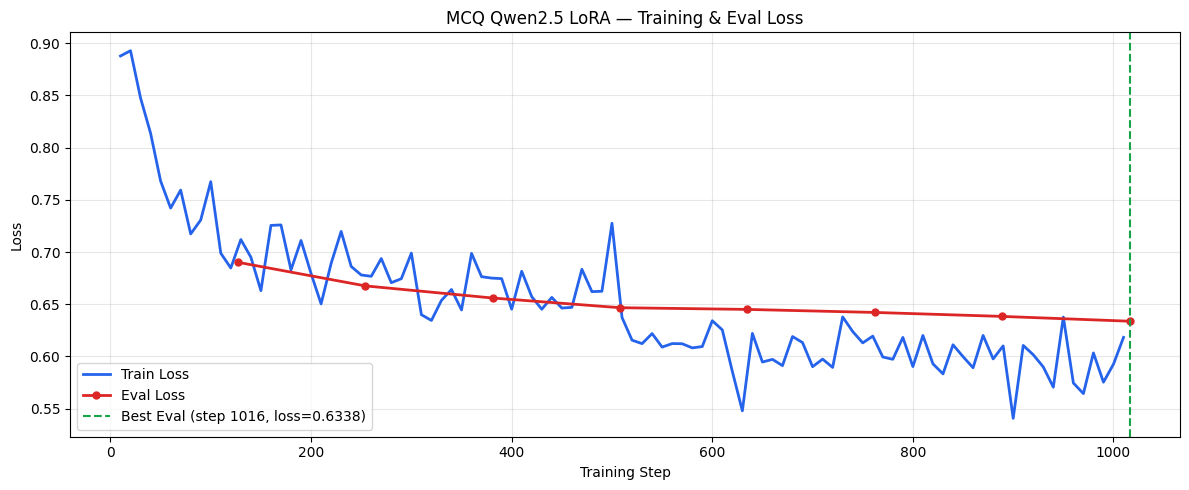

✓ Training curves saved → /kaggle/working/training_curves.png


In [55]:
import json, os
import matplotlib.pyplot as plt

# KAGGLE_LORA_DIR comes from Section 0
# trainer_state_path = os.path.join(KAGGLE_LORA_DIR, "trainer_state.json")
trainer_state_path = os.path.join(
    KAGGLE_LORA_DIR,
    "checkpoint-1016",
    "trainer_state.json"
)

if not os.path.exists(trainer_state_path):
    print("trainer_state.json not found — run training first.")
else:
    with open(trainer_state_path) as f:
        state = json.load(f)

    train_steps, train_losses = [], []
    eval_steps,  eval_losses  = [], []

    for entry in state.get("log_history", []):
        step = entry.get("step", 0)
        if "loss" in entry:
            train_steps.append(step)
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            eval_steps.append(step)
            eval_losses.append(entry["eval_loss"])

    fig, ax = plt.subplots(figsize=(12, 5))
    if train_losses:
        ax.plot(train_steps, train_losses, label="Train Loss", color="#2563EB", lw=2)
    if eval_losses:
        ax.plot(eval_steps, eval_losses, label="Eval Loss",  color="#DC2626", lw=2, marker="o", ms=5)
        best_idx = eval_losses.index(min(eval_losses))
        ax.axvline(eval_steps[best_idx], color="#16A34A", ls="--", lw=1.5,
                   label=f"Best Eval (step {eval_steps[best_idx]}, loss={min(eval_losses):.4f})")

    ax.set_xlabel("Training Step")
    ax.set_ylabel("Loss")
    ax.set_title("MCQ Qwen2.5 LoRA — Training & Eval Loss")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("/kaggle/working/training_curves.png", dpi=150)
    plt.show()
    print("✓ Training curves saved → /kaggle/working/training_curves.png")

### 11.14  Load the Merged Model for Inference

In [ ]:
# # import torch
# # from transformers import AutoModelForCausalLM, AutoTokenizer

# # DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# # # Load from the clean best-model output folder
# # KAGGLE_BEST_MERGED = "/kaggle/working/mcq-qwen-merged-best"
# # KAGGLE_MERGED_DIR  = "/kaggle/working/mcq-qwen-merged"

# # model_path = (
# #     KAGGLE_BEST_MERGED if os.path.exists(KAGGLE_BEST_MERGED)
# #     else KAGGLE_MERGED_DIR
# # )
# # print(f"Loading merged model from: {model_path}")

# # tokenizer = AutoTokenizer.from_pretrained(model_path)
# # model     = AutoModelForCausalLM.from_pretrained(
# #     model_path, torch_dtype=torch.bfloat16, device_map="auto"
# # )
# # model.eval()
# # print(f"✓ Merged model loaded on {DEVICE}")


# import torch
# from transformers import AutoModelForCausalLM, AutoTokenizer

# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# HF_MODEL_ID = "Rehab-Hamdy/mcq-bloom-qwen-merged_v3"  # <-- change to your real username

# print(f"Loading model from Hugging Face: {HF_MODEL_ID}")

# tokenizer = AutoTokenizer.from_pretrained(HF_MODEL_ID, token=HF_TOKEN)

# model = AutoModelForCausalLM.from_pretrained(
#     HF_MODEL_ID,
#     torch_dtype=torch.bfloat16,
#     device_map="auto",
#     token=HF_TOKEN
# )

# model.eval()
# print(f"✓ Model loaded on {DEVICE}")

In [56]:
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# KAGGLE_BEST_MERGED_DIR, KAGGLE_MERGED_DIR from Section 0.
model_path = (
    KAGGLE_BEST_MERGED_DIR
    if os.path.exists(KAGGLE_BEST_MERGED_DIR)
    else KAGGLE_MERGED_DIR
)

print(f"Loading merged model from: {model_path}")

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
model.eval()
print(f"✓ Merged model loaded on {DEVICE}")

Loading merged model from: /kaggle/working/mcq-qwen-merged-best_v6


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

✓ Merged model loaded on cuda


### 11.15  Inference Helper

In [57]:
import json as _json

def generate_mcq(messages: list, max_new_tokens: int = 512) -> dict:
    """
    Run MCQ inference with the merged fine-tuned model.

    Parameters
    ----------
    messages : list[dict]  [{role, content}, ...]  (system + user turns)
    max_new_tokens : int

    Returns
    -------
    dict  parsed MCQ {question, options, answer, explanation}
          or raw str if JSON parsing fails.
    """
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer([text], return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        out_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
        )

    new_ids = out_ids[0][inputs.input_ids.shape[1]:]
    raw     = tokenizer.decode(new_ids, skip_special_tokens=True)

    try:
        clean = raw.strip().lstrip("```json").lstrip("```").rstrip("```").strip()
        return _json.loads(clean)
    except _json.JSONDecodeError:
        print("[WARN] Response is not valid JSON — returning raw string.")
        return raw

print("✓ generate_mcq() defined.")


✓ generate_mcq() defined.


### 11.18  Pre-Training Checklist (Kaggle Edition)

Go through every item before launching 11.6. Fix any failure before training.

**Kaggle Environment**
- [ ] Running on Kaggle (NOT Colab)
- [ ] Dataset `ayakhaled51/mcqs-files` added via Notebook Settings → Add Data
- [ ] Input files visible at `/kaggle/input/datasets/ayakhaled51/mcqs-files/`
- [ ] `HF_TOKEN` set in Kaggle Secrets → Settings → Secrets
- [ ] `WANDB_API_KEY` set in Kaggle Secrets (or `WANDB_MODE=disabled`)
- [ ] `HF_USERNAME` set in Kaggle Secrets
- [ ] GPU enabled in Kaggle notebook settings (T4 × 2 recommended)
- [ ] `torch.cuda.is_available()` returns `True`
- [ ] Internet enabled in Kaggle (Settings → Internet → On)

**Data**
- [ ] `sft_metadata_conditioned.jsonl` exists and is non-empty (11.1)
- [ ] `CUTOFF_LEN` set automatically from P95 — not hardcoded (11.1)
- [ ] Bloom distribution: no level is 0% in any split (11.1 / 11.2)
- [ ] Answer distribution: no key exceeds 40% (11.1)
- [ ] `mcq_sft_train.jsonl`, `mcq_sft_val.jsonl` written (11.2)
- [ ] Split total equals full record count — assertion passed (11.2)

**LLaMA-Factory**
- [ ] `git clone` done, `llamafactory-cli version` printed (11.0)
- [ ] `dataset_info.json` updated with all three splits (11.3)
- [ ] Schema smoke-test printed `SCHEMA OK` (11.3)
- [ ] YAML `output_dir` is `/kaggle/working/mcq-lora-adapter` (NOT Drive)
- [ ] YAML `push_to_hub: true` + `hub_strategy: all_checkpoints` (auto-push checkpoints to HF)
- [ ] YAML `load_best_model_at_end: true` + `metric_for_best_model: eval_loss`
- [ ] YAML `bf16: true` — never change to `fp16` for Qwen2.5
- [ ] YAML `packing: false` — required for multi-turn ShareGPT records
- [ ] YAML `lora_alpha: 128` = 2 × `lora_rank: 64`

**Storage**
- [ ] Checkpoints go to HF Hub automatically (hub_strategy: all_checkpoints)
- [ ] No checkpoints saved to Drive or permanently on Kaggle
- [ ] Best LoRA + merged model copied to `/kaggle/working/*-best/` folders (11.10)
- [ ] Best LoRA + merged model → HF Hub (11.11)
- [ ] Local cleanup done (11.12)

**Post-training targets**
- [ ] Best checkpoint auto-selected by eval_loss (trainer_state.json checked in 11.7)
- [ ] Merged model contains `.safetensors` + `config.json` (11.9)
- [ ] Training curves plotted (11.13)


---

## 12. LLM-as-a-Judge Evaluation Framework

This section evaluates three model stages on the **same** inputs using a reference-free LLM-as-a-Judge approach:

| Stage | Model | Description |
|---|---|---|
| **Stage 1 — Teacher** | Gemini flash-2.5-lite | MCQs from `teacher_outputs.jsonl` — the quality ceiling |
| **Stage 2 — Student Pre-FT** | Base Qwen2.5-1.5B-Instruct | MCQs generated **before** fine-tuning |
| **Stage 3 — Student Post-FT** | Merged Qwen (LoRA) | MCQs generated **after** fine-tuning |

**Inputs per MCQ (no reference MCQs required):**
- Generated MCQ (question, options A–D, correct answer, explanation)
- MCQ metadata: Bloom level, chunk_type, concept / learning objective
- Source chunk text (ground truth for factual grounding)
- Chunk metadata: topic / domain from `selected_subset_v3.jsonl`

**Six evaluation dimensions (1–5 Likert each):**

| ID | Dimension | Weight |
|---|---|---|
| D1 | Factual Grounding | 25% |
| D2 | Question Clarity | 10% |
| D3 | Correct Answer Validity | 20% |
| D4 | Distractor Plausibility | 20% |
| D5 | Bloom Taxonomy Alignment | 15% |
| D6 | Topic & Learning Objective Alignment | 10% |

`CMQS = 0.25×D1 + 0.10×D2 + 0.20×D3 + 0.20×D4 + 0.15×D5 + 0.10×D6`

> **Resumable:** every stage resumes from the last completed sample if interrupted. No sample is re-evaluated.


### 12.0  Evaluation Paths & Configuration

In [82]:
# ─── 12.0  Evaluation Paths & Configuration ──────────────────────────────────
# All paths and constants come from Section 0 (Centralized Configuration).
# This cell only loads the GROQ_API_KEY secret and checks existing files.

import os
from os.path import join

try:
    from kaggle_secrets import UserSecretsClient
    _secrets = UserSecretsClient()
    GROQ_API_KEY = _secrets.get_secret("GROQ_API_KEY")
    os.environ["GROQ_API_KEY"] = GROQ_API_KEY
    print("GROQ_API_KEY loaded from Kaggle Secrets.")
except Exception as _e:
    GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "")
    status = "found" if GROQ_API_KEY else "MISSING"
    print(f"  GROQ_API_KEY fallback: {status}  ({_e})")

def _count_jsonl(path):
    if not os.path.exists(path):
        return 0
    n = 0
    with open(path, encoding="utf-8") as f:
        for line in f:
            if line.strip():
                n += 1
    return n

print()
print("Evaluation File Status")
print("-" * 80)
print(f"  {'File':<42} {'Records':>8}  Status")
print("-" * 80)
for label, path in [
    ("teacher_outputs (INPUT)",    TEACHER_OUTPUT_PATH),
    ("student_pre_ft_outputs",     STUDENT_PRE_OUTPUT_PATH),
    ("student_post_ft_outputs",    STUDENT_POST_OUTPUT_PATH),
    ("teacher_judge_scores",       TEACHER_SCORES_PATH),
    ("student_pre_ft_scores",      STUDENT_PRE_SCORES_PATH),
    ("student_post_ft_scores",     STUDENT_POST_SCORES_PATH),
    ("final_comparison (JSON)",    COMPARISON_PATH),
]:
    exists = os.path.exists(path)
    if exists:
        n = _count_jsonl(path)
        status = f"{n:>8,} records"
    else:
        status = "    NOT FOUND"
    icon = "ok" if exists else "--"
    print(f"  {icon}  {label:<42} {status}")

print()
print(f"Judge model  : {JUDGE_MODEL}")
print(f"Eval sample N: {EVAL_SAMPLE_N if EVAL_SAMPLE_N else 'ALL'}")
print()
print("RESUME GUIDANCE:")
print("  Generation (12.5-12.7): already-generated records are skipped automatically.")
print("  Scoring (12.8): already-scored records are skipped automatically.")
print("  Each record is appended immediately after scoring (no data loss on crash).")

GROQ_API_KEY loaded from Kaggle Secrets.

Evaluation File Status
--------------------------------------------------------------------------------
  File                                        Records  Status
--------------------------------------------------------------------------------
  ok  teacher_outputs (INPUT)                         200 records
  ok  student_pre_ft_outputs                          200 records
  ok  student_post_ft_outputs                         200 records
  ok  teacher_judge_scores                            200 records
  ok  student_pre_ft_scores                           191 records
  ok  student_post_ft_scores                          171 records
  --  final_comparison (JSON)                        NOT FOUND

Judge model  : llama-3.3-70b-versatile
Eval sample N: 200

RESUME GUIDANCE:
  Generation (12.5-12.7): already-generated records are skipped automatically.
  Scoring (12.8): already-scored records are skipped automatically.
  Each record is appended im

### 12.1  Judge Model — Free Groq Models

**Primary judge: `llama-3.3-70b-versatile` (Groq)**
Available for free via [Groq](https://console.groq.com/keys). Uses the OpenAI-compatible `/v1/chat/completions` API.
Get your free API key at https://console.groq.com/keys and add it as a Kaggle Secret named `GROQ_API_KEY`.

---

**Other free Groq model alternatives:**

| Model | Why suitable | Groq model slug |
|---|---|---|
| **`llama-3.3-70b-versatile`** (⭐ current) | Strongest open model; excellent JSON adherence; great for educational tasks | `llama-3.3-70b-versatile` |
| **`llama-3.1-70b-versatile`** | Previous generation; solid fallback | `llama-3.1-70b-versatile` |
| **`mixtral-8x7b-32768`** | Long context; good structured output | `mixtral-8x7b-32768` |
| **`gemma2-9b-it`** | Lightweight; fast; decent instruction following | `gemma2-9b-it` |

> **Important:** Do NOT use the same model family as your student (Qwen2.5-1.5B) as the judge — small models are unreliable as judges. The recommended free option is **llama-3.3-70b-versatile** on Groq.

To switch: change `JUDGE_MODEL` in Section 0 (Centralized Configuration).



### 12.2  Shared Utilities

In [59]:
# ─── 12.2  Shared Utilities ──────────────────────────────────────────────────
import json, os, time, re
from typing import Dict, List, Optional, Tuple

# ── JSON-L helpers ────────────────────────────────────────────────────────────

def load_jsonl_safe(path: str) -> List[Dict]:
    """Load a JSONL, skipping blank/malformed lines."""
    if not os.path.exists(path):
        return []
    records = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                pass
    return records


def append_jsonl(path: str, record: Dict) -> None:
    """Append one record to a JSONL file (atomic per-sample save)."""
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")


def load_done_ids(scores_path: str) -> set:
    """Return the set of chunk_id+slot_index keys already scored (for resume)."""
    done = set()
    for r in load_jsonl_safe(scores_path):
        key = f"{r.get('chunk_id','')}_{r.get('slot_index','')}"
        done.add(key)
    return done


def record_key(rec: Dict) -> str:
    return f"{rec.get('chunk_id','')}_{rec.get('slot_index','')}"

# ── Chunk lookup ──────────────────────────────────────────────────────────────

def build_chunk_lookup(chunks_path: str) -> Dict[str, Dict]:
    """Build chunk_id → chunk_record lookup from selected_subset_v3.jsonl."""
    lookup = {}
    for r in load_jsonl_safe(chunks_path):
        cid = r.get("chunk_id")
        if cid:
            lookup[cid] = r
    print(f"Chunk lookup built: {len(lookup):,} chunks from {os.path.basename(chunks_path)}")
    return lookup

# ══════════════════════════════════════════════════════════════════════════════
# ── Groq LLM Judge Caller ────────────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

def call_judge(
    prompt_messages: List[Dict],
    model: str = None,
    max_retries: int = 3,
    retry_delay: float = 5.0,
) -> Optional[str]:
    """
    Call the LLM judge via Groq's OpenAI-compatible API.

    Uses the GROQ_API_KEY Kaggle secret and GROQ_BASE_URL.
    The model can be any Groq model slug (e.g. 'llama-3.3-70b-versatile').
    Get your free API key at https://console.groq.com/keys

    Parameters
    ----------
    prompt_messages : list of {role, content} dicts (system + user)
    model           : Groq model slug. Defaults to global JUDGE_MODEL.
    max_retries     : number of retry attempts on failure
    retry_delay     : seconds between retries (with exponential back-off)

    Returns
    -------
    Raw text content of the response, or None on total failure.
    """
    try:
        import openai
    except ImportError:
        raise ImportError("Run: pip install -q openai")

    if model is None:
        model = JUDGE_MODEL

    # Build the Groq client (uses OpenAI-compatible API)
    api_key = os.environ.get("GROQ_API_KEY", "")
    if not api_key:
        raise ValueError(
            "GROQ_API_KEY not found. "
            "Add it as a Kaggle Secret: Notebook → Add-ons → Secrets → "
            "Name: GROQ_API_KEY, Value: your key from https://console.groq.com/keys"
        )

    client = openai.OpenAI(
        base_url=GROQ_BASE_URL,
        api_key=api_key,
    )

    for attempt in range(1, max_retries + 1):
        try:
            resp = client.chat.completions.create(
                model=model,
                messages=prompt_messages,
                temperature=0.1,
                max_tokens=1024,
                # Note: response_format={"type":"json_object"} may not be
                # supported by all OpenRouter models. We handle JSON parsing
                # in parse_judge_json() with fallback stripping.
            )
            content = resp.choices[0].message.content
            if content:
                return content
            print(f"  [Judge] Attempt {attempt}: empty response, retrying...")
        except Exception as exc:
            print(f"  [Judge] Attempt {attempt}/{max_retries} failed: {exc}")
            if attempt < max_retries:
                wait = retry_delay * (2 ** (attempt - 1))  # exponential back-off
                time.sleep(wait)
    return None


def parse_judge_json(raw: Optional[str]) -> Optional[Dict]:
    """Parse judge response JSON, stripping any markdown fences."""
    if not raw:
        return None
    try:
        clean = raw.strip()
        # Strip markdown code fences if present
        clean = re.sub(r"^```json\s*", "", clean)
        clean = re.sub(r"^```\s*", "", clean)
        clean = re.sub(r"\s*```$", "", clean)
        return json.loads(clean)
    except json.JSONDecodeError:
        # Try to find JSON object in the response
        match = re.search(r'\{.*\}', raw, re.DOTALL)
        if match:
            try:
                return json.loads(match.group())
            except json.JSONDecodeError:
                pass
        return None


def compute_cmqs(scores: Dict) -> float:
    """Compute weighted CMQS from dimension scores dict."""
    weights = {
        "D1_factual_grounding":      0.25,
        "D2_question_clarity":       0.10,
        "D3_correct_answer_validity":0.20,
        "D4_distractor_plausibility":0.20,
        "D5_bloom_alignment":        0.15,
        "D6_topic_lo_alignment":     0.10,
    }
    total, weight_sum = 0.0, 0.0
    for key, w in weights.items():
        val = scores.get(key, {})
        s = val.get("score") if isinstance(val, dict) else val
        if s is not None:
            total += float(s) * w
            weight_sum += w
    if weight_sum == 0:
        return 0.0
    return round(total / weight_sum, 4)


print("✓ Shared utilities defined (Groq backend).")
print(f"  Judge model  : {JUDGE_MODEL}")
print(f"  Base URL     : {GROQ_BASE_URL}")


✓ Shared utilities defined (Groq backend).
  Judge model  : llama-3.3-70b-versatile
  Base URL     : https://api.groq.com/openai/v1


### 12.3  LLM Judge Prompt Builder

In [60]:
# ─── 12.3  LLM Judge Prompt Builder ─────────────────────────────────────────

JUDGE_SYSTEM_PROMPT = """You are an expert educational assessment evaluator with deep knowledge of Bloom's Taxonomy and MCQ item analysis.
You will receive a multiple-choice question (MCQ), its metadata, and the source text chunk it was generated from.
The source chunk is the ONLY source of truth for factual correctness.
Evaluate the MCQ on exactly six dimensions using a strict 1-5 integer scale.
Output ONLY valid JSON. No preamble, explanation, or text outside the JSON object.""".strip()

JUDGE_USER_TEMPLATE = """=== SOURCE CHUNK ===
{source_text}

=== CHUNK METADATA ===
Chunk Type: {chunk_type}
Concept / Topic: {concept}

=== GENERATED MCQ ===
Question: {question}
A) {opt_a}
B) {opt_b}
C) {opt_c}
D) {opt_d}
Correct Answer: {correct_answer}

=== MCQ METADATA ===
Bloom Taxonomy Level: {bloom_level}
Focus Concept: {focus_concept}

=== EVALUATION TASK ===
Score each dimension from 1 (worst) to 5 (best) using ONLY the provided content above.

D1 - Factual Grounding (weight 25%):
  Is every statement in the question stem AND all four options directly supported by the source chunk?
  5=fully grounded, 4=one minor implicit inference, 3=one ungrounded claim, 2=multiple hallucinations, 1=largely hallucinated

D2 - Question Clarity (weight 10%):
  Is the question grammatically correct, unambiguous, and self-contained?
  5=perfect, 4=minor verbosity/grammar, 3=some ambiguity, 2=notably unclear, 1=incomprehensible

D3 - Correct Answer Validity (weight 20%):
  Is the designated correct answer factually correct per the source chunk AND unambiguously better than all distractors?
  5=unambiguously correct, 4=correct but slightly imprecise, 3=correct but a distractor is close, 2=partially correct, 1=wrong

D4 - Distractor Plausibility (weight 20%):
  Are ALL three distractors plausible to a student without mastery? Clearly wrong only to an expert?
  5=all highly plausible/misconception-based, 4=mostly plausible, 3=mixed quality, 2=mostly implausible, 1=trivially wrong/irrelevant

D5 - Bloom Alignment (weight 15%):
  Does the cognitive demand required to answer match the assigned Bloom level ({bloom_level})?
  Levels: remember<understand<apply<analyze<evaluate<create
  5=exact match, 4=one adjacent level, 3=adjacent level, 2=two+ levels off, 1=completely wrong

D6 - Topic & Learning Objective Alignment (weight 10%):
  Does the question genuinely test the focus concept and match the chunk's topic?
  5=fully aligned, 4=mostly aligned, 3=loosely related, 2=tangentially related, 1=off-topic

Return EXACTLY this JSON structure (integer scores, one-sentence reasons):
{{
  "D1_factual_grounding":       {{"score": <1-5>, "reason": "<one sentence>"}},
  "D2_question_clarity":        {{"score": <1-5>, "reason": "<one sentence>"}},
  "D3_correct_answer_validity": {{"score": <1-5>, "reason": "<one sentence>"}},
  "D4_distractor_plausibility": {{"score": <1-5>, "reason": "<one sentence>"}},
  "D5_bloom_alignment":         {{"score": <1-5>, "reason": "<one sentence>"}},
  "D6_topic_lo_alignment":      {{"score": <1-5>, "reason": "<one sentence>"}}
}}""".strip()


def build_judge_messages(mcq_record: Dict, chunk_record: Dict) -> List[Dict]:
    """
    Build the [system, user] message list for the LLM judge.

    Parameters
    ----------
    mcq_record   : one record from teacher / student output JSONL
                   Must have: chunk_id, text, bloom_level, chunk_type,
                              concept, mcq {question, options, answer}
    chunk_record : matching record from selected_subset_v3.jsonl
                   Must have: text, metadata {bloom_level, chunk_type, concepts}
    """
    # ── Extract MCQ fields ─────────────────────────────────────────────────────
    mcq      = mcq_record.get("mcq", {})
    question = mcq.get("question", "").strip()
    options  = mcq.get("options", {})
    answer   = mcq.get("answer", "").strip().upper()
    bloom    = mcq_record.get("bloom_level", "").strip()
    concept  = mcq_record.get("concept", "").strip()
    chunk_t  = mcq_record.get("chunk_type", "").strip()

    # Source text: prefer chunk_record text (canonical), fall back to mcq_record text
    source_text = chunk_record.get("text", mcq_record.get("text", "")).strip()

    # Chunk metadata for domain / concept context
    chunk_meta   = chunk_record.get("metadata", {})
    chunk_type_c = chunk_meta.get("chunk_type", chunk_t) or chunk_t
    concepts_c   = chunk_meta.get("concepts", [concept]) or [concept]
    concept_str  = ", ".join(concepts_c) if concepts_c else concept

    user_content = JUDGE_USER_TEMPLATE.format(
        source_text    = source_text,
        chunk_type     = chunk_type_c,
        concept        = concept_str,
        question       = question,
        opt_a          = options.get("A", ""),
        opt_b          = options.get("B", ""),
        opt_c          = options.get("C", ""),
        opt_d          = options.get("D", ""),
        correct_answer = answer,
        bloom_level    = bloom,
        focus_concept  = concept,
    )

    return [
        {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
        {"role": "user",   "content": user_content},
    ]


print("✓ Judge prompt builder defined.")
print(f"  System prompt : {len(JUDGE_SYSTEM_PROMPT):,} chars")
print(f"  User template : {len(JUDGE_USER_TEMPLATE):,} chars")

✓ Judge prompt builder defined.
  System prompt : 457 chars
  User template : 2,555 chars


### 12.4  Core Evaluation Runner (Resumable)

In [61]:
# ─── 12.4  Core Evaluation Runner (resumable) ────────────────────────────────
from tqdm.auto import tqdm

def evaluate_stage(
    records:        List[Dict],
    chunk_lookup:   Dict[str, Dict],
    scores_path:    str,
    stage_label:    str,
) -> List[Dict]:
    """
    Run LLM-as-a-Judge evaluation on a list of MCQ records.
    Fully resumable: already-scored records are skipped.

    Parameters
    ----------
    records       : list of MCQ records (teacher or student output JSONL)
    chunk_lookup  : chunk_id -> chunk_record from selected_subset_v3.jsonl
    scores_path   : path to JSONL file where scores are appended
    stage_label   : "teacher" | "student_pre_ft" | "student_post_ft"

    Returns
    -------
    list of all score records (previously saved + newly computed)
    """
    done_ids   = load_done_ids(scores_path)
    all_scores = load_jsonl_safe(scores_path)

    to_score = [r for r in records if record_key(r) not in done_ids]
    print(f"\n{'='*60}")
    print(f"Stage        : {stage_label}")
    print(f"Total records: {len(records):,}")
    print(f"Already done : {len(done_ids):,}")
    print(f"To evaluate  : {len(to_score):,}")
    print(f"Scores file  : {scores_path}")
    print(f"{'='*60}")

    if not to_score:
        print("✓ All records already evaluated. Nothing to do.")
        return all_scores

    skipped, failed = 0, 0

    for rec in tqdm(to_score, desc=f"Judging [{stage_label}]"):
        chunk_id    = rec.get("chunk_id", "")
        slot_index  = rec.get("slot_index", 0)
        chunk_rec   = chunk_lookup.get(chunk_id, {})

        # Skip records with no matching chunk (can't evaluate grounding)
        if not chunk_rec:
            skipped += 1
            score_rec = {
                "chunk_id":    chunk_id,
                "slot_index":  slot_index,
                "stage":       stage_label,
                "status":      "skipped_no_chunk",
                "CMQS":        None,
                "scores":      None,
            }
            append_jsonl(scores_path, score_rec)
            all_scores.append(score_rec)
            continue

        # Validate MCQ structure
        mcq = rec.get("mcq", {})
        if not mcq.get("question") or not mcq.get("options") or not mcq.get("answer"):
            skipped += 1
            score_rec = {
                "chunk_id":   chunk_id,
                "slot_index": slot_index,
                "stage":      stage_label,
                "status":     "skipped_invalid_mcq",
                "CMQS":       None,
                "scores":     None,
            }
            append_jsonl(scores_path, score_rec)
            all_scores.append(score_rec)
            continue

        # Build judge prompt and call judge
        messages = build_judge_messages(rec, chunk_rec)
        raw_resp = call_judge(messages, model=JUDGE_MODEL)
        parsed   = parse_judge_json(raw_resp)

        if parsed is None:
            failed += 1
            score_rec = {
                "chunk_id":    chunk_id,
                "slot_index":  slot_index,
                "stage":       stage_label,
                "status":      "judge_parse_failed",
                "raw_response":raw_resp,
                "CMQS":        None,
                "scores":      None,
            }
            append_jsonl(scores_path, score_rec)
            all_scores.append(score_rec)
            continue

        # Validate all 6 dimension scores are present and in [1,5]
        dim_keys = [
            "D1_factual_grounding", "D2_question_clarity",
            "D3_correct_answer_validity", "D4_distractor_plausibility",
            "D5_bloom_alignment", "D6_topic_lo_alignment",
        ]
        dim_scores_valid = all(
            isinstance(parsed.get(k, {}).get("score"), (int, float))
            and 1 <= parsed[k]["score"] <= 5
            for k in dim_keys
            if k in parsed
        )
        if not dim_scores_valid or not all(k in parsed for k in dim_keys):
            failed += 1
            score_rec = {
                "chunk_id":    chunk_id,
                "slot_index":  slot_index,
                "stage":       stage_label,
                "status":      "judge_schema_invalid",
                "raw_response":raw_resp,
                "CMQS":        None,
                "scores":      parsed,
            }
            append_jsonl(scores_path, score_rec)
            all_scores.append(score_rec)
            continue

        # Success — compute CMQS and save
        cmqs = compute_cmqs(parsed)
        score_rec = {
            "chunk_id":   chunk_id,
            "slot_index": slot_index,
            "bloom_level":rec.get("bloom_level", ""),
            "chunk_type": rec.get("chunk_type", ""),
            "stage":      stage_label,
            "status":     "ok",
            "CMQS":       cmqs,
            "scores": {
                k: parsed[k]
                for k in dim_keys
            },
        }
        append_jsonl(scores_path, score_rec)
        all_scores.append(score_rec)

    print(f"\n✓ Done.  Skipped={skipped}  Failed={failed}  "
          f"Scored={len(to_score)-skipped-failed}")
    return all_scores


print("✓ evaluate_stage() defined.")

✓ evaluate_stage() defined.


### 12.5  Build Shared Evaluation Sample

In [62]:
# ─── 12.5  Build Shared Evaluation Sample ────────────────────────────────────
# We evaluate all three models on the SAME set of chunk inputs.
# The teacher JSONL is the reference for which chunks to evaluate.
# Student models are run on the same chunk_ids.

import random
from collections import defaultdict

# ── Load teacher outputs & chunk lookup ──────────────────────────────────────
chunk_lookup = build_chunk_lookup(CHUNKS_PATH)

teacher_records_all = load_jsonl_safe(TEACHER_OUTPUT_PATH)
if not teacher_records_all:
    raise FileNotFoundError(
        f"Teacher output file not found or empty: {TEACHER_OUTPUT_PATH}\n"
        "Ensure 'teacher_outputs.jsonl' is in your Kaggle input dataset."
    )
print(f"Teacher records loaded: {len(teacher_records_all):,}")

# ── Stratified sample by Bloom level (or use all) ────────────────────────────
def stratified_sample(records: List[Dict], n: Optional[int], seed: int = 42) -> List[Dict]:
    """
    Return a stratified random sample of n records balanced by Bloom level.
    If n is None or n >= len(records), returns all records (shuffled).
    """
    if n is None or n >= len(records):
        rng = random.Random(seed)
        out = records[:]
        rng.shuffle(out)
        return out

    by_bloom = defaultdict(list)
    for r in records:
        by_bloom[r.get("bloom_level", "unknown")].append(r)

    n_levels  = len(by_bloom)
    per_level = max(1, n // n_levels)
    rng       = random.Random(seed)
    sampled   = []
    for bloom_recs in by_bloom.values():
        rng.shuffle(bloom_recs)
        sampled.extend(bloom_recs[:per_level])

    # top-up if under n due to rounding
    rng.shuffle(sampled)
    remaining = [r for r in records if r not in sampled]
    rng.shuffle(remaining)
    sampled.extend(remaining[:max(0, n - len(sampled))])
    rng.shuffle(sampled)
    return sampled[:n]

teacher_eval_records = stratified_sample(teacher_records_all, EVAL_SAMPLE_N)
eval_chunk_ids       = {r["chunk_id"] for r in teacher_eval_records}

print(f"\nEvaluation sample:")
print(f"  Teacher records : {len(teacher_eval_records):,}")
print(f"  Unique chunk_ids: {len(eval_chunk_ids):,}")

from collections import Counter
bloom_dist = Counter(r.get("bloom_level", "?") for r in teacher_eval_records)
print("  Bloom distribution:")
for lvl, cnt in sorted(bloom_dist.items()):
    print(f"    {lvl:<12}: {cnt:3d}  ({cnt/len(teacher_eval_records):.1%})")

Chunk lookup built: 1,500 chunks from selected_subset_v3.jsonl
Teacher records loaded: 200

Evaluation sample:
  Teacher records : 200
  Unique chunk_ids: 200
  Bloom distribution:
    analyze     :  53  (26.5%)
    apply       :  54  (27.0%)
    create      :  14  (7.0%)
    evaluate    :  28  (14.0%)
    remember    :   7  (3.5%)
    understand  :  44  (22.0%)


### 12.6  Student Model Inference — Pre-Fine-Tuning

Generates MCQs using the **base Qwen2.5-1.5B-Instruct** model (before fine-tuning).
Uses the exact same system + user prompt format as the SFT training pipeline.
Fully resumable — skips already-generated samples.


In [63]:
def _run_student_inference(
    model, tokenizer, messages: List[Dict], max_new_tokens: int = 512
) -> dict:
    """Run a single inference call. Returns parsed MCQ dict or raw str."""
    text   = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([text], return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
        )
    new_ids = out_ids[0][inputs.input_ids.shape[1]:]
    raw     = tokenizer.decode(new_ids, skip_special_tokens=True)
    try:
        clean = raw.strip()
        clean = re.sub(r"^```json\s*", "", clean)
        clean = re.sub(r"^```\s*", "", clean)
        clean = re.sub(r"\s*```$", "", clean)
        return json.loads(clean)
    except json.JSONDecodeError:
        return {"_raw": raw}


def generate_student_outputs(
    model, tokenizer,
    teacher_eval_records: List[Dict],
    chunk_lookup:         Dict[str, Dict],
    output_path:          str,
    stage_label:          str,
) -> List[Dict]:
    """
    Generate MCQ outputs for all teacher eval records using the given model.
    Uses the EXACT same SFT prompt format (SFT_SYSTEM_PROMPT + build_user_prompt_conditioned).
    Fully resumable: skips already-generated samples.
    Returns list of all output records.
    """
    # Load already-done IDs
    existing     = load_jsonl_safe(output_path)
    done_keys    = {record_key(r) for r in existing}
    all_outputs  = existing[:]
    to_generate  = [r for r in teacher_eval_records if record_key(r) not in done_keys]

    print(f"\n{'='*60}")
    print(f"Stage         : {stage_label}")
    print(f"Total records : {len(teacher_eval_records):,}")
    print(f"Already done  : {len(done_keys):,}")
    print(f"To generate   : {len(to_generate):,}")
    print(f"Output file   : {output_path}")
    print(f"{'='*60}")

    if not to_generate:
        print("✓ All outputs already generated.")
        return all_outputs

    for rec in tqdm(to_generate, desc=f"Generating [{stage_label}]"):
        chunk_id   = rec.get("chunk_id", "")
        slot_index = rec.get("slot_index", 0)
        chunk_rec  = chunk_lookup.get(chunk_id, {})

        # Build the slot dict expected by build_user_prompt_conditioned
        s3_meta   = chunk_rec.get("metadata", {})
        fringe    = chunk_rec.get("context_fringe", {})
        slot = {
            "text":          chunk_rec.get("text", rec.get("text", "")),
            "bloom_level":   rec.get("bloom_level", s3_meta.get("bloom_level", "understand")),
            "chunk_type":    rec.get("chunk_type",  s3_meta.get("chunk_type", "definition")),
            "concept":       rec.get("concept",     (s3_meta.get("concepts") or [""])[0]),
            "keywords":      s3_meta.get("keywords", []),
            "prev_sentence": (fringe.get("prev_sentence") or "").strip(),
            "next_sentence": (fringe.get("next_sentence") or "").strip(),
        }

        messages = [
            {"role": "system", "content": SFT_SYSTEM_PROMPT},
            {"role": "user",   "content": build_user_prompt_conditioned(slot)},
        ]

        generated_mcq = _run_student_inference(model, tokenizer, messages)

        output_rec = {
            "chunk_id":   chunk_id,
            "slot_index": slot_index,
            "text":       slot["text"],
            "chunk_type": slot["chunk_type"],
            "concept":    slot["concept"],
            "bloom_level":slot["bloom_level"],
            "stage":      stage_label,
            "mcq": generated_mcq if isinstance(generated_mcq, dict) and "_raw" not in generated_mcq
                   else {"question": "", "options": {}, "answer": "", "explanation": "",
                         "_raw_unparsed": generated_mcq.get("_raw", "")},
        }
        append_jsonl(output_path, output_rec)
        all_outputs.append(output_rec)

    print(f"\n✓ Generation complete: {len(all_outputs):,} total records in {output_path}")
    return all_outputs

In [64]:
# ─── 12.6  Student Inference — Pre-Fine-Tuning ───────────────────────────────
# RESUMABLE: already-generated records are skipped automatically.
# If all records are already done, the model is not loaded at all.

import torch, gc, os
from transformers import AutoModelForCausalLM, AutoTokenizer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ── Check if generation is already complete ───────────────────────────────────
_existing_pre  = load_jsonl_safe(STUDENT_PRE_OUTPUT_PATH)
_done_pre_keys = {record_key(r) for r in _existing_pre}
_still_needed  = [r for r in teacher_eval_records if record_key(r) not in _done_pre_keys]

print(f"Pre-FT outputs already generated : {len(_existing_pre):,}")
print(f"Still needed                      : {len(_still_needed):,}")

if not _still_needed:
    print("All pre-FT outputs already exist -- skipping model load.")
    pre_ft_outputs = _existing_pre
else:
    # ── Resolve model path: prefer read-only Kaggle input ─────────────────────
    if "BASE_MODEL_PATH" in dir() and os.path.exists(BASE_MODEL_PATH):
        pre_ft_model_path = BASE_MODEL_PATH
    elif os.path.exists(KAGGLE_MODEL_DIR):
        pre_ft_model_path = KAGGLE_MODEL_DIR
    else:
        raise RuntimeError(
            "Base model not found locally. "
            "Run cell 4 (model path check) to set BASE_MODEL_PATH."
        )

    print(f"Loading base model from: {pre_ft_model_path}")
    pre_tokenizer = AutoTokenizer.from_pretrained(pre_ft_model_path, token=HF_TOKEN)
    pre_model     = AutoModelForCausalLM.from_pretrained(
        pre_ft_model_path,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        token=HF_TOKEN,
    )
    pre_model.eval()
    print(f"Pre-FT model loaded on {DEVICE}")

    pre_ft_outputs = generate_student_outputs(
        model                = pre_model,
        tokenizer            = pre_tokenizer,
        teacher_eval_records = teacher_eval_records,
        chunk_lookup         = chunk_lookup,
        output_path          = STUDENT_PRE_OUTPUT_PATH,
        stage_label          = "student_pre_ft",
    )

    del pre_model
    gc.collect()
    torch.cuda.empty_cache()
    print("Pre-FT model unloaded from GPU.")

Pre-FT outputs already generated : 200
Still needed                      : 0
All pre-FT outputs already exist -- skipping model load.


### 12.7  Student Model Inference — Post-Fine-Tuning

Generates MCQs using the **merged fine-tuned Qwen model** (after LoRA fine-tuning).
Uses the same prompt format. Fully resumable.


In [65]:
# ─── 12.7  Student Inference — Post-Fine-Tuning ──────────────────────────────
# RESUMABLE: already-generated records are skipped automatically.
# All paths come from Section 0 (Centralized Configuration).

import os, torch, gc
from transformers import AutoModelForCausalLM, AutoTokenizer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

_existing_post  = load_jsonl_safe(STUDENT_POST_OUTPUT_PATH)
_done_post_keys = {record_key(r) for r in _existing_post}
_still_needed_post = [r for r in teacher_eval_records if record_key(r) not in _done_post_keys]

print(f"Post-FT outputs already generated : {len(_existing_post):,}")
print(f"Still needed                       : {len(_still_needed_post):,}")

if not _still_needed_post:
    print("All post-FT outputs already exist -- skipping model load.")
    post_ft_outputs = _existing_post
else:
    # ── Resolve post-FT model path from config ────────────────────────────────
    if os.path.exists(KAGGLE_BEST_MERGED_DIR):
        post_ft_model_path = KAGGLE_BEST_MERGED_DIR
    elif os.path.exists(KAGGLE_MERGED_DIR):
        post_ft_model_path = KAGGLE_MERGED_DIR
    elif "MERGED_REPO_ID" in dir():
        print(f"Local merged model not found -- loading from HF: {MERGED_REPO_ID}")
        post_ft_model_path = MERGED_REPO_ID
    else:
        raise RuntimeError(
            "No local merged model found and MERGED_REPO_ID is not set.\n"
            "Run 11.9 (merge) and 11.10 (copy) first, or set MERGED_REPO_ID."
        )

    print(f"Loading post-FT model from: {post_ft_model_path}")
    post_tokenizer = AutoTokenizer.from_pretrained(post_ft_model_path, token=HF_TOKEN)
    post_model     = AutoModelForCausalLM.from_pretrained(
        post_ft_model_path,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        token=HF_TOKEN,
    )
    post_model.eval()
    print(f"Post-FT model loaded on {DEVICE}")

    post_ft_outputs = generate_student_outputs(
        model                = post_model,
        tokenizer            = post_tokenizer,
        teacher_eval_records = teacher_eval_records,
        chunk_lookup         = chunk_lookup,
        output_path          = STUDENT_POST_OUTPUT_PATH,
        stage_label          = "student_post_ft",
    )

    del post_model
    gc.collect()
    torch.cuda.empty_cache()
    print("Post-FT model unloaded from GPU.")

Post-FT outputs already generated : 0
Still needed                       : 200
Loading post-FT model from: /kaggle/working/mcq-qwen-merged-best_v6


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Post-FT model loaded on cuda

Stage         : student_post_ft
Total records : 200
Already done  : 0
To generate   : 200
Output file   : /kaggle/working/evaluation/student_post_ft_outputs.jsonl


Generating [student_post_ft]:   0%|          | 0/200 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



✓ Generation complete: 200 total records in /kaggle/working/evaluation/student_post_ft_outputs.jsonl
Post-FT model unloaded from GPU.


### 12.8  Run LLM Judge on All Three Stages

Evaluates each model's outputs independently. Each stage is fully resumable.


In [68]:
# import json

# file_path = TEACHER_OUTPUT_PATH

# cleaned_lines = []

# with open(file_path, "r", encoding="utf-8") as f:
#     for line in f:
#         line = line.strip()
#         if not line:
#             continue

#         try:
#             obj = json.loads(line)
#         except json.JSONDecodeError:
#             continue

#         # Remove ONLY if ALL conditions are true
#         if (
#             obj.get("status") == "judge_parse_failed"
#             and obj.get("raw_response") is None
#             and obj.get("CMQS") is None
#             and obj.get("scores") is None
#         ):
#             continue

#         cleaned_lines.append(obj)

# with open(file_path, "w", encoding="utf-8") as f:
#     for obj in cleaned_lines:
#         f.write(json.dumps(obj, ensure_ascii=False) + "\n")

# print(f"✓ Done cleaning file")
# print(f"Remaining records: {len(cleaned_lines)}")

In [69]:
# ─── 12.8  Run LLM Judge — All Three Stages ──────────────────────────────────

# Install openai if not available
try:
    import openai
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openai"])
    import openai

print(f"Using judge model: {JUDGE_MODEL}")
print()

# ── Stage 1: Teacher ──────────────────────────────────────────────────────────
teacher_scores = evaluate_stage(
    records      = teacher_eval_records,
    chunk_lookup = chunk_lookup,
    scores_path  = TEACHER_SCORES_PATH,
    stage_label  = "teacher",
)

Using judge model: llama-3.3-70b-versatile


Stage        : teacher
Total records: 200
Already done : 200
To evaluate  : 0
Scores file  : /kaggle/input/datasets/ayakhaled51/mcqs-files/teacher_judge_scores.jsonl
✓ All records already evaluated. Nothing to do.


In [72]:
# import json

# file_path = "/kaggle/working/evaluation/student_pre_ft_judge_scores.jsonl"

# cleaned_lines = []

# with open(file_path, "r", encoding="utf-8") as f:
#     for line in f:
#         line = line.strip()
#         if not line:
#             continue

#         try:
#             obj = json.loads(line)
#         except json.JSONDecodeError:
#             continue

#         # Remove ONLY if ALL conditions are true
#         if (
#             obj.get("status") == "judge_parse_failed"
#             and obj.get("raw_response") is None
#             and obj.get("CMQS") is None
#             and obj.get("scores") is None
#         ):
#             continue

#         cleaned_lines.append(obj)

# with open(file_path, "w", encoding="utf-8") as f:
#     for obj in cleaned_lines:
#         f.write(json.dumps(obj, ensure_ascii=False) + "\n")

# print(f"✓ Done cleaning file")
# print(f"Remaining records: {len(cleaned_lines)}")

In [70]:
# ── Stage 2: Student Pre-FT ───────────────────────────────────────────────────
# Filter pre_ft_outputs to only records that have a valid MCQ (skip parse failures)
valid_pre_ft = [
    r for r in pre_ft_outputs
    if r.get("mcq", {}).get("question")
]
print(f"\nPre-FT valid MCQs for judging: {len(valid_pre_ft):,} / {len(pre_ft_outputs):,}")

student_pre_scores = evaluate_stage(
    records      = valid_pre_ft,
    chunk_lookup = chunk_lookup,
    scores_path  = STUDENT_PRE_SCORES_PATH,
    stage_label  = "student_pre_ft",
)


Pre-FT valid MCQs for judging: 191 / 200

Stage        : student_pre_ft
Total records: 191
Already done : 191
To evaluate  : 0
Scores file  : /kaggle/input/datasets/ayakhaled51/mcqs-files/student_pre_ft_judge_scores.jsonl
✓ All records already evaluated. Nothing to do.


In [85]:
import json

file_path = "/kaggle/working/evaluation/student_post_ft_judge_scores.jsonl"

cleaned_lines = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        try:
            obj = json.loads(line)
        except json.JSONDecodeError:
            continue

        # Remove ONLY if ALL conditions are true
        if (
            obj.get("status") == "judge_parse_failed"
            and obj.get("raw_response") is None
            and obj.get("CMQS") is None
            and obj.get("scores") is None
        ):
            continue

        cleaned_lines.append(obj)

with open(file_path, "w", encoding="utf-8") as f:
    for obj in cleaned_lines:
        f.write(json.dumps(obj, ensure_ascii=False) + "\n")

print(f"✓ Done cleaning file")
print(f"Remaining records: {len(cleaned_lines)}")

✓ Done cleaning file
Remaining records: 200


In [86]:
# ── Stage 3: Student Post-FT ──────────────────────────────────────────────────
valid_post_ft = [
    r for r in post_ft_outputs
    if r.get("mcq", {}).get("question")
]
print(f"\nPost-FT valid MCQs for judging: {len(valid_post_ft):,} / {len(post_ft_outputs):,}")

student_post_scores = evaluate_stage(
    records      = valid_post_ft,
    chunk_lookup = chunk_lookup,
    scores_path  = STUDENT_POST_SCORES_PATH,
    stage_label  = "student_post_ft",
)


Post-FT valid MCQs for judging: 200 / 200

Stage        : student_post_ft
Total records: 200
Already done : 200
To evaluate  : 0
Scores file  : /kaggle/working/evaluation/student_post_ft_judge_scores.jsonl
✓ All records already evaluated. Nothing to do.


In [94]:
"""
repair_jsonl.py
---------------
Repairs malformed raw_response fields in a JSONL evaluation file produced by
an LLM judge.  Common errors handled:
  - extra `]` before a closing `}`
  - missing closing `}` at the end
  - trailing commas before `}` or `]`
  - mismatched / unbalanced brackets
  - whitespace / control characters that confuse the parser
"""

from __future__ import annotations

import copy
import json
import re
import shutil
from pathlib import Path
from typing import Optional

# ---------------------------------------------------------------------------
# 1.  Core repair function
# ---------------------------------------------------------------------------

def repair_json_response(raw_response: str) -> Optional[dict]:
    """
    Try to convert a malformed JSON string into a Python dict.

    Applies a sequence of increasingly aggressive fixes, stopping as soon as
    `json.loads` succeeds.  Returns the parsed dict, or None if every
    strategy fails.
    """
    if not isinstance(raw_response, str):
        return None

    # ── Strategy 0: try as-is ────────────────────────────────────────────
    try:
        result = json.loads(raw_response)
        if isinstance(result, dict):
            return result
    except json.JSONDecodeError:
        pass

    text = raw_response

    # ── Strategy 1: strip leading/trailing whitespace ────────────────────
    text = text.strip()
    try:
        result = json.loads(text)
        if isinstance(result, dict):
            return result
    except json.JSONDecodeError:
        pass

    # ── Strategy 2: remove trailing commas before } or ] ────────────────
    text = re.sub(r",\s*([}\]])", r"\1", text)
    try:
        result = json.loads(text)
        if isinstance(result, dict):
            return result
    except json.JSONDecodeError:
        pass

    # ── Strategy 3: fix "}]}" and similar – stray ] before final } ──────
    # Pattern: a `]` that immediately precedes the outermost closing `}`
    # e.g.  ...\"value\"]\\n}
    text = re.sub(r"\]\s*\n?\s*\}", "}\n}", text)
    try:
        result = json.loads(text)
        if isinstance(result, dict):
            return result
    except json.JSONDecodeError:
        pass

    # ── Strategy 4: remove *all* stray `]` that do not have a matching `[`
    def remove_unmatched_brackets(s: str) -> str:
        """Remove ] characters that have no corresponding [ before them."""
        depth = 0
        chars = []
        for ch in s:
            if ch == "[":
                depth += 1
                chars.append(ch)
            elif ch == "]":
                if depth > 0:
                    depth -= 1
                    chars.append(ch)
                # else: skip this unmatched ]
            else:
                chars.append(ch)
        return "".join(chars)

    cleaned = remove_unmatched_brackets(text)
    # Also remove trailing commas again after bracket removal
    cleaned = re.sub(r",\s*([}\]])", r"\1", cleaned)
    try:
        result = json.loads(cleaned)
        if isinstance(result, dict):
            return result
    except json.JSONDecodeError:
        pass

    # ── Strategy 5: balance braces – append missing `}` characters ───────
    def balance_braces(s: str) -> str:
        open_count = s.count("{")
        close_count = s.count("}")
        if open_count > close_count:
            s = s.rstrip() + "}" * (open_count - close_count)
        return s

    balanced = balance_braces(cleaned)
    try:
        result = json.loads(balanced)
        if isinstance(result, dict):
            return result
    except json.JSONDecodeError:
        pass

    # ── Strategy 6: truncate at the last valid top-level `}` ─────────────
    last_brace = balanced.rfind("}")
    if last_brace != -1:
        truncated = balanced[: last_brace + 1]
        try:
            result = json.loads(truncated)
            if isinstance(result, dict):
                return result
        except json.JSONDecodeError:
            pass

    # ── Strategy 7: try json-repair if available (optional dependency) ───
    try:
        import json_repair  # pip install json-repair
        repaired = json_repair.repair_json(raw_response, return_objects=True)
        if isinstance(repaired, dict) and repaired:
            return repaired
    except ImportError:
        pass
    except Exception:
        pass

    return None


# ---------------------------------------------------------------------------
# 2.  JSONL file repair function
# ---------------------------------------------------------------------------

SCORE_KEYS = ["D1_factual_grounding", "D2_question_clarity",
              "D3_correct_answer_validity", "D4_distractor_plausibility",
              "D5_bloom_alignment", "D6_topic_lo_alignment"]


def _extract_scores(parsed: dict) -> Optional[dict]:
    """
    Pull numeric scores out of the parsed judge dict and return a plain
    {dimension: score} mapping, mirroring what the original pipeline does.
    Returns None if no recognised score keys are found.
    """
    scores = {}
    for key in SCORE_KEYS:
        entry = parsed.get(key)
        if isinstance(entry, dict):
            scores[key] = entry.get("score")
        elif isinstance(entry, (int, float)):
            scores[key] = entry
    return scores if scores else None


def repair_jsonl_file(file_path: str) -> None:
    """
    Read a JSONL evaluation file, repair rows whose status is
    'judge_parse_failed', and write the result back (with a .bak backup).

    For each repaired row:
      - 'scores'  is populated from the parsed raw_response
      - 'status'  is changed to 'judge_repaired'

    Prints a summary of failed rows before and after repair.
    """
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    # ── read ─────────────────────────────────────────────────────────────
    rows: list[dict] = []
    with path.open("r", encoding="utf-8") as fh:
        for lineno, line in enumerate(fh, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as exc:
                print(f"  [WARNING] Could not parse JSONL line {lineno}: {exc}")

    # ── count failures before ─────────────────────────────────────────────
    failed_before = [r for r in rows if r.get("status") == "judge_parse_failed"]
    print(f"Failed rows BEFORE repair : {len(failed_before)}")

    # ── backup ───────────────────────────────────────────────────────────
    backup_path = path.with_suffix(path.suffix + ".bak")
    shutil.copy2(path, backup_path)
    print(f"Backup saved to           : {backup_path}")

    # ── repair ───────────────────────────────────────────────────────────
    repaired_count = 0
    still_failed = 0

    for row in rows:
        if row.get("status") != "judge_parse_failed":
            continue

        raw = row.get("raw_response", "")
        parsed = repair_json_response(raw)

        if parsed is not None:
            scores = _extract_scores(parsed)
            row["scores"] = scores

            # Compute aggregate CMQS if all six scores are present
            if scores and all(scores.get(k) is not None for k in SCORE_KEYS):
                row["CMQS"] = sum(scores[k] for k in SCORE_KEYS) / len(SCORE_KEYS)

            row["status"] = "judge_repaired"
            repaired_count += 1
        else:
            still_failed += 1

    # ── write ─────────────────────────────────────────────────────────────
    with path.open("w", encoding="utf-8") as fh:
        for row in rows:
            fh.write(json.dumps(row, ensure_ascii=False) + "\n")

    # ── summary ──────────────────────────────────────────────────────────
    print(f"Rows successfully repaired: {repaired_count}")
    print(f"Failed rows AFTER  repair : {still_failed}")
    print(f"Output written to         : {path}")


# ---------------------------------------------------------------------------
# 3.  Entry point
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    TARGET_FILE = "/kaggle/working/evaluation/student_post_ft_judge_scores.jsonl"
    repair_jsonl_file(TARGET_FILE)

Failed rows BEFORE repair : 25
Backup saved to           : /kaggle/working/evaluation/student_post_ft_judge_scores.jsonl.bak
Rows successfully repaired: 25
Failed rows AFTER  repair : 0
Output written to         : /kaggle/working/evaluation/student_post_ft_judge_scores.jsonl


In [87]:
print("\n" + "="*60)
print("✓ All three stages evaluated.")
print(f"  Teacher scores    : {len(teacher_scores):,} records → {TEACHER_SCORES_PATH}")
print(f"  Pre-FT scores     : {len(student_pre_scores):,} records → {STUDENT_PRE_SCORES_PATH}")
print(f"  Post-FT scores    : {len(student_post_scores):,} records → {STUDENT_POST_SCORES_PATH}")


✓ All three stages evaluated.
  Teacher scores    : 200 records → /kaggle/input/datasets/ayakhaled51/mcqs-files/teacher_judge_scores.jsonl
  Pre-FT scores     : 191 records → /kaggle/input/datasets/ayakhaled51/mcqs-files/student_pre_ft_judge_scores.jsonl
  Post-FT scores    : 200 records → /kaggle/working/evaluation/student_post_ft_judge_scores.jsonl


### 12.9  Compute Stage Statistics & Quality Preservation

In [88]:
# ─── 12.9  Compute Stage Statistics & Quality Preservation ───────────────────
import statistics, json

DIM_KEYS = [
    "D1_factual_grounding",
    "D2_question_clarity",
    "D3_correct_answer_validity",
    "D4_distractor_plausibility",
    "D5_bloom_alignment",
    "D6_topic_lo_alignment",
]

DIM_LABELS = {
    "D1_factual_grounding":       "D1 — Factual Grounding",
    "D2_question_clarity":        "D2 — Question Clarity",
    "D3_correct_answer_validity": "D3 — Correct Answer Validity",
    "D4_distractor_plausibility": "D4 — Distractor Plausibility",
    "D5_bloom_alignment":         "D5 — Bloom Alignment",
    "D6_topic_lo_alignment":      "D6 — Topic & LO Alignment",
}

def compute_stage_stats(score_records: List[Dict]) -> Dict:
    """Compute per-dimension and CMQS mean/std/median for valid (status=ok) records."""
    valid = [r for r in score_records if r.get("status") == "ok"]
    if not valid:
        return {}

    stats = {}

    # CMQS overall
    cmqs_vals = [r["CMQS"] for r in valid if r.get("CMQS") is not None]
    stats["CMQS"] = {
        "mean":   round(statistics.mean(cmqs_vals), 4),
        "std":    round(statistics.stdev(cmqs_vals) if len(cmqs_vals) > 1 else 0.0, 4),
        "median": round(statistics.median(cmqs_vals), 4),
        "min":    round(min(cmqs_vals), 4),
        "max":    round(max(cmqs_vals), 4),
        "n":      len(cmqs_vals),
    }

    # Per dimension
    for key in DIM_KEYS:
        vals = []
        for r in valid:
            dim = (r.get("scores") or {}).get(key, {})
            s   = dim.get("score") if isinstance(dim, dict) else dim
            if s is not None:
                vals.append(float(s))
        if vals:
            stats[key] = {
                "mean":   round(statistics.mean(vals), 4),
                "std":    round(statistics.stdev(vals) if len(vals) > 1 else 0.0, 4),
                "median": round(statistics.median(vals), 4),
                "n":      len(vals),
            }

    # Bloom-level CMQS breakdown
    bloom_cmqs = {}
    for r in valid:
        bl  = r.get("bloom_level", "unknown")
        val = r.get("CMQS")
        if val is not None:
            bloom_cmqs.setdefault(bl, []).append(val)
    stats["bloom_breakdown"] = {
        bl: {
            "mean": round(statistics.mean(vs), 4),
            "std":  round(statistics.stdev(vs) if len(vs) > 1 else 0.0, 4),
            "n":    len(vs),
        }
        for bl, vs in sorted(bloom_cmqs.items())
    }

    # Quality label distribution
    label_counts = {"Excellent": 0, "Good": 0, "Acceptable": 0, "Poor": 0, "Reject": 0}
    for v in cmqs_vals:
        if   v >= 4.50: label_counts["Excellent"]  += 1
        elif v >= 3.75: label_counts["Good"]        += 1
        elif v >= 3.00: label_counts["Acceptable"]  += 1
        elif v >= 2.00: label_counts["Poor"]        += 1
        else:           label_counts["Reject"]      += 1
    stats["quality_distribution"] = {
        k: {"count": v, "pct": round(v / len(cmqs_vals) * 100, 1)}
        for k, v in label_counts.items()
    }

    stats["n_valid"] = len(valid)
    stats["n_total"] = len(score_records)
    return stats


# ── Compute stats for all three stages ───────────────────────────────────────
stats_teacher  = compute_stage_stats(teacher_scores)
stats_pre_ft   = compute_stage_stats(student_pre_scores)
stats_post_ft  = compute_stage_stats(student_post_scores)

# ── Quality Preservation Score ────────────────────────────────────────────────
def qps(post_val, teacher_val):
    if teacher_val and teacher_val > 0:
        return round(post_val / teacher_val * 100, 2)
    return None

teacher_cmqs  = stats_teacher.get("CMQS", {}).get("mean", 0)
post_ft_cmqs  = stats_post_ft.get("CMQS", {}).get("mean", 0)
pre_ft_cmqs   = stats_pre_ft.get("CMQS", {}).get("mean", 0)

overall_qps = qps(post_ft_cmqs, teacher_cmqs)
pre_ft_qps  = qps(pre_ft_cmqs, teacher_cmqs)
ft_gain     = round(post_ft_cmqs - pre_ft_cmqs, 4) if pre_ft_cmqs else None

print("\n" + "="*60)
print("EVALUATION RESULTS — SUMMARY")
print("="*60)
print(f"{'Metric':<35} {'Teacher':>9} {'Pre-FT':>9} {'Post-FT':>9}")
print("-"*62)
print(f"{'CMQS (mean ± std)':<35} "
      f"{stats_teacher.get('CMQS',{}).get('mean','-'):>6.3f} ± {stats_teacher.get('CMQS',{}).get('std',0):>4.3f}  "
      f"{stats_pre_ft.get('CMQS',{}).get('mean','-'):>6.3f} ± {stats_pre_ft.get('CMQS',{}).get('std',0):>4.3f}  "
      f"{stats_post_ft.get('CMQS',{}).get('mean','-'):>6.3f} ± {stats_post_ft.get('CMQS',{}).get('std',0):>4.3f}")
print()
for key in DIM_KEYS:
    t = stats_teacher.get(key, {}).get("mean", "-")
    b = stats_pre_ft.get(key, {}).get("mean", "-")
    a = stats_post_ft.get(key, {}).get("mean", "-")
    label = DIM_LABELS[key]
    print(f"  {label:<33} {t:>9.3f}  {b:>9.3f}  {a:>9.3f}")
print()
print(f"Quality Preservation Score (QPS):   {overall_qps}%")
print(f"Fine-Tuning Gain (Post - Pre CMQS): {ft_gain:+.4f}" if ft_gain is not None else "N/A")
print("="*60)

# ── Save all stats ────────────────────────────────────────────────────────────
all_stats = {
    "teacher":         stats_teacher,
    "student_pre_ft":  stats_pre_ft,
    "student_post_ft": stats_post_ft,
    "summary": {
        "QPS_overall_pct":   overall_qps,
        "FT_gain_CMQS":      ft_gain,
        "teacher_CMQS_mean": teacher_cmqs,
        "pre_ft_CMQS_mean":  pre_ft_cmqs,
        "post_ft_CMQS_mean": post_ft_cmqs,
    }
}
with open(COMPARISON_PATH, "w", encoding="utf-8") as f:
    json.dump(all_stats, f, indent=2, ensure_ascii=False)
print(f"\n✓ Full comparison results saved → {COMPARISON_PATH}")


EVALUATION RESULTS — SUMMARY
Metric                                Teacher    Pre-FT   Post-FT
--------------------------------------------------------------
CMQS (mean ± std)                    4.614 ± 0.399   3.954 ± 0.996   4.375 ± 0.577

  D1 — Factual Grounding                4.583      3.533      4.051
  D2 — Question Clarity                 4.969      4.854      4.914
  D3 — Correct Answer Validity          4.885      3.909      4.554
  D4 — Distractor Plausibility          3.953      3.691      3.897
  D5 — Bloom Alignment                  4.724      4.042      4.606
  D6 — Topic & LO Alignment             4.948      4.594      4.891

Quality Preservation Score (QPS):   94.82%
Fine-Tuning Gain (Post - Pre CMQS): +0.4201

✓ Full comparison results saved → /kaggle/working/evaluation/final_comparison_results.json


### 12.10  Visualizations

In [89]:
# ─── 12.10  Visualizations ───────────────────────────────────────────────────
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# PLOT_DIR comes from Section 0 (Centralized Configuration)
PLOT_DIR = KAGGLE_PLOT_DIR
os.makedirs(PLOT_DIR, exist_ok=True)

STAGE_COLORS  = {"teacher": "#2563EB", "student_pre_ft": "#DC2626", "student_post_ft": "#16A34A"}
STAGE_LABELS  = {"teacher": "Teacher (Gemini)", "student_pre_ft": "Student Pre-FT (Base Qwen)",
                 "student_post_ft": "Student Post-FT (Distilled Qwen)"}
SHORT_DIM     = ["D1\nGrounding", "D2\nClarity", "D3\nAnswer\nValidity",
                 "D4\nDistractor\nPlausibility", "D5\nBloom\nAlignment", "D6\nTopic\nAlignment"]

# ── V1: Radar Chart ───────────────────────────────────────────────────────────
def make_radar(stats_dict_map, title, save_path):
    dims   = DIM_KEYS
    labels = [d.split("_", 1)[1].replace("_", " ").title() for d in dims]
    N      = len(dims)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})
    for stage, stats in stats_dict_map.items():
        values = [stats.get(d, {}).get("mean", 0) for d in dims]
        values += values[:1]
        ax.plot(angles, values, "o-", linewidth=2,
                color=STAGE_COLORS[stage], label=STAGE_LABELS[stage])
        ax.fill(angles, values, alpha=0.08, color=STAGE_COLORS[stage])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=11)
    ax.set_ylim(0, 5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_title(title, size=14, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  Saved: {save_path}")

make_radar(
    {"teacher": stats_teacher, "student_pre_ft": stats_pre_ft, "student_post_ft": stats_post_ft},
    "MCQ Quality Dimensions — All Three Stages",
    os.path.join(PLOT_DIR, "V1_radar_all_stages.png")
)

# ── V2: Grouped Bar Chart ─────────────────────────────────────────────────────
def make_grouped_bar(stats_dict_map, title, save_path):
    dim_means  = {stage: [s.get(d, {}).get("mean", 0) for d in DIM_KEYS]
                  for stage, s in stats_dict_map.items()}
    dim_stds   = {stage: [s.get(d, {}).get("std", 0) for d in DIM_KEYS]
                  for stage, s in stats_dict_map.items()}

    x      = np.arange(len(DIM_KEYS))
    width  = 0.25
    stages = list(stats_dict_map.keys())
    offsets= [-width, 0, width]

    fig, ax = plt.subplots(figsize=(14, 6))
    for i, stage in enumerate(stages):
        ax.bar(x + offsets[i], dim_means[stage], width,
               yerr=dim_stds[stage], capsize=4,
               color=STAGE_COLORS[stage], label=STAGE_LABELS[stage],
               alpha=0.85, error_kw={"elinewidth": 1.5})

    ax.set_xticks(x)
    ax.set_xticklabels(SHORT_DIM, fontsize=10)
    ax.set_ylim(0, 5.5)
    ax.set_ylabel("Mean Score (1–5)", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=10)
    ax.axhline(3.0, color="gray", ls="--", lw=1, alpha=0.5, label="Acceptable threshold")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"  Saved: {save_path}")

make_grouped_bar(
    {"teacher": stats_teacher, "student_pre_ft": stats_pre_ft, "student_post_ft": stats_post_ft},
    "Per-Dimension MCQ Quality — Mean ± Std (All Stages)",
    os.path.join(PLOT_DIR, "V2_grouped_bar_dimensions.png")
)

# ── V3: Bloom-Level Line Chart ────────────────────────────────────────────────
def make_bloom_line(stats_dict_map, title, save_path):
    bloom_levels = ["remember", "understand", "apply", "analyze", "evaluate", "create"]
    fig, ax = plt.subplots(figsize=(10, 5))
    for stage, stats in stats_dict_map.items():
        bb = stats.get("bloom_breakdown", {})
        means = [bb.get(bl, {}).get("mean", np.nan) for bl in bloom_levels]
        ax.plot(bloom_levels, means, "o-", linewidth=2.5,
                color=STAGE_COLORS[stage], label=STAGE_LABELS[stage], markersize=7)
    ax.set_ylim(0, 5.5)
    ax.set_ylabel("CMQS Mean", fontsize=12)
    ax.set_xlabel("Bloom Taxonomy Level", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.axhline(3.0, color="gray", ls="--", lw=1, alpha=0.5)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"  Saved: {save_path}")

make_bloom_line(
    {"teacher": stats_teacher, "student_pre_ft": stats_pre_ft, "student_post_ft": stats_post_ft},
    "CMQS by Bloom Taxonomy Level — All Stages",
    os.path.join(PLOT_DIR, "V3_bloom_level_lines.png")
)

# ── V4: Quality Distribution Stacked Bar ──────────────────────────────────────
def make_quality_dist(stats_dict_map, title, save_path):
    labels_order = ["Excellent", "Good", "Acceptable", "Poor", "Reject"]
    colors_q     = ["#15803d", "#65a30d", "#ca8a04", "#dc2626", "#7f1d1d"]
    stages       = list(stats_dict_map.keys())
    stage_labels = [STAGE_LABELS[s] for s in stages]

    data = {lbl: [] for lbl in labels_order}
    for stage in stages:
        qd = stats_dict_map[stage].get("quality_distribution", {})
        for lbl in labels_order:
            data[lbl].append(qd.get(lbl, {}).get("pct", 0))

    fig, ax = plt.subplots(figsize=(9, 5))
    bottoms = [0.0] * len(stages)
    for lbl, color in zip(labels_order, colors_q):
        vals = data[lbl]
        ax.bar(stage_labels, vals, bottom=bottoms, label=lbl, color=color, alpha=0.85, width=0.5)
        for i, (v, b) in enumerate(zip(vals, bottoms)):
            if v > 4:
                ax.text(i, b + v / 2, f"{v:.0f}%", ha="center", va="center",
                        fontsize=10, color="white", fontweight="bold")
        bottoms = [b + v for b, v in zip(bottoms, vals)]

    ax.set_ylim(0, 105)
    ax.set_ylabel("Percentage of MCQs", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"  Saved: {save_path}")

make_quality_dist(
    {"teacher": stats_teacher, "student_pre_ft": stats_pre_ft, "student_post_ft": stats_post_ft},
    "MCQ Quality Label Distribution per Stage",
    os.path.join(PLOT_DIR, "V4_quality_distribution.png")
)

# ── V5: Gap Heatmap ───────────────────────────────────────────────────────────
def make_gap_heatmap(stats_teacher, stats_post_ft, stats_pre_ft, title, save_path):
    rows    = [DIM_LABELS[d] for d in DIM_KEYS] + ["CMQS (Composite)"]
    all_keys= DIM_KEYS + ["CMQS"]

    t_means  = [stats_teacher.get(k, {}).get("mean", 0) for k in all_keys]
    b_means  = [stats_pre_ft.get(k, {}).get("mean", 0)  for k in all_keys]
    a_means  = [stats_post_ft.get(k, {}).get("mean", 0) for k in all_keys]

    gap_ta   = [round(t - a, 3) for t, a in zip(t_means, a_means)]  # Teacher - Post-FT
    gain_ba  = [round(a - b, 3) for b, a in zip(b_means, a_means)]  # Post-FT - Pre-FT

    data = np.array([gap_ta, gain_ba])  # shape (2, 7)
    fig, ax = plt.subplots(figsize=(12, 4))
    im  = ax.imshow(data, cmap="RdYlGn_r", aspect="auto", vmin=-1.5, vmax=1.5)
    plt.colorbar(im, ax=ax, label="Score difference")

    ax.set_xticks(range(len(rows)))
    ax.set_xticklabels(rows, rotation=30, ha="right", fontsize=10)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Teacher − Post-FT gap\n(red=large gap)", "Post-FT − Pre-FT gain\n(green=improvement)"],
                       fontsize=10)
    for j, (g1, g2) in enumerate(zip(gap_ta, gain_ba)):
        ax.text(j, 0, f"{g1:+.2f}", ha="center", va="center", fontsize=9, color="black")
        ax.text(j, 1, f"{g2:+.2f}", ha="center", va="center", fontsize=9, color="black")
    ax.set_title(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"  Saved: {save_path}")

make_gap_heatmap(
    stats_teacher, stats_post_ft, stats_pre_ft,
    "Gap Heatmap: Teacher–Student Quality Differences",
    os.path.join(PLOT_DIR, "V5_gap_heatmap.png")
)

# ── V6: CMQS Comparison Bar ───────────────────────────────────────────────────
def make_cmqs_bar(stats_dict_map, qps_val, ft_gain_val, save_path):
    stages  = list(stats_dict_map.keys())
    means   = [stats_dict_map[s].get("CMQS", {}).get("mean", 0) for s in stages]
    stds    = [stats_dict_map[s].get("CMQS", {}).get("std",  0) for s in stages]
    colors  = [STAGE_COLORS[s] for s in stages]
    xlabels = [STAGE_LABELS[s] for s in stages]

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(xlabels, means, yerr=stds, capsize=6, color=colors, alpha=0.85,
                  width=0.5, error_kw={"elinewidth": 2})
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, mean + 0.05, f"{mean:.3f}",
                ha="center", va="bottom", fontsize=12, fontweight="bold")
    ax.set_ylim(0, 5.5)
    ax.set_ylabel("CMQS Mean ± Std", fontsize=12)
    ax.set_title(
        f"Composite MCQ Quality Score (CMQS) — All Stages\n"
        f"Quality Preservation: QPS={qps_val}%  |  FT Gain={ft_gain_val:+.3f}",
        fontsize=12
    )
    ax.axhline(3.0, color="gray", ls="--", lw=1.5, alpha=0.6, label="Acceptable (3.0)")
    ax.axhline(3.75, color="goldenrod", ls="--", lw=1.5, alpha=0.6, label="Good (3.75)")
    ax.axhline(4.50, color="green", ls="--", lw=1.5, alpha=0.6, label="Excellent (4.5)")
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"  Saved: {save_path}")

make_cmqs_bar(
    {"teacher": stats_teacher, "student_pre_ft": stats_pre_ft, "student_post_ft": stats_post_ft},
    qps_val=overall_qps,
    ft_gain_val=ft_gain or 0,
    save_path=os.path.join(PLOT_DIR, "V6_cmqs_bar.png")
)

print(f"\n✓ All plots saved to: {PLOT_DIR}")


  Saved: /kaggle/working/evaluation/plots/V1_radar_all_stages.png
  Saved: /kaggle/working/evaluation/plots/V2_grouped_bar_dimensions.png
  Saved: /kaggle/working/evaluation/plots/V3_bloom_level_lines.png
  Saved: /kaggle/working/evaluation/plots/V4_quality_distribution.png
  Saved: /kaggle/working/evaluation/plots/V5_gap_heatmap.png
  Saved: /kaggle/working/evaluation/plots/V6_cmqs_bar.png

✓ All plots saved to: /kaggle/working/evaluation/plots


### 12.11  Final Comparison Report

In [90]:
# ─── 12.11  Final Comparison Report ─────────────────────────────────────────

print("\n" + "╔" + "═"*64 + "╗")
print("║" + "  AGENTIC AI TUTOR — FINAL EVALUATION COMPARISON REPORT".center(64) + "║")
print("╚" + "═"*64 + "╝")

print(f"  Teacher N      : {stats_teacher.get('n_valid', 0):,} valid MCQs scored")
print(f"  Pre-FT N       : {stats_pre_ft.get('n_valid', 0):,} valid MCQs scored")
print(f"  Post-FT N      : {stats_post_ft.get('n_valid', 0):,} valid MCQs scored")

print("\n── Main Results ─────────────────────────────────────────────────────────")
print(f"  {'Dimension':<35} {'Teacher':>9} {'Pre-FT':>9} {'Post-FT':>9}  {'FT Gain':>8}  {'Pre-QPS':>9}  {'Post-QPS':>10}")
print("  " + "─"*90)

all_keys_display = DIM_KEYS + ["CMQS"]
all_labels_display = {**DIM_LABELS, "CMQS": "CMQS (Composite, weighted)"}

for key in all_keys_display:
    t = stats_teacher.get(key, {}).get("mean", 0)
    b = stats_pre_ft.get(key, {}).get("mean", 0)
    a = stats_post_ft.get(key, {}).get("mean", 0)

    gain     = a - b
    pre_qps  = qps(b, t)
    post_qps = qps(a, t)

    lbl          = all_labels_display.get(key, key)
    marker       = " ←★" if key == "CMQS" else ""
    pre_qps_str  = f"{pre_qps:.1f}%"  if pre_qps  is not None else "-"
    post_qps_str = f"{post_qps:.1f}%" if post_qps is not None else "-"

    print(
        f"  {lbl:<35} "
        f"{t:>9.3f}  "
        f"{b:>9.3f}  "
        f"{a:>9.3f}  "
        f"{gain:>+8.3f}  "
        f"{pre_qps_str:>9}  "
        f"{post_qps_str:>10}"
        f"{marker}"
    )

print("\n── Quality Preservation ─────────────────────────────────────────────────")
print(f"  Quality Preservation Score (QPS) = Model CMQS / Teacher CMQS × 100")
print(f"  Pre-FT  QPS = Pre-FT  / Teacher × 100")
print(f"  Post-FT QPS = Post-FT / Teacher × 100")
print(f"  Pre-FT  QPS = {pre_ft_cmqs:.3f} / {teacher_cmqs:.3f} × 100 = {pre_ft_qps:.1f}%")
print(f"  Post-FT QPS = {post_ft_cmqs:.3f} / {teacher_cmqs:.3f} × 100 = {overall_qps:.1f}%")

if overall_qps >= 90:
    qps_interpretation = "EXCELLENT — Student matches teacher quality closely."
elif overall_qps >= 80:
    qps_interpretation = "GOOD — Fine-tuning is effective; minor gap from teacher."
elif overall_qps >= 70:
    qps_interpretation = "MODERATE — Acceptable; specific dimensions may need improvement."
elif overall_qps >= 60:
    qps_interpretation = "WEAK — Fine-tuning insufficient; review distillation pipeline."
else:
    qps_interpretation = "POOR — Student failed to learn teacher quality; re-examine pipeline."
print(f"  Interpretation: {qps_interpretation}")

print("\n── Bloom-Level Breakdown ────────────────────────────────────────────────")
bloom_levels = ["remember", "understand", "apply", "analyze", "evaluate", "create"]
print(f"  {'Bloom Level':<14} {'Teacher':>9} {'Pre-FT':>9} {'Post-FT':>9}  {'Pre-QPS':>9}  {'Post-QPS':>10}")
print("  " + "─"*64)
for bl in bloom_levels:
    t = stats_teacher.get("bloom_breakdown", {}).get(bl, {}).get("mean", "-")
    b = stats_pre_ft.get("bloom_breakdown", {}).get(bl, {}).get("mean", "-")
    a = stats_post_ft.get("bloom_breakdown", {}).get(bl, {}).get("mean", "-")
    pre_q  = qps(b, t) if isinstance(t, float) and isinstance(b, float) else None
    post_q = qps(a, t) if isinstance(t, float) and isinstance(a, float) else None
    tf  = f"{t:.3f}" if isinstance(t, float) else "   -  "
    bf  = f"{b:.3f}" if isinstance(b, float) else "   -  "
    af  = f"{a:.3f}" if isinstance(a, float) else "   -  "
    pqf = f"{pre_q:.1f}%"  if pre_q  is not None else "   -  "
    aqf = f"{post_q:.1f}%" if post_q is not None else "   -  "
    print(f"  {bl:<14} {tf:>9}  {bf:>9}  {af:>9}  {pqf:>9}  {aqf:>10}")

print("\n── Output Files ─────────────────────────────────────────────────────────")
print()
print("  V1_radar_all_stages.png         — Spider chart: 6 dims, 3 stages")
print("  V2_grouped_bar_dimensions.png   — Grouped bars per dimension")
print("  V3_bloom_level_lines.png        — CMQS by Bloom level")
print("  V4_quality_distribution.png     — Quality label stacked bar")
print("  V5_gap_heatmap.png              — Gap heatmap Teacher vs Student")
print("  V6_cmqs_bar.png                 — Composite CMQS comparison")
print()
print("✓ Evaluation complete.")


╔════════════════════════════════════════════════════════════════╗
║      AGENTIC AI TUTOR — FINAL EVALUATION COMPARISON REPORT     ║
╚════════════════════════════════════════════════════════════════╝
  Teacher N      : 192 valid MCQs scored
  Pre-FT N       : 165 valid MCQs scored
  Post-FT N      : 175 valid MCQs scored

── Main Results ─────────────────────────────────────────────────────────
  Dimension                             Teacher    Pre-FT   Post-FT   FT Gain    Pre-QPS    Post-QPS
  ──────────────────────────────────────────────────────────────────────────────────────────
  D1 — Factual Grounding                  4.583      3.533      4.051    +0.518      77.1%       88.4%
  D2 — Question Clarity                   4.969      4.854      4.914    +0.060      97.7%       98.9%
  D3 — Correct Answer Validity            4.885      3.909      4.554    +0.645      80.0%       93.2%
  D4 — Distractor Plausibility            3.953      3.691      3.897    +0.206      93.4%       